In [1]:
# ============================================================
# Cell 1 — Clean setup, paths, device, and inference rules
# ============================================================

import os
import json
import random
from pathlib import Path

import numpy as np
import torch


# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 20260731

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. Device
#
# This project must run on physical CUDA device 1.
# Setting CUDA_VISIBLE_DEVICES="1" makes it appear as cuda:0
# inside this notebook process.
#
# IMPORTANT:
# This environment variable should ideally be set before
# importing torch. Since torch is already imported here, we
# explicitly select cuda:1 when two or more GPUs are visible.
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. This notebook requires GPU."
    )

if torch.cuda.device_count() < 2:
    raise RuntimeError(
        f"Expected at least 2 visible GPUs, but found "
        f"{torch.cuda.device_count()}."
    )

DEVICE = torch.device("cuda:1")
torch.cuda.set_device(DEVICE)


# ============================================================
# 3. Case selection
# ============================================================

CASE_ID = 36
CASE_NAME = f"channel_{CASE_ID:02d}"


# ============================================================
# 4. Project paths
# ============================================================

PROJECT_ROOT = Path(
    "/home/nuoxu9/PIDIF"
)

GEOMETRY_JSON_PATH = (
    PROJECT_ROOT
    / "2d_geometry_specs"
    / "channel_water"
    / f"{CASE_NAME}.json"
)

RUN_DIRECTORY = (
    PROJECT_ROOT
    / "runs_2d"
    / "channel_water"
    / CASE_NAME
)

POSTPROCESS_SUMMARY_PATH = (
    RUN_DIRECTORY
    / "postprocess_summary.json"
)

RUN_SUMMARY_PATH = (
    RUN_DIRECTORY
    / "run_summary.json"
)

DATASET_H5_PATH = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "deeponet_style_dataset"
    / "channel_deeponet_style_pressure_u_v_controlpoints.h5"
)

DISTILLED_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "point_diffusion_progressive_distillation"
    / "checkpoints"
    / "student_distillation_stage3_epoch_001.pt"
)

OUTPUT_DIRECTORY = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "point_diffusion_progressive_distillation"
    / "unknown_interface_generation_clean"
    / CASE_NAME
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 5. Verify required files
# ============================================================

required_paths = {
    "geometry JSON": GEOMETRY_JSON_PATH,
    "dataset H5": DATASET_H5_PATH,
    "5-step checkpoint": DISTILLED_CHECKPOINT_PATH,
}

optional_paths = {
    "postprocess summary": POSTPROCESS_SUMMARY_PATH,
    "run summary": RUN_SUMMARY_PATH,
}


for label, path in required_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Required {label} does not exist:\n{path}"
        )


# ============================================================
# 6. Load geometry JSON only
#
# Geometry and prescribed external boundary metadata are legal
# inference inputs.
#
# CFD pressure, velocity, internal interfaces, and full fields
# are NOT loaded here.
# ============================================================

with GEOMETRY_JSON_PATH.open(
    "r",
    encoding="utf-8",
) as file:

    geometry_json = json.load(file)


if geometry_json.get("case") != CASE_NAME:
    raise ValueError(
        "Geometry case mismatch:\n"
        f"expected: {CASE_NAME}\n"
        f"found:    {geometry_json.get('case')}"
    )


geometry_metadata = geometry_json.get(
    "metadata",
    {},
)

U_IN_MPS = float(
    geometry_metadata["Uin_mps"]
)

V_IN_MPS = 0.0

# Prescribed gauge-pressure outlet convention used by the
# dataset and Fluent setup.
P_OUT_PA = 0.0


# ============================================================
# 7. Information-access policy
# ============================================================

INFERENCE_ALLOWED = {
    "geometry_json": True,
    "geometry_coordinates": True,
    "subdomain_locations": True,
    "inlet_u": True,
    "inlet_v": True,
    "outlet_pressure": True,
    "wall_no_slip": True,
    "fluid_properties": True,
    "normalization_statistics": True,
    "frozen_diffusion_model": True,
}

INFERENCE_FORBIDDEN = {
    "CFD_full_field": True,
    "CFD_internal_interfaces": True,
    "CFD_inlet_pressure": True,
    "CFD_pressure_drop": True,
    "CFD_outlet_velocity": True,
    "truth_based_initialization": True,
    "truth_based_optimization_loss": True,
}


# ============================================================
# 8. Print setup summary
# ============================================================

print("=" * 110)
print("Cell 1 — Clean notebook setup")
print("=" * 110)

print(f"Case                    : {CASE_NAME}")
print(f"Python seed             : {SEED}")
print(f"PyTorch version         : {torch.__version__}")
print(f"CUDA available          : {torch.cuda.is_available()}")
print(f"Visible CUDA devices    : {torch.cuda.device_count()}")
print(f"Selected device         : {DEVICE}")
print(
    "Selected GPU            : "
    f"{torch.cuda.get_device_name(DEVICE)}"
)

print("\nPaths")
print(f"  Geometry JSON         : {GEOMETRY_JSON_PATH}")
print(f"  Dataset H5            : {DATASET_H5_PATH}")
print(f"  5-step checkpoint     : {DISTILLED_CHECKPOINT_PATH}")
print(f"  Output directory      : {OUTPUT_DIRECTORY}")

print("\nExternal boundary conditions available at inference")
print(f"  Inlet u               : {U_IN_MPS:.8f} m/s")
print(f"  Inlet v               : {V_IN_MPS:.8f} m/s")
print(f"  Outlet gauge pressure : {P_OUT_PA:.8f} Pa")

print("\nOptional evaluation files")
for label, path in optional_paths.items():
    print(
        f"  {label:<23}: "
        f"{'FOUND' if path.exists() else 'NOT FOUND'}"
    )

print("\nInference rule")
print(
    "  CFD truth will not be loaded into the optimization "
    "pipeline."
)
print(
    "  CFD results may only be loaded after inference for "
    "evaluation."
)

print("=" * 110)
print("[READY] Clean setup completed.")
print("=" * 110)

Cell 1 — Clean notebook setup
Case                    : channel_36
Python seed             : 20260731
PyTorch version         : 2.10.0+cu128
CUDA available          : True
Visible CUDA devices    : 4
Selected device         : cuda:1
Selected GPU            : NVIDIA RTX A6000

Paths
  Geometry JSON         : /home/nuoxu9/PIDIF/2d_geometry_specs/channel_water/channel_36.json
  Dataset H5            : /home/nuoxu9/PIDIF/channel_diffusion_dataset/deeponet_style_dataset/channel_deeponet_style_pressure_u_v_controlpoints.h5
  5-step checkpoint     : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/checkpoints/student_distillation_stage3_epoch_001.pt
  Output directory      : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/unknown_interface_generation_clean/channel_36

External boundary conditions available at inference
  Inlet u               : 1.00000000 m/s
  Inlet v               : 0.00000000 m/s
  Outlet gauge pres

Cell 2 — Parse channel geometry
Case                     : channel_36
Geometry stations        : 11
Subdomains               : 10
Internal interfaces      : 9
Channel x range          : 0.00000000 to 1.00000000 mm
Interface height range   : 0.09005233 to 0.10733946 mm
Centerline range         : 0.05000000 to 0.05000000 mm

Subdomain table
 id     x_left [mm]    x_right [mm]        L [mm]     H_left [mm]     H_right [mm]          AR         dH/dx        dyc/dx
--------------------------------------------------------------------------------------------------------------------------
  0      0.00000000      0.05871061    0.05871061      0.10000000       0.10733946    0.566324      0.125011      0.000000
  1      0.05871061      0.23380697    0.17509636      0.10733946       0.09005233    1.774100     -0.098729      0.000000
  2      0.23380697      0.27689906    0.04309209      0.09005233       0.09984682    0.453842      0.227292      0.000000
  3      0.27689906      0.40722624    0.130

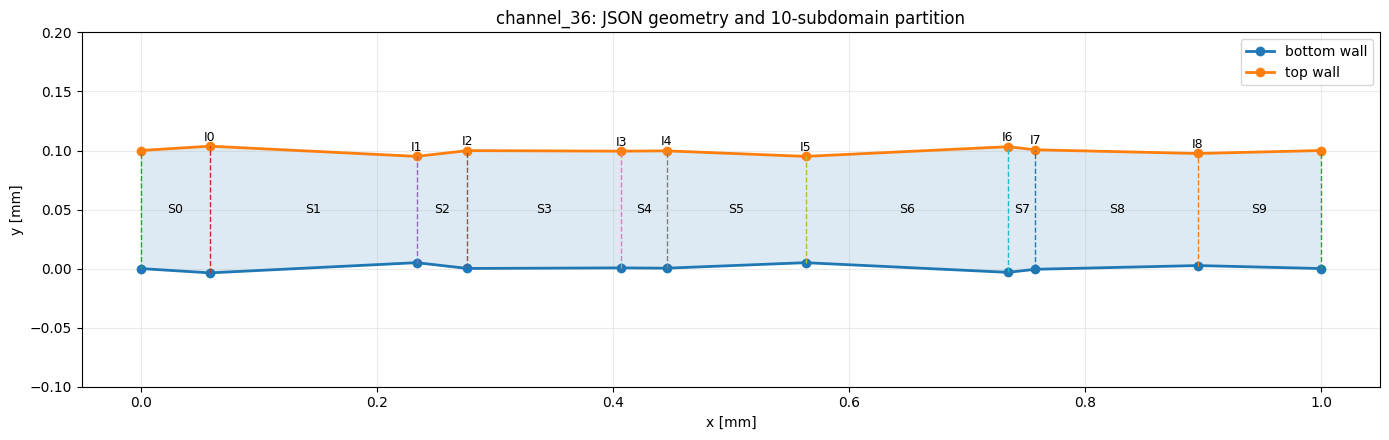


[READY] JSON geometry was parsed without using CFD truth.
[READY] 10 subdomains and 9 internal interfaces were constructed.


In [2]:
# ============================================================
# Cell 2 — Parse JSON geometry and build the 10-subdomain map
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


print("=" * 110)
print("Cell 2 — Parse channel geometry")
print("=" * 110)


# ============================================================
# 1. Read geometry arrays from the JSON loaded in Cell 1
# ============================================================

boundaries = geometry_json["boundaries"]
metadata = geometry_json["metadata"]

wall_bottom_json = boundaries["wall_bottom"]
wall_top_json = boundaries["wall_top"]

x_points_mm = np.asarray(
    metadata["x_points_mm"],
    dtype=np.float64,
)

bottom_x_mm = np.asarray(
    [point["x"] for point in wall_bottom_json],
    dtype=np.float64,
)

bottom_y_mm = np.asarray(
    [point["y"] for point in wall_bottom_json],
    dtype=np.float64,
)

top_x_mm = np.asarray(
    [point["x"] for point in wall_top_json],
    dtype=np.float64,
)

top_y_mm = np.asarray(
    [point["y"] for point in wall_top_json],
    dtype=np.float64,
)


# ============================================================
# 2. Structural validation
# ============================================================

if x_points_mm.ndim != 1:
    raise ValueError(
        "x_points_mm must be one-dimensional."
    )

if len(x_points_mm) != 11:
    raise ValueError(
        f"Expected 11 geometry control points for 10 "
        f"subdomains, but found {len(x_points_mm)}."
    )

if not np.all(
    np.diff(x_points_mm) > 0.0
):
    raise ValueError(
        "x_points_mm must be strictly increasing."
    )

if len(bottom_x_mm) != len(x_points_mm):
    raise ValueError(
        "wall_bottom point count does not match x_points_mm."
    )

if len(top_x_mm) != len(x_points_mm):
    raise ValueError(
        "wall_top point count does not match x_points_mm."
    )

if not np.allclose(
    bottom_x_mm,
    x_points_mm,
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "wall_bottom x coordinates do not match x_points_mm."
    )

if not np.allclose(
    top_x_mm,
    x_points_mm,
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "wall_top x coordinates do not match x_points_mm."
    )


# ============================================================
# 3. Interface geometry
#
# There are 11 geometric stations:
#   station 0  = global inlet
#   stations 1..9 = internal interfaces
#   station 10 = global outlet
# ============================================================

interface_height_mm = (
    top_y_mm
    - bottom_y_mm
)

interface_centerline_mm = 0.5 * (
    top_y_mm
    + bottom_y_mm
)

if np.any(
    interface_height_mm <= 0.0
):
    raise ValueError(
        "At least one interface has non-positive height."
    )


# ============================================================
# 4. Subdomain geometry
#
# Subdomain i spans:
#   x_points_mm[i] -> x_points_mm[i+1]
# ============================================================

NUM_SUBDOMAINS = len(
    x_points_mm
) - 1

NUM_INTERNAL_INTERFACES = (
    NUM_SUBDOMAINS - 1
)

subdomain_x_left_mm = (
    x_points_mm[:-1]
)

subdomain_x_right_mm = (
    x_points_mm[1:]
)

subdomain_length_mm = (
    subdomain_x_right_mm
    - subdomain_x_left_mm
)

subdomain_height_left_mm = (
    interface_height_mm[:-1]
)

subdomain_height_right_mm = (
    interface_height_mm[1:]
)

subdomain_height_mean_mm = 0.5 * (
    subdomain_height_left_mm
    + subdomain_height_right_mm
)

subdomain_centerline_left_mm = (
    interface_centerline_mm[:-1]
)

subdomain_centerline_right_mm = (
    interface_centerline_mm[1:]
)

subdomain_aspect_ratio = (
    subdomain_length_mm
    / subdomain_height_mean_mm
)

subdomain_height_slope = (
    subdomain_height_right_mm
    - subdomain_height_left_mm
) / subdomain_length_mm

subdomain_centerline_slope = (
    subdomain_centerline_right_mm
    - subdomain_centerline_left_mm
) / subdomain_length_mm


# ============================================================
# 5. Unit conversions for later physics calculations
# ============================================================

x_points_m = (
    x_points_mm
    * 1.0e-3
)

bottom_y_m = (
    bottom_y_mm
    * 1.0e-3
)

top_y_m = (
    top_y_mm
    * 1.0e-3
)

interface_height_m = (
    interface_height_mm
    * 1.0e-3
)

interface_centerline_m = (
    interface_centerline_mm
    * 1.0e-3
)

subdomain_length_m = (
    subdomain_length_mm
    * 1.0e-3
)


# ============================================================
# 6. Save the clean inference geometry object
# ============================================================

inference_geometry = {
    "case_name": CASE_NAME,

    "num_subdomains": (
        NUM_SUBDOMAINS
    ),

    "num_internal_interfaces": (
        NUM_INTERNAL_INTERFACES
    ),

    "x_points_mm": (
        x_points_mm.copy()
    ),

    "x_points_m": (
        x_points_m.copy()
    ),

    "bottom_y_mm": (
        bottom_y_mm.copy()
    ),

    "bottom_y_m": (
        bottom_y_m.copy()
    ),

    "top_y_mm": (
        top_y_mm.copy()
    ),

    "top_y_m": (
        top_y_m.copy()
    ),

    "interface_height_mm": (
        interface_height_mm.copy()
    ),

    "interface_height_m": (
        interface_height_m.copy()
    ),

    "interface_centerline_mm": (
        interface_centerline_mm.copy()
    ),

    "interface_centerline_m": (
        interface_centerline_m.copy()
    ),

    "subdomain_x_left_mm": (
        subdomain_x_left_mm.copy()
    ),

    "subdomain_x_right_mm": (
        subdomain_x_right_mm.copy()
    ),

    "subdomain_length_mm": (
        subdomain_length_mm.copy()
    ),

    "subdomain_length_m": (
        subdomain_length_m.copy()
    ),

    "subdomain_height_left_mm": (
        subdomain_height_left_mm.copy()
    ),

    "subdomain_height_right_mm": (
        subdomain_height_right_mm.copy()
    ),

    "subdomain_height_mean_mm": (
        subdomain_height_mean_mm.copy()
    ),

    "subdomain_aspect_ratio": (
        subdomain_aspect_ratio.copy()
    ),

    "subdomain_height_slope": (
        subdomain_height_slope.copy()
    ),

    "subdomain_centerline_slope": (
        subdomain_centerline_slope.copy()
    ),
}


# ============================================================
# 7. Print geometry summary
# ============================================================

print(f"Case                     : {CASE_NAME}")
print(f"Geometry stations        : {len(x_points_mm)}")
print(f"Subdomains               : {NUM_SUBDOMAINS}")
print(
    f"Internal interfaces      : "
    f"{NUM_INTERNAL_INTERFACES}"
)
print(
    f"Channel x range          : "
    f"{x_points_mm[0]:.8f} to "
    f"{x_points_mm[-1]:.8f} mm"
)
print(
    f"Interface height range   : "
    f"{interface_height_mm.min():.8f} to "
    f"{interface_height_mm.max():.8f} mm"
)
print(
    f"Centerline range         : "
    f"{interface_centerline_mm.min():.8f} to "
    f"{interface_centerline_mm.max():.8f} mm"
)

print("\nSubdomain table")

print(
    f"{'id':>3}"
    f"{'x_left [mm]':>16}"
    f"{'x_right [mm]':>16}"
    f"{'L [mm]':>14}"
    f"{'H_left [mm]':>16}"
    f"{'H_right [mm]':>17}"
    f"{'AR':>12}"
    f"{'dH/dx':>14}"
    f"{'dyc/dx':>14}"
)

print("-" * 122)

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    print(
        f"{subdomain_id:3d}"
        f"{subdomain_x_left_mm[subdomain_id]:16.8f}"
        f"{subdomain_x_right_mm[subdomain_id]:16.8f}"
        f"{subdomain_length_mm[subdomain_id]:14.8f}"
        f"{subdomain_height_left_mm[subdomain_id]:16.8f}"
        f"{subdomain_height_right_mm[subdomain_id]:17.8f}"
        f"{subdomain_aspect_ratio[subdomain_id]:12.6f}"
        f"{subdomain_height_slope[subdomain_id]:14.6f}"
        f"{subdomain_centerline_slope[subdomain_id]:14.6f}"
    )


# ============================================================
# 8. Plot channel geometry and subdomain interfaces
# ============================================================

plt.figure(
    figsize=(14, 4.5)
)

plt.plot(
    bottom_x_mm,
    bottom_y_mm,
    marker="o",
    linewidth=2.0,
    label="bottom wall",
)

plt.plot(
    top_x_mm,
    top_y_mm,
    marker="o",
    linewidth=2.0,
    label="top wall",
)

plt.fill_between(
    x_points_mm,
    bottom_y_mm,
    top_y_mm,
    alpha=0.15,
)

for station_id, x_value in enumerate(
    x_points_mm
):

    plt.plot(
        [
            x_value,
            x_value,
        ],
        [
            bottom_y_mm[station_id],
            top_y_mm[station_id],
        ],
        linestyle="--",
        linewidth=1.0,
    )

    if 0 < station_id < len(
        x_points_mm
    ) - 1:

        plt.text(
            x_value,
            top_y_mm[station_id]
            + 0.002,
            f"I{station_id - 1}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    x_mid = 0.5 * (
        subdomain_x_left_mm[subdomain_id]
        + subdomain_x_right_mm[subdomain_id]
    )

    y_mid = 0.5 * (
        subdomain_centerline_left_mm[subdomain_id]
        + subdomain_centerline_right_mm[subdomain_id]
    )

    plt.text(
        x_mid,
        y_mid,
        f"S{subdomain_id}",
        ha="center",
        va="center",
        fontsize=9,
    )

plt.xlabel("x [mm]")
plt.ylabel("y [mm]")

plt.title(
    f"{CASE_NAME}: JSON geometry and 10-subdomain partition"
)

plt.legend()
plt.grid(True, alpha=0.25)
plt.axis("equal")
plt.tight_layout()
plt.show()


print("\n" + "=" * 110)
print(
    "[READY] JSON geometry was parsed without using CFD truth."
)
print(
    "[READY] 10 subdomains and 9 internal interfaces were "
    "constructed."
)
print("=" * 110)

In [3]:
# ============================================================
# Cell 3 — Inspect H5 schema and locate channel_36 samples
#
# Purpose:
#   1. inspect the dataset structure
#   2. locate the ten channel_36 subdomains
#   3. identify inference inputs without loading CFD targets
#
# CFD target fields and true interface values are not loaded
# into the inference pipeline in this cell.
# ============================================================

from pathlib import Path

import h5py
import numpy as np


print("=" * 118)
print("Cell 3 — Inspect H5 dataset and locate channel_36")
print("=" * 118)


# ============================================================
# 1. Helper: recursively list H5 objects
# ============================================================

def describe_h5_object(
    name,
    obj,
):

    if isinstance(
        obj,
        h5py.Dataset,
    ):

        print(
            f"[DATASET] {name:<68} "
            f"shape={str(obj.shape):<24} "
            f"dtype={obj.dtype}"
        )

    elif isinstance(
        obj,
        h5py.Group,
    ):

        print(
            f"[GROUP]   {name}"
        )


# ============================================================
# 2. Inspect full H5 schema
# ============================================================

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    print("\nH5 root attributes")

    if len(
        h5_file.attrs
    ) == 0:

        print("  No root attributes found.")

    else:

        for key, value in h5_file.attrs.items():

            print(
                f"  {key}: {value}"
            )

    print("\nH5 object tree")

    h5_file.visititems(
        describe_h5_object
    )


# ============================================================
# 3. Find likely sample-level datasets
# ============================================================

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    dataset_paths = []

    def collect_dataset_paths(
        name,
        obj,
    ):

        if isinstance(
            obj,
            h5py.Dataset,
        ):

            dataset_paths.append(
                name
            )

    h5_file.visititems(
        collect_dataset_paths
    )


print("\n" + "=" * 118)
print("Candidate datasets by semantic role")
print("=" * 118)


candidate_keywords = {
    "case identifiers": [
        "case",
        "sample_id",
        "channel",
    ],

    "subdomain identifiers": [
        "subdomain",
        "domain_id",
    ],

    "branch inputs": [
        "branch",
        "condition",
        "boundary",
    ],

    "query coordinates": [
        "query",
        "coord",
        "trunk",
    ],

    "targets": [
        "target",
        "field",
        "output",
        "label",
    ],

    "metadata": [
        "metadata",
        "x_left",
        "x_right",
        "height",
        "aspect",
    ],

    "normalization": [
        "mean",
        "std",
        "normal",
        "scale",
    ],
}


for role, keywords in (
    candidate_keywords.items()
):

    matched = []

    for path in dataset_paths:

        path_lower = path.lower()

        if any(
            keyword in path_lower
            for keyword in keywords
        ):

            matched.append(
                path
            )

    print(f"\n{role}")

    if matched:

        for path in matched:

            print(
                f"  {path}"
            )

    else:

        print(
            "  No obvious candidate found."
        )


# ============================================================
# 4. Search datasets for channel_36 identifier
#
# Only small one-dimensional/string datasets are inspected.
# Large target arrays are deliberately skipped.
# ============================================================

channel_identifier_matches = []

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    for path in dataset_paths:

        dataset = h5_file[
            path
        ]

        if dataset.ndim > 2:
            continue

        if dataset.size > 100000:
            continue

        if dataset.dtype.kind not in {
            "S",
            "U",
            "O",
            "i",
            "u",
        }:
            continue

        try:

            values = dataset[
                ...
            ]

        except Exception:

            continue

        values_array = np.asarray(
            values
        )

        if values_array.dtype.kind == "S":

            decoded_values = np.vectorize(
                lambda item: item.decode(
                    "utf-8",
                    errors="replace",
                )
            )(
                values_array
            )

        elif values_array.dtype.kind in {
            "U",
            "O",
        }:

            decoded_values = values_array.astype(
                str
            )

        else:

            decoded_values = values_array

        match_indices = []

        if decoded_values.dtype.kind in {
            "U",
            "O",
        }:

            flat_values = decoded_values.reshape(
                -1
            )

            for flat_index, item in enumerate(
                flat_values
            ):

                text = str(
                    item
                )

                if (
                    CASE_NAME in text
                    or text == str(
                        CASE_ID
                    )
                ):

                    match_indices.append(
                        flat_index
                    )

        else:

            flat_values = decoded_values.reshape(
                -1
            )

            numeric_matches = np.where(
                flat_values == CASE_ID
            )[0]

            match_indices.extend(
                numeric_matches.tolist()
            )

        if match_indices:

            channel_identifier_matches.append(
                {
                    "path": path,
                    "shape": dataset.shape,
                    "dtype": str(
                        dataset.dtype
                    ),
                    "match_indices": (
                        match_indices[:30]
                    ),
                    "num_matches": len(
                        match_indices
                    ),
                }
            )


print("\n" + "=" * 118)
print(f"Datasets containing {CASE_NAME} or numeric ID {CASE_ID}")
print("=" * 118)

if not channel_identifier_matches:

    print(
        "No direct channel identifier match was found."
    )

else:

    for result in (
        channel_identifier_matches
    ):

        print(
            f"\nPath         : {result['path']}"
        )

        print(
            f"Shape        : {result['shape']}"
        )

        print(
            f"Dtype        : {result['dtype']}"
        )

        print(
            f"Matches      : {result['num_matches']}"
        )

        print(
            f"First indices: "
            f"{result['match_indices']}"
        )


# ============================================================
# 5. Inspect small metadata datasets in detail
#
# This is restricted to small arrays and does not read any
# large CFD field/target dataset.
# ============================================================

print("\n" + "=" * 118)
print("Small metadata datasets")
print("=" * 118)

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    for path in dataset_paths:

        dataset = h5_file[
            path
        ]

        path_lower = path.lower()

        looks_like_target = any(
            keyword in path_lower
            for keyword in [
                "target",
                "field",
                "label",
                "output",
            ]
        )

        if looks_like_target:
            continue

        if dataset.size > 5000:
            continue

        if dataset.ndim > 2:
            continue

        try:

            values = np.asarray(
                dataset[
                    ...
                ]
            )

        except Exception:

            continue

        print(
            f"\n{path}"
        )

        print(
            f"  shape: {values.shape}"
        )

        print(
            f"  dtype: {values.dtype}"
        )

        flat_values = values.reshape(
            -1
        )

        preview_count = min(
            12,
            flat_values.size,
        )

        preview = flat_values[
            :preview_count
        ]

        if preview.dtype.kind == "S":

            preview = [
                item.decode(
                    "utf-8",
                    errors="replace",
                )
                for item in preview
            ]

        print(
            f"  preview: {preview}"
        )


# ============================================================
# 6. Preserve schema diagnostics
# ============================================================

h5_schema_diagnostic = {
    "dataset_paths": (
        dataset_paths
    ),

    "channel_identifier_matches": (
        channel_identifier_matches
    ),

    "case_name": (
        CASE_NAME
    ),

    "case_id": (
        CASE_ID
    ),
}


print("\n" + "=" * 118)

print(
    "[READY] H5 schema inspection completed."
)

print(
    "[READY] No large CFD target array was loaded."
)

print(
    "[NEXT] Use the discovered dataset names to extract only "
    "the ten channel_36 inference samples."
)

print("=" * 118)

Cell 3 — Inspect H5 dataset and locate channel_36

H5 root attributes
  branch_channel_names: x_local
y_local
wall_mask
interface_mask
boundary_pressure
boundary_u
boundary_v
known_pressure
known_u
known_v
local_aspect_ratio
  horizontal_interface: False
  horizontal_interface_jitter: 0.0
  include_interface_endpoints: False
  n_boundary_points: 256
  n_interface_points: 256
  n_samples: 2000
  output_channel_names: pressure
u
v
  trunk_channel_names: x_local
y_local

H5 object tree
[GROUP]   metadata
[DATASET] metadata/aspect_ratio                                                shape=(2000,)                  dtype=float64
[DATASET] metadata/case_id                                                     shape=(2000,)                  dtype=object
[DATASET] metadata/local_aspect_ratio                                          shape=(2000,)                  dtype=float64
[DATASET] metadata/n_cells                                                     shape=(2000,)                  dtype=int64


In [4]:
# ============================================================
# Cell 4 — Load channel_36 inference inputs only
#
# Loaded:
#   - branch
#   - query
#   - subdomain metadata
#
# Not loaded:
#   - target
#   - CFD internal-interface truth
#   - CFD full-field truth
# ============================================================

import h5py
import numpy as np
import torch


print("=" * 122)
print("Cell 4 — Load channel_36 inference inputs")
print("=" * 122)


# ============================================================
# 1. Locate channel_36 sample indices from metadata
# ============================================================

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    case_ids_raw = np.asarray(
        h5_file["metadata/case_id"][...]
    )

    case_ids = np.asarray(
        [
            value.decode(
                "utf-8",
                errors="replace",
            )
            if isinstance(
                value,
                bytes,
            )
            else str(value)
            for value in case_ids_raw
        ]
    )

    channel_sample_indices = np.where(
        case_ids == CASE_NAME
    )[0]


if channel_sample_indices.shape[0] != NUM_SUBDOMAINS:
    raise ValueError(
        f"Expected {NUM_SUBDOMAINS} samples for {CASE_NAME}, "
        f"but found {channel_sample_indices.shape[0]}."
    )


# ============================================================
# 2. Load and sort subdomain metadata
# ============================================================

metadata_names = [
    "subdomain_id",
    "x_left_mm",
    "x_right_mm",
    "local_aspect_ratio",
    "n_cells",
    "reference_length_mm",
    "y_bottom_left_mm",
    "y_bottom_right_mm",
    "y_top_left_mm",
    "y_top_right_mm",
    "y_local_origin_mm",
    "y_local_scale_mm",
]


channel_metadata = {}

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    for name in metadata_names:

        path = f"metadata/{name}"

        if path not in h5_file:
            raise KeyError(
                f"Missing H5 metadata dataset: {path}"
            )

        channel_metadata[name] = np.asarray(
            h5_file[path][
                channel_sample_indices
            ]
        )


sort_order = np.argsort(
    channel_metadata["subdomain_id"]
)

channel_sample_indices = (
    channel_sample_indices[
        sort_order
    ]
)

for name in metadata_names:

    channel_metadata[name] = (
        channel_metadata[name][
            sort_order
        ]
    )


expected_subdomain_ids = np.arange(
    NUM_SUBDOMAINS,
    dtype=np.int64,
)

if not np.array_equal(
    channel_metadata["subdomain_id"],
    expected_subdomain_ids,
):
    raise ValueError(
        "Subdomain IDs are not exactly 0..9 after sorting."
    )


# ============================================================
# 3. Load branch and query arrays
#
# Each sample may have a different number of query points,
# so queries remain stored as a Python list.
# ============================================================

channel_branch_list = []
channel_query_list = []

with h5py.File(
    DATASET_H5_PATH,
    "r",
) as h5_file:

    for sample_index in (
        channel_sample_indices
    ):

        sample_group_path = (
            f"samples/{int(sample_index)}"
        )

        branch_path = (
            f"{sample_group_path}/branch"
        )

        query_path = (
            f"{sample_group_path}/query"
        )

        target_path = (
            f"{sample_group_path}/target"
        )

        if branch_path not in h5_file:
            raise KeyError(
                f"Missing branch dataset: {branch_path}"
            )

        if query_path not in h5_file:
            raise KeyError(
                f"Missing query dataset: {query_path}"
            )

        # Explicitly verify that target exists but do not read it.
        if target_path not in h5_file:
            raise KeyError(
                f"Missing target dataset: {target_path}"
            )

        branch_array = np.asarray(
            h5_file[branch_path][...],
            dtype=np.float32,
        )

        query_array = np.asarray(
            h5_file[query_path][...],
            dtype=np.float32,
        )

        channel_branch_list.append(
            branch_array
        )

        channel_query_list.append(
            query_array
        )


# ============================================================
# 4. Validate branch shapes
# ============================================================

branch_shapes = [
    array.shape
    for array in channel_branch_list
]

unique_branch_shapes = sorted(
    set(branch_shapes)
)

if len(unique_branch_shapes) != 1:
    raise ValueError(
        "Branch tensors do not share a common shape:\n"
        f"{unique_branch_shapes}"
    )


BRANCH_SHAPE = unique_branch_shapes[0]

if BRANCH_SHAPE != (
    1024,
    11,
):
    raise ValueError(
        f"Expected branch shape (1024, 11), "
        f"but found {BRANCH_SHAPE}."
    )


channel_branch_np = np.stack(
    channel_branch_list,
    axis=0,
)

channel_branch_cpu = torch.from_numpy(
    channel_branch_np
)

channel_branch_device = (
    channel_branch_cpu
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 5. Validate query shapes
# ============================================================

for subdomain_id, query_array in enumerate(
    channel_query_list
):

    if query_array.ndim != 2:
        raise ValueError(
            f"Subdomain {subdomain_id} query must be 2D, "
            f"found shape {query_array.shape}."
        )

    if query_array.shape[1] != 2:
        raise ValueError(
            f"Subdomain {subdomain_id} query must have "
            f"2 coordinates, found shape {query_array.shape}."
        )

    if not np.all(
        np.isfinite(
            query_array
        )
    ):
        raise ValueError(
            f"Subdomain {subdomain_id} query contains "
            f"non-finite values."
        )


# ============================================================
# 6. Verify H5 geometry against JSON geometry
# ============================================================

geometry_checks = {
    "x_left_mm": np.allclose(
        channel_metadata["x_left_mm"],
        subdomain_x_left_mm,
        rtol=0.0,
        atol=1.0e-10,
    ),

    "x_right_mm": np.allclose(
        channel_metadata["x_right_mm"],
        subdomain_x_right_mm,
        rtol=0.0,
        atol=1.0e-10,
    ),

    "bottom_left_mm": np.allclose(
        channel_metadata["y_bottom_left_mm"],
        bottom_y_mm[:-1],
        rtol=0.0,
        atol=1.0e-10,
    ),

    "bottom_right_mm": np.allclose(
        channel_metadata["y_bottom_right_mm"],
        bottom_y_mm[1:],
        rtol=0.0,
        atol=1.0e-10,
    ),

    "top_left_mm": np.allclose(
        channel_metadata["y_top_left_mm"],
        top_y_mm[:-1],
        rtol=0.0,
        atol=1.0e-10,
    ),

    "top_right_mm": np.allclose(
        channel_metadata["y_top_right_mm"],
        top_y_mm[1:],
        rtol=0.0,
        atol=1.0e-10,
    ),
}


if not all(
    geometry_checks.values()
):
    raise ValueError(
        "H5 geometry does not exactly match JSON geometry:\n"
        f"{geometry_checks}"
    )


# ============================================================
# 7. Concatenate query coordinates for later full-channel use
#
# These remain model-local query coordinates.
# ============================================================

channel_query_np = np.concatenate(
    channel_query_list,
    axis=0,
)

channel_query_batch_id_np = np.concatenate(
    [
        np.full(
            query.shape[0],
            subdomain_id,
            dtype=np.int64,
        )
        for subdomain_id, query in enumerate(
            channel_query_list
        )
    ],
    axis=0,
)

channel_query_device = torch.from_numpy(
    channel_query_np
).to(
    device=DEVICE,
    dtype=torch.float32,
)

channel_query_batch_id_device = (
    torch.from_numpy(
        channel_query_batch_id_np
    )
    .to(
        device=DEVICE,
        dtype=torch.long,
    )
)


# ============================================================
# 8. Store a clean inference-only data object
# ============================================================

channel_inference_data = {
    "case_name": CASE_NAME,

    "sample_indices": (
        channel_sample_indices.copy()
    ),

    "branch_cpu": (
        channel_branch_cpu
    ),

    "branch_device": (
        channel_branch_device
    ),

    "query_list_np": (
        channel_query_list
    ),

    "query_np": (
        channel_query_np
    ),

    "query_device": (
        channel_query_device
    ),

    "query_batch_id_np": (
        channel_query_batch_id_np
    ),

    "query_batch_id_device": (
        channel_query_batch_id_device
    ),

    "metadata": (
        channel_metadata
    ),
}


# ============================================================
# 9. Print summary
# ============================================================

print(f"Case                     : {CASE_NAME}")
print(
    f"Sample indices           : "
    f"{channel_sample_indices.tolist()}"
)
print(
    f"Branch tensor shape      : "
    f"{tuple(channel_branch_device.shape)}"
)
print(
    f"Branch device            : "
    f"{channel_branch_device.device}"
)
print(
    f"Total query points       : "
    f"{channel_query_np.shape[0]}"
)
print(
    f"Concatenated query shape : "
    f"{tuple(channel_query_device.shape)}"
)

print("\nGeometry consistency")

for check_name, passed in (
    geometry_checks.items()
):

    print(
        f"  {check_name:<20}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


print("\nPer-subdomain inference inputs")

print(
    f"{'id':>3}"
    f"{'sample':>10}"
    f"{'query points':>16}"
    f"{'branch shape':>20}"
    f"{'x left':>14}"
    f"{'x right':>14}"
    f"{'n cells':>12}"
)

print("-" * 94)

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    print(
        f"{subdomain_id:3d}"
        f"{int(channel_sample_indices[subdomain_id]):10d}"
        f"{channel_query_list[subdomain_id].shape[0]:16d}"
        f"{str(channel_branch_list[subdomain_id].shape):>20}"
        f"{channel_metadata['x_left_mm'][subdomain_id]:14.8f}"
        f"{channel_metadata['x_right_mm'][subdomain_id]:14.8f}"
        f"{int(channel_metadata['n_cells'][subdomain_id]):12d}"
    )


print("\n" + "=" * 122)

print(
    "[READY] channel_36 branch/query inputs were loaded."
)

print(
    "[READY] H5 geometry exactly matches the JSON geometry."
)

print(
    "[READY] No target dataset was read."
)

print("=" * 122)

Cell 4 — Load channel_36 inference inputs
Case                     : channel_36
Sample indices           : [360, 361, 362, 363, 364, 365, 366, 367, 368, 369]
Branch tensor shape      : (10, 1024, 11)
Branch device            : cuda:1
Total query points       : 227504
Concatenated query shape : (227504, 2)

Geometry consistency
  x_left_mm           : PASS
  x_right_mm          : PASS
  bottom_left_mm      : PASS
  bottom_right_mm     : PASS
  top_left_mm         : PASS
  top_right_mm        : PASS

Per-subdomain inference inputs
 id    sample    query points        branch shape        x left       x right     n cells
----------------------------------------------------------------------------------------------
  0       360           14143          (1024, 11)    0.00000000    0.05871061       14143
  1       361           39976          (1024, 11)    0.05871061    0.23380697       39976
  2       362            9495          (1024, 11)    0.23380697    0.27689906        9495
  3       

In [5]:
# ============================================================
# Cell 5 — Inspect the distilled 5-step checkpoint
#
# Purpose:
#   1. inspect checkpoint keys
#   2. identify model configuration
#   3. recover normalization statistics
#   4. confirm the five-step diffusion schedule
#
# No model rollout and no CFD target loading in this cell.
# ============================================================

from collections import OrderedDict

import numpy as np
import torch


print("=" * 126)
print("Cell 5 — Inspect distilled 5-step checkpoint")
print("=" * 126)


# ============================================================
# 1. Load checkpoint onto CPU first
#
# Loading on CPU avoids unnecessary GPU allocation before the
# model architecture has been identified.
# ============================================================

checkpoint = torch.load(
    DISTILLED_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)


print(
    "Checkpoint Python type :",
    type(checkpoint),
)


# ============================================================
# 2. Recursively summarize checkpoint objects
# ============================================================

def summarize_checkpoint_value(
    name,
    value,
    indent=0,
    max_depth=2,
):

    prefix = " " * indent

    if isinstance(
        value,
        torch.Tensor,
    ):

        print(
            f"{prefix}{name}: Tensor "
            f"shape={tuple(value.shape)}, "
            f"dtype={value.dtype}"
        )

    elif isinstance(
        value,
        np.ndarray,
    ):

        print(
            f"{prefix}{name}: ndarray "
            f"shape={value.shape}, "
            f"dtype={value.dtype}"
        )

    elif isinstance(
        value,
        (dict, OrderedDict),
    ):

        print(
            f"{prefix}{name}: "
            f"{type(value).__name__} "
            f"with {len(value)} keys"
        )

        if max_depth > 0:

            for child_name, child_value in value.items():

                summarize_checkpoint_value(
                    name=str(child_name),
                    value=child_value,
                    indent=indent + 4,
                    max_depth=max_depth - 1,
                )

    elif isinstance(
        value,
        (list, tuple),
    ):

        print(
            f"{prefix}{name}: "
            f"{type(value).__name__}, "
            f"length={len(value)}"
        )

        if (
            max_depth > 0
            and len(value) <= 20
        ):

            for index, child_value in enumerate(
                value
            ):

                summarize_checkpoint_value(
                    name=f"[{index}]",
                    value=child_value,
                    indent=indent + 4,
                    max_depth=max_depth - 1,
                )

    else:

        text = repr(
            value
        )

        if len(text) > 240:
            text = (
                text[:237]
                + "..."
            )

        print(
            f"{prefix}{name}: "
            f"{type(value).__name__} = {text}"
        )


print("\nCheckpoint structure")

if isinstance(
    checkpoint,
    (dict, OrderedDict),
):

    for key, value in checkpoint.items():

        summarize_checkpoint_value(
            name=str(key),
            value=value,
            indent=0,
            max_depth=2,
        )

else:

    summarize_checkpoint_value(
        name="checkpoint",
        value=checkpoint,
        indent=0,
        max_depth=2,
    )


# ============================================================
# 3. Locate candidate model state dictionaries
# ============================================================

state_dict_candidates = {}


def collect_state_dict_candidates(
    prefix,
    value,
):

    if not isinstance(
        value,
        (dict, OrderedDict),
    ):
        return

    tensor_items = {
        key: tensor
        for key, tensor in value.items()
        if isinstance(
            tensor,
            torch.Tensor,
        )
    }

    if tensor_items:

        tensor_fraction = (
            len(tensor_items)
            / max(
                len(value),
                1,
            )
        )

        if tensor_fraction >= 0.8:

            state_dict_candidates[
                prefix
            ] = value

    for key, child_value in value.items():

        if isinstance(
            child_value,
            (dict, OrderedDict),
        ):

            child_prefix = (
                f"{prefix}/{key}"
                if prefix
                else str(key)
            )

            collect_state_dict_candidates(
                child_prefix,
                child_value,
            )


collect_state_dict_candidates(
    prefix="",
    value=checkpoint,
)


print("\n" + "=" * 126)
print("Candidate model state dictionaries")
print("=" * 126)

if not state_dict_candidates:

    print(
        "No state-dictionary candidate was automatically found."
    )

else:

    for name, state_dict in (
        state_dict_candidates.items()
    ):

        parameter_count = int(
            sum(
                tensor.numel()
                for tensor in state_dict.values()
                if isinstance(
                    tensor,
                    torch.Tensor,
                )
            )
        )

        tensor_keys = [
            key
            for key, value in state_dict.items()
            if isinstance(
                value,
                torch.Tensor,
            )
        ]

        print(
            f"\nCandidate        : {name or '<root>'}"
        )

        print(
            f"Tensor entries   : {len(tensor_keys)}"
        )

        print(
            f"Parameter count  : {parameter_count:,}"
        )

        print(
            "First tensor keys:"
        )

        for key in tensor_keys[:20]:

            tensor = state_dict[
                key
            ]

            print(
                f"  {key:<72} "
                f"{tuple(tensor.shape)}"
            )


# ============================================================
# 4. Search checkpoint recursively for important metadata
# ============================================================

search_terms = {
    "timestep": [
        "timestep",
        "timesteps",
        "student_timesteps",
        "schedule",
        "time_schedule",
    ],

    "target mean": [
        "target_mean",
        "field_mean",
        "output_mean",
        "y_mean",
    ],

    "target std": [
        "target_std",
        "field_std",
        "output_std",
        "y_std",
    ],

    "branch mean": [
        "branch_mean",
        "condition_mean",
        "input_mean",
    ],

    "branch std": [
        "branch_std",
        "condition_std",
        "input_std",
    ],

    "model config": [
        "config",
        "model_config",
        "student_config",
        "architecture",
    ],
}


metadata_matches = {
    role: []
    for role in search_terms
}


def recursively_search_metadata(
    prefix,
    value,
):

    if not isinstance(
        value,
        (dict, OrderedDict),
    ):
        return

    for key, child_value in value.items():

        key_text = str(
            key
        )

        path = (
            f"{prefix}/{key_text}"
            if prefix
            else key_text
        )

        key_lower = key_text.lower()

        for role, terms in (
            search_terms.items()
        ):

            if any(
                term in key_lower
                for term in terms
            ):

                metadata_matches[
                    role
                ].append(
                    (
                        path,
                        child_value,
                    )
                )

        if isinstance(
            child_value,
            (dict, OrderedDict),
        ):

            recursively_search_metadata(
                path,
                child_value,
            )


recursively_search_metadata(
    prefix="",
    value=checkpoint,
)


print("\n" + "=" * 126)
print("Checkpoint metadata matches")
print("=" * 126)


for role, matches in (
    metadata_matches.items()
):

    print(
        f"\n{role}"
    )

    if not matches:

        print(
            "  No match found."
        )

        continue

    for path, value in matches:

        if isinstance(
            value,
            torch.Tensor,
        ):

            display_value = (
                value.detach()
                .cpu()
                .numpy()
            )

        else:

            display_value = value

        text = repr(
            display_value
        )

        if len(text) > 400:
            text = (
                text[:397]
                + "..."
            )

        print(
            f"  {path}: {text}"
        )


# ============================================================
# 5. Recover known project normalization statistics
#
# These values must later be checked against checkpoint
# metadata before use.
# ============================================================

KNOWN_TARGET_MEAN_PHYS = np.asarray(
    [
        642.7945,
        1.0002706,
        -1.324652e-05,
    ],
    dtype=np.float32,
)

KNOWN_TARGET_STD_PHYS = np.asarray(
    [
        412.8158,
        0.42717236,
        0.02204998,
    ],
    dtype=np.float32,
)

KNOWN_FIVE_STEP_TIMESTEPS = np.asarray(
    [
        999,
        749,
        500,
        250,
        0,
    ],
    dtype=np.int64,
)


# ============================================================
# 6. Check whether checkpoint contains matching values
# ============================================================

def convert_to_numpy_if_numeric(
    value,
):

    if isinstance(
        value,
        torch.Tensor,
    ):

        return (
            value.detach()
            .cpu()
            .numpy()
        )

    if isinstance(
        value,
        np.ndarray,
    ):

        return value

    if isinstance(
        value,
        (list, tuple),
    ):

        try:

            return np.asarray(
                value
            )

        except Exception:

            return None

    return None


normalization_comparisons = []


for role in [
    "target mean",
    "target std",
    "timestep",
]:

    for path, value in metadata_matches[
        role
    ]:

        array = convert_to_numpy_if_numeric(
            value
        )

        if array is None:
            continue

        array_flat = np.asarray(
            array
        ).reshape(-1)

        if role == "target mean":

            reference = (
                KNOWN_TARGET_MEAN_PHYS
            )

        elif role == "target std":

            reference = (
                KNOWN_TARGET_STD_PHYS
            )

        else:

            reference = (
                KNOWN_FIVE_STEP_TIMESTEPS
            )

        if array_flat.shape == reference.shape:

            if np.issubdtype(
                reference.dtype,
                np.integer,
            ):

                matches_reference = (
                    np.array_equal(
                        array_flat.astype(
                            reference.dtype
                        ),
                        reference,
                    )
                )

            else:

                matches_reference = (
                    np.allclose(
                        array_flat.astype(
                            np.float64
                        ),
                        reference.astype(
                            np.float64
                        ),
                        rtol=1.0e-5,
                        atol=1.0e-6,
                    )
                )

            normalization_comparisons.append(
                {
                    "role": role,
                    "path": path,
                    "value": array_flat,
                    "matches_reference": (
                        matches_reference
                    ),
                }
            )


print("\n" + "=" * 126)
print("Known project values")
print("=" * 126)

print(
    "Target mean [p,u,v] :",
    KNOWN_TARGET_MEAN_PHYS,
)

print(
    "Target std  [p,u,v] :",
    KNOWN_TARGET_STD_PHYS,
)

print(
    "Five-step timesteps :",
    KNOWN_FIVE_STEP_TIMESTEPS,
)


print("\nAutomatic checkpoint comparisons")

if not normalization_comparisons:

    print(
        "  No same-shaped checkpoint metadata was available "
        "for automatic comparison."
    )

else:

    for result in (
        normalization_comparisons
    ):

        print(
            f"  {result['role']:<14} "
            f"{result['path']:<60} "
            f"{'MATCH' if result['matches_reference'] else 'MISMATCH'}"
        )


# ============================================================
# 7. Preserve checkpoint diagnostics
# ============================================================

checkpoint_diagnostic = {
    "checkpoint": checkpoint,

    "state_dict_candidates": (
        state_dict_candidates
    ),

    "metadata_matches": (
        metadata_matches
    ),

    "normalization_comparisons": (
        normalization_comparisons
    ),

    "known_target_mean_phys": (
        KNOWN_TARGET_MEAN_PHYS.copy()
    ),

    "known_target_std_phys": (
        KNOWN_TARGET_STD_PHYS.copy()
    ),

    "known_five_step_timesteps": (
        KNOWN_FIVE_STEP_TIMESTEPS.copy()
    ),
}


print("\n" + "=" * 126)

print(
    "[READY] Distilled checkpoint structure was inspected."
)

print(
    "[READY] No model rollout was performed."
)

print(
    "[NEXT] Reconstruct the exact student architecture and "
    "load the frozen weights."
)

print("=" * 126)

Cell 5 — Inspect distilled 5-step checkpoint
Checkpoint Python type : <class 'dict'>

Checkpoint structure
stage: int = 3
epoch: int = 1
student_model_state_dict: OrderedDict with 20 keys
    branch_net.point_encoder.0.weight: Tensor shape=(128, 11), dtype=torch.float32
    branch_net.point_encoder.0.bias: Tensor shape=(128,), dtype=torch.float32
    branch_net.point_encoder.2.weight: Tensor shape=(128, 128), dtype=torch.float32
    branch_net.point_encoder.2.bias: Tensor shape=(128,), dtype=torch.float32
    branch_net.point_encoder.4.weight: Tensor shape=(128, 128), dtype=torch.float32
    branch_net.point_encoder.4.bias: Tensor shape=(128,), dtype=torch.float32
    branch_net.global_mlp.0.weight: Tensor shape=(128, 128), dtype=torch.float32
    branch_net.global_mlp.0.bias: Tensor shape=(128,), dtype=torch.float32
    branch_net.global_mlp.2.weight: Tensor shape=(128, 128), dtype=torch.float32
    branch_net.global_mlp.2.bias: Tensor shape=(128,), dtype=torch.float32
    branch_net.

In [7]:
# ============================================================
# Cell 6 — Reconstruct and load the exact frozen Stage-3 model
#
# Exact architecture source:
#   train_domain_channel_diffusion_iterative_prediction.ipynb
#
# Exact checkpoint:
#   student_distillation_stage3_epoch_001.pt
#
# This cell:
#   1. imports the original PointSetBranchNet
#   2. reconstructs PointSetDiffusionDenoiser exactly
#   3. loads Stage-3 student weights with strict=True
#   4. freezes every model parameter
#   5. restores diffusion schedule and normalization tensors
#
# No sampling is performed yet.
# ============================================================

import sys
import math
from pathlib import Path

import torch
import torch.nn as nn


print("=" * 126)
print("Cell 6 — Reconstruct exact frozen Stage-3 student")
print("=" * 126)


# ============================================================
# 1. Make the original DeepONet module importable
# ============================================================

DEEPONET_SOURCE_DIRECTORY = (
    PROJECT_ROOT
    / "DeepONet"
)

if not DEEPONET_SOURCE_DIRECTORY.exists():
    raise FileNotFoundError(
        "DeepONet source directory does not exist:\n"
        f"{DEEPONET_SOURCE_DIRECTORY}"
    )

deeponet_source_text = str(
    DEEPONET_SOURCE_DIRECTORY
)

if deeponet_source_text not in sys.path:
    sys.path.insert(
        0,
        deeponet_source_text,
    )


from fluent_deeponet import PointSetBranchNet


print(
    "PointSetBranchNet imported from:",
    PointSetBranchNet.__module__,
)


# ============================================================
# 2. Exact timestep embedding from the training notebook
# ============================================================

def sinusoidal_timestep_embedding(
    timesteps,
    dim,
):
    """
    Parameters
    ----------
    timesteps:
        Tensor with shape (N,).

    dim:
        Embedding dimension.

    Returns
    -------
    Tensor with shape (N, dim).
    """

    half = dim // 2

    freqs = torch.exp(
        -math.log(10000.0)
        * torch.arange(
            half,
            device=timesteps.device,
            dtype=torch.float32,
        )
        / max(
            half - 1,
            1,
        )
    )

    arguments = (
        timesteps.float().unsqueeze(1)
        * freqs.unsqueeze(0)
    )

    embedding = torch.cat(
        [
            torch.sin(arguments),
            torch.cos(arguments),
        ],
        dim=1,
    )

    if dim % 2 == 1:

        embedding = torch.cat(
            [
                embedding,
                torch.zeros_like(
                    embedding[:, :1]
                ),
            ],
            dim=1,
        )

    return embedding


# ============================================================
# 3. Exact MLP helper from the training notebook
# ============================================================

def make_mlp(
    input_dim,
    output_dim,
    hidden_dim=256,
    depth=4,
    activation=nn.GELU,
):

    layers = []

    current_dim = input_dim

    for _ in range(
        depth - 1
    ):

        layers.append(
            nn.Linear(
                current_dim,
                hidden_dim,
            )
        )

        layers.append(
            activation()
        )

        current_dim = hidden_dim

    layers.append(
        nn.Linear(
            current_dim,
            output_dim,
        )
    )

    return nn.Sequential(
        *layers
    )


# ============================================================
# 4. Exact point-set diffusion denoiser
# ============================================================

class PointSetDiffusionDenoiser(
    nn.Module
):
    """
    Inputs
    ------
    branch:
        (B, M, branch_input_dim)

    query:
        (N_total, query_input_dim)

    noisy_target:
        (N_total, target_dim)

    t_query:
        (N_total,)

    query_batch_id:
        (N_total,)

    branch_mask:
        (B, M), or None

    Output
    ------
    Predicted epsilon:
        (N_total, target_dim)
    """

    def __init__(
        self,
        branch_input_dim,
        query_input_dim=2,
        target_dim=3,
        latent_dim=128,
        time_dim=128,
        branch_point_hidden_dim=128,
        branch_global_hidden_dim=128,
        denoiser_hidden_dim=256,
        denoiser_depth=4,
    ):

        super().__init__()

        self.target_dim = int(
            target_dim
        )

        self.latent_dim = int(
            latent_dim
        )

        self.time_dim = int(
            time_dim
        )

        self.branch_net = PointSetBranchNet(
            branch_input_dim=branch_input_dim,
            latent_dim=latent_dim,
            output_channels=target_dim,
            point_hidden_dim=(
                branch_point_hidden_dim
            ),
            point_depth=3,
            global_hidden_dim=(
                branch_global_hidden_dim
            ),
            global_depth=3,
            aggregation="mean",
            activation="gelu",
            layer_norm=False,
        )

        denoiser_input_dim = (
            query_input_dim
            + target_dim
            + time_dim
            + target_dim * latent_dim
        )

        self.denoiser = make_mlp(
            input_dim=denoiser_input_dim,
            output_dim=target_dim,
            hidden_dim=denoiser_hidden_dim,
            depth=denoiser_depth,
            activation=nn.GELU,
        )

    def forward(
        self,
        branch,
        query,
        noisy_target,
        t_query,
        query_batch_id,
        branch_mask=None,
    ):

        # Shape:
        #   (B, target_dim, latent_dim)
        branch_coefficients = (
            self.branch_net(
                branch,
                branch_mask,
            )
        )

        # Shape:
        #   (B, target_dim * latent_dim)
        branch_embedding = (
            branch_coefficients.reshape(
                branch_coefficients.shape[0],
                -1,
            )
        )

        # Select one subdomain embedding for each query point.
        branch_embedding_query = (
            branch_embedding[
                query_batch_id
            ]
        )

        timestep_embedding = (
            sinusoidal_timestep_embedding(
                t_query,
                self.time_dim,
            )
        )

        denoiser_input = torch.cat(
            [
                query,
                noisy_target,
                timestep_embedding,
                branch_embedding_query,
            ],
            dim=1,
        )

        return self.denoiser(
            denoiser_input
        )


# ============================================================
# 5. Recover exact configuration from checkpoint
# ============================================================

model_config = dict(
    checkpoint["model_config"]
)

diffusion_config = dict(
    checkpoint["diffusion_config"]
)


required_model_config_keys = [
    "branch_input_dim",
    "query_input_dim",
    "target_dim",
    "latent_dim",
    "time_dim",
    "branch_point_hidden_dim",
    "branch_global_hidden_dim",
    "denoiser_hidden_dim",
    "denoiser_depth",
]

missing_model_config_keys = [
    key
    for key in required_model_config_keys
    if key not in model_config
]

if missing_model_config_keys:
    raise KeyError(
        "Checkpoint model_config is incomplete:\n"
        f"{missing_model_config_keys}"
    )


# ============================================================
# 6. Instantiate and load Stage-3 student
# ============================================================

stage3_student = (
    PointSetDiffusionDenoiser(
        **model_config
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


load_result = (
    stage3_student.load_state_dict(
        checkpoint[
            "student_model_state_dict"
        ],
        strict=True,
    )
)


# ============================================================
# 7. Freeze model
#
# Gradients will later propagate through the model to unknown
# interface variables, but model parameters remain frozen.
# ============================================================

stage3_student.eval()

for parameter in (
    stage3_student.parameters()
):

    parameter.requires_grad_(
        False
    )


total_parameter_count = sum(
    parameter.numel()
    for parameter in (
        stage3_student.parameters()
    )
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in (
        stage3_student.parameters()
    )
    if parameter.requires_grad
)


if total_parameter_count != 382083:
    raise RuntimeError(
        "Unexpected parameter count:\n"
        f"actual   = {total_parameter_count}\n"
        f"expected = 382083"
    )

if trainable_parameter_count != 0:
    raise RuntimeError(
        "The Stage-3 student was not fully frozen."
    )


# ============================================================
# 8. Restore target normalization
# ============================================================

target_mean_device = (
    checkpoint[
        "normalization"
    ][
        "target_mean"
    ]
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)

target_std_device = (
    checkpoint[
        "normalization"
    ][
        "target_std"
    ]
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)

local_aspect_mean = float(
    checkpoint[
        "normalization"
    ][
        "local_aspect_mean"
    ]
)

local_aspect_std = float(
    checkpoint[
        "normalization"
    ][
        "local_aspect_std"
    ]
)


# ============================================================
# 9. Restore diffusion schedule
# ============================================================

DIFFUSION_T = int(
    diffusion_config["T"]
)

BETA_START = float(
    diffusion_config["beta_start"]
)

BETA_END = float(
    diffusion_config["beta_end"]
)


betas = torch.linspace(
    BETA_START,
    BETA_END,
    DIFFUSION_T,
    device=DEVICE,
    dtype=torch.float32,
)

alphas = (
    1.0
    - betas
)

alpha_bars = torch.cumprod(
    alphas,
    dim=0,
)


student_timesteps = (
    checkpoint[
        "student_timesteps"
    ]
    .to(
        device=DEVICE,
        dtype=torch.long,
    )
)

expected_student_timesteps = (
    torch.tensor(
        [
            999,
            749,
            500,
            250,
            0,
        ],
        device=DEVICE,
        dtype=torch.long,
    )
)

if not torch.equal(
    student_timesteps,
    expected_student_timesteps,
):
    raise RuntimeError(
        "Unexpected student timestep schedule:\n"
        f"{student_timesteps.detach().cpu().tolist()}"
    )


STUDENT_TRANSITIONS = [
    (
        int(
            student_timesteps[index].item()
        ),
        int(
            student_timesteps[
                index + 1
            ].item()
        ),
    )
    for index in range(
        student_timesteps.numel() - 1
    )
]


# ============================================================
# 10. Construct the branch mask
#
# Every channel branch currently contains exactly 1024 valid
# branch points, so every mask entry is True.
# ============================================================

channel_branch_mask = torch.ones(
    (
        channel_branch_device.shape[0],
        channel_branch_device.shape[1],
    ),
    device=DEVICE,
    dtype=torch.bool,
)


# ============================================================
# 11. Structural verification only
# ============================================================

checkpoint_state_dict = (
    checkpoint[
        "student_model_state_dict"
    ]
)

loaded_state_dict = (
    stage3_student.state_dict()
)

maximum_weight_difference = 0.0

for key in checkpoint_state_dict:

    checkpoint_tensor = (
        checkpoint_state_dict[
            key
        ].to(
            device=DEVICE,
            dtype=loaded_state_dict[
                key
            ].dtype,
        )
    )

    difference = torch.max(
        torch.abs(
            loaded_state_dict[
                key
            ]
            - checkpoint_tensor
        )
    ).item()

    maximum_weight_difference = max(
        maximum_weight_difference,
        difference,
    )


if maximum_weight_difference != 0.0:
    raise RuntimeError(
        "Loaded model weights do not exactly match "
        "the checkpoint."
    )


# ============================================================
# 12. Print summary
# ============================================================

print(
    "Model class              :",
    stage3_student.__class__.__name__,
)

print(
    "Model device             :",
    next(
        stage3_student.parameters()
    ).device,
)

print(
    "Total parameters         :",
    f"{total_parameter_count:,}",
)

print(
    "Trainable parameters     :",
    trainable_parameter_count,
)

print(
    "Strict load missing keys :",
    load_result.missing_keys,
)

print(
    "Strict load extra keys   :",
    load_result.unexpected_keys,
)

print(
    "Maximum weight difference:",
    maximum_weight_difference,
)

print("\nModel configuration")

for key, value in (
    model_config.items()
):

    print(
        f"  {key:<30}: {value}"
    )

print("\nNormalization")

print(
    "  target mean [p,u,v]    :",
    target_mean_device.detach().cpu().tolist(),
)

print(
    "  target std  [p,u,v]    :",
    target_std_device.detach().cpu().tolist(),
)

print(
    "  local aspect mean      :",
    local_aspect_mean,
)

print(
    "  local aspect std       :",
    local_aspect_std,
)

print("\nDiffusion")

print(
    "  T                      :",
    DIFFUSION_T,
)

print(
    "  beta start             :",
    BETA_START,
)

print(
    "  beta end               :",
    BETA_END,
)

print(
    "  five evaluations       :",
    student_timesteps.detach().cpu().tolist(),
)

print(
    "  four DDIM transitions  :",
    STUDENT_TRANSITIONS,
)

print(
    "  final evaluation       :",
    "t=0 -> clean x0",
)

print(
    "\nBranch mask shape        :",
    tuple(
        channel_branch_mask.shape
    ),
)

print(
    "Branch mask valid count  :",
    int(
        channel_branch_mask.sum().item()
    ),
)


print("\n" + "=" * 126)

print(
    "[READY] Exact Stage-3 student architecture restored."
)

print(
    "[READY] Checkpoint weights loaded exactly."
)

print(
    "[READY] All model parameters frozen."
)

print(
    "[NEXT] Reproduce the exact branch normalization used "
    "during training."
)

print("=" * 126)

Cell 6 — Reconstruct exact frozen Stage-3 student
PointSetBranchNet imported from: fluent_deeponet
Model class              : PointSetDiffusionDenoiser
Model device             : cuda:1
Total parameters         : 382,083
Trainable parameters     : 0
Strict load missing keys : []
Strict load extra keys   : []
Maximum weight difference: 0.0

Model configuration
  branch_input_dim              : 11
  query_input_dim               : 2
  target_dim                    : 3
  latent_dim                    : 128
  time_dim                      : 128
  branch_point_hidden_dim       : 128
  branch_global_hidden_dim      : 128
  denoiser_hidden_dim           : 256
  denoiser_depth                : 4

Normalization
  target mean [p,u,v]    : [642.7944946289062, 1.0002706050872803, -1.324652384937508e-05]
  target std  [p,u,v]    : [412.8158264160156, 0.42717236280441284, 0.022049980238080025]
  local aspect mean      : 1.0
  local aspect std       : 0.7344446182250977

Diffusion
  T                

In [8]:
# ============================================================
# Cell 7 — Reproduce exact branch normalization
#
# Training preprocessing:
#
#   channels 0,1:
#       x_local, y_local unchanged
#
#   channels 2,3:
#       wall/interface masks unchanged
#
#   channels 4,5,6:
#       physical p,u,v standardized with target mean/std
#       unknown values multiplied by known flags -> 0
#
#   channels 7,8,9:
#       known flags unchanged
#
#   channel 10:
#       local aspect ratio standardized
#
# Query coordinates are already local coordinates and remain
# unchanged.
# ============================================================

import numpy as np
import torch

from deeponet_fluent_dataset import (
    normalize_cell_branch_with_y,
)


print("=" * 132)
print("Cell 7 — Exact training-time branch normalization")
print("=" * 132)


# ============================================================
# 1. Exact branch channel layout
# ============================================================

BRANCH_CHANNEL_NAMES = [
    "x_local",
    "y_local",
    "wall_mask",
    "interface_mask",
    "boundary_pressure",
    "boundary_u",
    "boundary_v",
    "known_pressure",
    "known_u",
    "known_v",
    "local_aspect_ratio",
]

OUTPUT_CHANNEL_NAMES = [
    "pressure",
    "u",
    "v",
]

VALUE_CHANNELS = [
    BRANCH_CHANNEL_NAMES.index(
        "boundary_pressure"
    ),
    BRANCH_CHANNEL_NAMES.index(
        "boundary_u"
    ),
    BRANCH_CHANNEL_NAMES.index(
        "boundary_v"
    ),
]

KNOWN_CHANNELS = [
    BRANCH_CHANNEL_NAMES.index(
        "known_pressure"
    ),
    BRANCH_CHANNEL_NAMES.index(
        "known_u"
    ),
    BRANCH_CHANNEL_NAMES.index(
        "known_v"
    ),
]

ASPECT_CHANNEL = (
    BRANCH_CHANNEL_NAMES.index(
        "local_aspect_ratio"
    )
)


# ============================================================
# 2. Minimal normalizer wrapper expected by the original
#    normalize_cell_branch_with_y function
# ============================================================

class TargetNormalizerView:

    def __init__(
        self,
        mean,
        std,
    ):

        self.mean = (
            mean.detach()
            .cpu()
            .clone()
        )

        self.std = (
            std.detach()
            .cpu()
            .clone()
        )


target_normalizer_view = (
    TargetNormalizerView(
        mean=target_mean_device,
        std=target_std_device,
    )
)


# ============================================================
# 3. Normalize all ten raw branches exactly as in training
# ============================================================

channel_branch_normalized_np = np.stack(
    [
        normalize_cell_branch_with_y(
            branch=channel_branch_np[
                subdomain_id
            ],

            branch_channel_names=(
                BRANCH_CHANNEL_NAMES
            ),

            target_y_normalizer=(
                target_normalizer_view
            ),

            local_aspect_mean=(
                local_aspect_mean
            ),

            local_aspect_std=(
                local_aspect_std
            ),

            zero_unknown_values=True,
        )

        for subdomain_id in range(
            NUM_SUBDOMAINS
        )
    ],
    axis=0,
).astype(
    np.float32,
    copy=False,
)


channel_branch_normalized_device = (
    torch.from_numpy(
        channel_branch_normalized_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 4. Structural checks
# ============================================================

if channel_branch_normalized_np.shape != (
    10,
    1024,
    11,
):
    raise ValueError(
        "Unexpected normalized branch shape:\n"
        f"{channel_branch_normalized_np.shape}"
    )

if not np.all(
    np.isfinite(
        channel_branch_normalized_np
    )
):
    raise ValueError(
        "Normalized branch contains non-finite values."
    )


# ============================================================
# 5. Confirm unchanged channels
# ============================================================

UNCHANGED_CHANNELS = [
    0,
    1,
    2,
    3,
    7,
    8,
    9,
]

unchanged_channel_errors = {}

for channel_index in (
    UNCHANGED_CHANNELS
):

    error = np.max(
        np.abs(
            channel_branch_normalized_np[
                :,
                :,
                channel_index,
            ]
            - channel_branch_np[
                :,
                :,
                channel_index,
            ]
        )
    )

    unchanged_channel_errors[
        BRANCH_CHANNEL_NAMES[
            channel_index
        ]
    ] = float(
        error
    )


# ============================================================
# 6. Confirm exact value-channel normalization
# ============================================================

target_mean_np = (
    target_mean_device
    .detach()
    .cpu()
    .numpy()
    .reshape(
        1,
        1,
        3,
    )
)

target_std_np = (
    target_std_device
    .detach()
    .cpu()
    .numpy()
    .reshape(
        1,
        1,
        3,
    )
)

raw_values = (
    channel_branch_np[
        :,
        :,
        VALUE_CHANNELS,
    ]
)

known_values = (
    channel_branch_np[
        :,
        :,
        KNOWN_CHANNELS,
    ]
)

expected_normalized_values = (
    (
        raw_values
        - target_mean_np
    )
    / target_std_np
) * known_values

actual_normalized_values = (
    channel_branch_normalized_np[
        :,
        :,
        VALUE_CHANNELS,
    ]
)

maximum_value_normalization_error = float(
    np.max(
        np.abs(
            actual_normalized_values
            - expected_normalized_values
        )
    )
)


# ============================================================
# 7. Confirm aspect-ratio normalization
# ============================================================

expected_aspect_normalized = (
    channel_branch_np[
        :,
        :,
        ASPECT_CHANNEL,
    ]
    - local_aspect_mean
) / local_aspect_std

actual_aspect_normalized = (
    channel_branch_normalized_np[
        :,
        :,
        ASPECT_CHANNEL,
    ]
)

maximum_aspect_normalization_error = float(
    np.max(
        np.abs(
            actual_aspect_normalized
            - expected_aspect_normalized
        )
    )
)


# ============================================================
# 8. Recover edge layout from branch coordinates
#
# Training branch ordering:
#   0:256     left interface
#   256:512   right interface
#   512:768   bottom wall
#   768:1024  top wall
#
# Verify rather than assume.
# ============================================================

N_EDGE_POINTS = 256

LEFT_INDEX = np.arange(
    0,
    256,
    dtype=np.int64,
)

RIGHT_INDEX = np.arange(
    256,
    512,
    dtype=np.int64,
)

BOTTOM_INDEX = np.arange(
    512,
    768,
    dtype=np.int64,
)

TOP_INDEX = np.arange(
    768,
    1024,
    dtype=np.int64,
)


def summarize_edge(
    branch,
    indices,
):

    edge = branch[
        indices
    ]

    return {
        "x_min": float(
            edge[:, 0].min()
        ),
        "x_max": float(
            edge[:, 0].max()
        ),
        "y_min": float(
            edge[:, 1].min()
        ),
        "y_max": float(
            edge[:, 1].max()
        ),
        "wall_mean": float(
            edge[:, 2].mean()
        ),
        "interface_mean": float(
            edge[:, 3].mean()
        ),
    }


edge_summary = {
    "left": summarize_edge(
        channel_branch_np[0],
        LEFT_INDEX,
    ),

    "right": summarize_edge(
        channel_branch_np[0],
        RIGHT_INDEX,
    ),

    "bottom": summarize_edge(
        channel_branch_np[0],
        BOTTOM_INDEX,
    ),

    "top": summarize_edge(
        channel_branch_np[0],
        TOP_INDEX,
    ),
}


edge_layout_valid = bool(
    np.allclose(
        channel_branch_np[
            :,
            LEFT_INDEX,
            0,
        ],
        0.0,
        atol=1.0e-7,
    )

    and np.allclose(
        channel_branch_np[
            :,
            RIGHT_INDEX,
            0,
        ],
        1.0,
        atol=1.0e-7,
    )

    and np.allclose(
        channel_branch_np[
            :,
            BOTTOM_INDEX,
            2,
        ],
        1.0,
        atol=1.0e-7,
    )

    and np.allclose(
        channel_branch_np[
            :,
            TOP_INDEX,
            2,
        ],
        1.0,
        atol=1.0e-7,
    )

    and np.allclose(
        channel_branch_np[
            :,
            LEFT_INDEX,
            3,
        ],
        1.0,
        atol=1.0e-7,
    )

    and np.allclose(
        channel_branch_np[
            :,
            RIGHT_INDEX,
            3,
        ],
        1.0,
        atol=1.0e-7,
    )
)

if not edge_layout_valid:
    raise RuntimeError(
        "Branch edge ordering does not match the expected "
        "left/right/bottom/top layout."
    )


# ============================================================
# 9. External boundary semantics after normalization
# ============================================================

inlet_known = (
    channel_branch_np[
        0,
        LEFT_INDEX,
        :,
    ][
        :,
        KNOWN_CHANNELS,
    ]
)

outlet_known = (
    channel_branch_np[
        9,
        RIGHT_INDEX,
        :,
    ][
        :,
        KNOWN_CHANNELS,
    ]
)

inlet_values_phys = (
    channel_branch_np[
        0,
        LEFT_INDEX,
        :,
    ][
        :,
        VALUE_CHANNELS,
    ]
)

outlet_values_phys = (
    channel_branch_np[
        9,
        RIGHT_INDEX,
        :,
    ][
        :,
        VALUE_CHANNELS,
    ]
)

inlet_values_norm = (
    channel_branch_normalized_np[
        0,
        LEFT_INDEX,
        :,
    ][
        :,
        VALUE_CHANNELS,
    ]
)

outlet_values_norm = (
    channel_branch_normalized_np[
        9,
        RIGHT_INDEX,
        :,
    ][
        :,
        VALUE_CHANNELS,
    ]
)


# ============================================================
# 10. Save clean base branches
#
# raw:
#   physical branch values from H5
#
# normalized:
#   exact model input representation
# ============================================================

base_branch_raw_np = (
    channel_branch_np.copy()
)

base_branch_normalized_np = (
    channel_branch_normalized_np.copy()
)

base_branch_normalized_device = (
    channel_branch_normalized_device
    .detach()
    .clone()
)


# ============================================================
# 11. Print diagnostics
# ============================================================

print("Branch channels")

for index, name in enumerate(
    BRANCH_CHANNEL_NAMES
):

    print(
        f"  {index:2d}: {name}"
    )


print("\nExact-normalization checks")

print(
    "  maximum value error   :",
    maximum_value_normalization_error,
)

print(
    "  maximum aspect error  :",
    maximum_aspect_normalization_error,
)

print("\nUnchanged-channel errors")

for name, error in (
    unchanged_channel_errors.items()
):

    print(
        f"  {name:<22}: {error:.8e}"
    )


print("\nEdge layout")

for edge_name, summary in (
    edge_summary.items()
):

    print(
        f"  {edge_name:<8} | "
        f"x=[{summary['x_min']:.6f}, "
        f"{summary['x_max']:.6f}] | "
        f"y=[{summary['y_min']:.6f}, "
        f"{summary['y_max']:.6f}] | "
        f"wall={summary['wall_mean']:.1f} | "
        f"interface={summary['interface_mean']:.1f}"
    )


print("\nGlobal inlet")

print(
    "  known fractions [p,u,v]:",
    inlet_known.mean(
        axis=0
    ).tolist(),
)

print(
    "  physical means [p,u,v] :",
    inlet_values_phys.mean(
        axis=0
    ).tolist(),
)

print(
    "  normalized means        :",
    inlet_values_norm.mean(
        axis=0
    ).tolist(),
)


print("\nGlobal outlet")

print(
    "  known fractions [p,u,v]:",
    outlet_known.mean(
        axis=0
    ).tolist(),
)

print(
    "  physical means [p,u,v] :",
    outlet_values_phys.mean(
        axis=0
    ).tolist(),
)

print(
    "  normalized means        :",
    outlet_values_norm.mean(
        axis=0
    ).tolist(),
)


print("\nQuery coordinates")

print(
    "  shape                  :",
    channel_query_np.shape,
)

print(
    "  x_local range          :",
    (
        float(
            channel_query_np[
                :,
                0,
            ].min()
        ),
        float(
            channel_query_np[
                :,
                0,
            ].max()
        ),
    ),
)

print(
    "  y_local range          :",
    (
        float(
            channel_query_np[
                :,
                1,
            ].min()
        ),
        float(
            channel_query_np[
                :,
                1,
            ].max()
        ),
    ),
)


print("\n" + "=" * 132)

print(
    "[READY] Branch normalization exactly matches training."
)

print(
    "[READY] Unknown boundary values are zero in normalized "
    "space."
)

print(
    "[READY] Query coordinates remain in their stored local "
    "coordinate system."
)

print(
    "[NEXT] Remove all CFD internal-interface values and "
    "construct a truth-free base branch."
)

print("=" * 132)

Cell 7 — Exact training-time branch normalization
Branch channels
   0: x_local
   1: y_local
   2: wall_mask
   3: interface_mask
   4: boundary_pressure
   5: boundary_u
   6: boundary_v
   7: known_pressure
   8: known_u
   9: known_v
  10: local_aspect_ratio

Exact-normalization checks
  maximum value error   : 0.0
  maximum aspect error  : 0.0

Unchanged-channel errors
  x_local               : 0.00000000e+00
  y_local               : 0.00000000e+00
  wall_mask             : 0.00000000e+00
  interface_mask        : 0.00000000e+00
  known_pressure        : 0.00000000e+00
  known_u               : 0.00000000e+00
  known_v               : 0.00000000e+00

Edge layout
  left     | x=[0.000000, 0.000000] | y=[0.003891, 0.996109] | wall=0.0 | interface=1.0
  right    | x=[1.000000, 1.000000] | y=[-0.032521, 1.032521] | wall=0.0 | interface=1.0
  bottom   | x=[0.000000, 1.000000] | y=[-0.036697, -0.000000] | wall=1.0 | interface=0.0
  top      | x=[0.000000, 1.000000] | y=[1.000000, 1.036

In [10]:
# ============================================================
# Cell 8 — Construct truth-free internal-interface branches
# FIXED: use explicit 2D index grids for (256 points, 3 fields)
# ============================================================

import numpy as np
import torch


print("=" * 132)
print("Cell 8 — Construct truth-free internal-interface branches")
print("=" * 132)


# ============================================================
# 1. Index helpers
# ============================================================

VALUE_CHANNELS_NP = np.asarray(
    VALUE_CHANNELS,
    dtype=np.int64,
)

KNOWN_CHANNELS_NP = np.asarray(
    KNOWN_CHANNELS,
    dtype=np.int64,
)

RIGHT_INDEX_NP = np.asarray(
    RIGHT_INDEX,
    dtype=np.int64,
)

LEFT_INDEX_NP = np.asarray(
    LEFT_INDEX,
    dtype=np.int64,
)


def get_numpy_block(
    array,
    subdomain_id,
    point_indices,
    channel_indices,
):
    """Return shape (n_points, n_channels)."""

    return array[
        subdomain_id
    ][
        np.ix_(
            point_indices,
            channel_indices,
        )
    ]


def set_numpy_block(
    array,
    subdomain_id,
    point_indices,
    channel_indices,
    values,
):
    """Assign a scalar or (n_points, n_channels) array."""

    array[
        subdomain_id
    ][
        np.ix_(
            point_indices,
            channel_indices,
        )
    ] = values


# GPU index tensors for the differentiable branch builder
LEFT_INDEX_DEVICE = torch.as_tensor(
    LEFT_INDEX_NP,
    device=DEVICE,
    dtype=torch.long,
)

RIGHT_INDEX_DEVICE = torch.as_tensor(
    RIGHT_INDEX_NP,
    device=DEVICE,
    dtype=torch.long,
)

VALUE_CHANNELS_DEVICE = torch.as_tensor(
    VALUE_CHANNELS_NP,
    device=DEVICE,
    dtype=torch.long,
)

KNOWN_CHANNELS_DEVICE = torch.as_tensor(
    KNOWN_CHANNELS_NP,
    device=DEVICE,
    dtype=torch.long,
)


# ============================================================
# 2. Start from exact normalized training branches
# ============================================================

truth_free_branch_np = (
    base_branch_normalized_np.copy()
)


# ============================================================
# 3. Save external boundaries and walls
# ============================================================

external_and_wall_snapshot = {
    "global_inlet": (
        truth_free_branch_np[
            0,
            LEFT_INDEX_NP,
            :,
        ].copy()
    ),

    "global_outlet": (
        truth_free_branch_np[
            9,
            RIGHT_INDEX_NP,
            :,
        ].copy()
    ),

    "bottom_walls": (
        truth_free_branch_np[
            :,
            BOTTOM_INDEX,
            :,
        ].copy()
    ),

    "top_walls": (
        truth_free_branch_np[
            :,
            TOP_INDEX,
            :,
        ].copy()
    ),
}


# ============================================================
# 4. Record removed values for leakage diagnostics only
#
# These values will never be used for initialization, loss,
# optimization, or rollout.
# ============================================================

removed_internal_interface_values = []

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    left_subdomain_id = interface_id
    right_subdomain_id = interface_id + 1

    removed_internal_interface_values.append(
        {
            "interface_id": interface_id,

            "left_copy": get_numpy_block(
                truth_free_branch_np,
                left_subdomain_id,
                RIGHT_INDEX_NP,
                VALUE_CHANNELS_NP,
            ).copy(),

            "right_copy": get_numpy_block(
                truth_free_branch_np,
                right_subdomain_id,
                LEFT_INDEX_NP,
                VALUE_CHANNELS_NP,
            ).copy(),
        }
    )


# ============================================================
# 5. Erase all CFD internal-interface p,u,v values
#
# Normalized zero is a neutral placeholder.
# ============================================================

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    left_subdomain_id = interface_id
    right_subdomain_id = interface_id + 1

    set_numpy_block(
        truth_free_branch_np,
        left_subdomain_id,
        RIGHT_INDEX_NP,
        VALUE_CHANNELS_NP,
        0.0,
    )

    set_numpy_block(
        truth_free_branch_np,
        right_subdomain_id,
        LEFT_INDEX_NP,
        VALUE_CHANNELS_NP,
        0.0,
    )


# ============================================================
# 6. Preserve internal-interface known flags as one
#
# The frozen model expects supplied interface conditions.
# Later, z supplies those conditions.
# ============================================================

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    left_subdomain_id = interface_id
    right_subdomain_id = interface_id + 1

    set_numpy_block(
        truth_free_branch_np,
        left_subdomain_id,
        RIGHT_INDEX_NP,
        KNOWN_CHANNELS_NP,
        1.0,
    )

    set_numpy_block(
        truth_free_branch_np,
        right_subdomain_id,
        LEFT_INDEX_NP,
        KNOWN_CHANNELS_NP,
        1.0,
    )


# ============================================================
# 7. Verify truth removal and paired-copy consistency
# ============================================================

maximum_remaining_internal_value = 0.0
minimum_internal_known_flag = 1.0
maximum_pair_difference = 0.0

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    left_subdomain_id = interface_id
    right_subdomain_id = interface_id + 1

    left_values = get_numpy_block(
        truth_free_branch_np,
        left_subdomain_id,
        RIGHT_INDEX_NP,
        VALUE_CHANNELS_NP,
    )

    right_values = get_numpy_block(
        truth_free_branch_np,
        right_subdomain_id,
        LEFT_INDEX_NP,
        VALUE_CHANNELS_NP,
    )

    left_known = get_numpy_block(
        truth_free_branch_np,
        left_subdomain_id,
        RIGHT_INDEX_NP,
        KNOWN_CHANNELS_NP,
    )

    right_known = get_numpy_block(
        truth_free_branch_np,
        right_subdomain_id,
        LEFT_INDEX_NP,
        KNOWN_CHANNELS_NP,
    )

    maximum_remaining_internal_value = max(
        maximum_remaining_internal_value,
        float(
            np.max(
                np.abs(left_values)
            )
        ),
        float(
            np.max(
                np.abs(right_values)
            )
        ),
    )

    minimum_internal_known_flag = min(
        minimum_internal_known_flag,
        float(left_known.min()),
        float(right_known.min()),
    )

    maximum_pair_difference = max(
        maximum_pair_difference,
        float(
            np.max(
                np.abs(
                    left_values
                    - right_values
                )
            )
        ),
    )


if maximum_remaining_internal_value != 0.0:
    raise RuntimeError(
        "Internal-interface truth was not fully removed."
    )

if minimum_internal_known_flag != 1.0:
    raise RuntimeError(
        "Internal-interface known flags are not all one."
    )

if maximum_pair_difference != 0.0:
    raise RuntimeError(
        "Paired internal-interface copies disagree."
    )


# ============================================================
# 8. Verify external boundaries and walls were unchanged
# ============================================================

invariance_errors = {
    "global_inlet": float(
        np.max(
            np.abs(
                truth_free_branch_np[
                    0,
                    LEFT_INDEX_NP,
                    :,
                ]
                - external_and_wall_snapshot[
                    "global_inlet"
                ]
            )
        )
    ),

    "global_outlet": float(
        np.max(
            np.abs(
                truth_free_branch_np[
                    9,
                    RIGHT_INDEX_NP,
                    :,
                ]
                - external_and_wall_snapshot[
                    "global_outlet"
                ]
            )
        )
    ),

    "bottom_walls": float(
        np.max(
            np.abs(
                truth_free_branch_np[
                    :,
                    BOTTOM_INDEX,
                    :,
                ]
                - external_and_wall_snapshot[
                    "bottom_walls"
                ]
            )
        )
    ),

    "top_walls": float(
        np.max(
            np.abs(
                truth_free_branch_np[
                    :,
                    TOP_INDEX,
                    :,
                ]
                - external_and_wall_snapshot[
                    "top_walls"
                ]
            )
        )
    ),
}


if any(
    error != 0.0
    for error in invariance_errors.values()
):
    raise RuntimeError(
        "External boundaries or walls were modified."
    )


# ============================================================
# 9. Move truth-free template to GPU
# ============================================================

truth_free_branch_device = (
    torch.from_numpy(
        truth_free_branch_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 10. Unknown-interface variable
# ============================================================

UNKNOWN_INTERFACE_SHAPE = (
    NUM_INTERNAL_INTERFACES,
    N_EDGE_POINTS,
    3,
)


# ============================================================
# 11. Differentiable interface-to-branch builder
#
# z shape:
#   (9 interfaces, 256 points, 3 fields)
# ============================================================

def build_branch_from_interfaces(
    interface_values_normalized,
):

    if tuple(
        interface_values_normalized.shape
    ) != UNKNOWN_INTERFACE_SHAPE:

        raise ValueError(
            "Unexpected interface tensor shape:\n"
            f"actual   = "
            f"{tuple(interface_values_normalized.shape)}\n"
            f"expected = {UNKNOWN_INTERFACE_SHAPE}"
        )

    branch = (
        truth_free_branch_device.clone()
    )

    # Explicit mesh indices give shape (256, 3).
    right_point_grid = (
        RIGHT_INDEX_DEVICE[:, None]
    )

    left_point_grid = (
        LEFT_INDEX_DEVICE[:, None]
    )

    value_channel_grid = (
        VALUE_CHANNELS_DEVICE[None, :]
    )

    for interface_id in range(
        NUM_INTERNAL_INTERFACES
    ):

        branch[
            interface_id
        ][
            right_point_grid,
            value_channel_grid,
        ] = interface_values_normalized[
            interface_id
        ]

        branch[
            interface_id + 1
        ][
            left_point_grid,
            value_channel_grid,
        ] = interface_values_normalized[
            interface_id
        ]

    return branch


# ============================================================
# 12. Differentiability smoke test
#
# Use a nonzero test tensor so the gradient should also be
# nonzero.
# ============================================================

z_test = torch.full(
    UNKNOWN_INTERFACE_SHAPE,
    fill_value=0.1,
    device=DEVICE,
    dtype=torch.float32,
    requires_grad=True,
)

branch_test = (
    build_branch_from_interfaces(
        z_test
    )
)

test_loss = (
    branch_test[
        :,
        :,
        VALUE_CHANNELS,
    ]
    .square()
    .mean()
)

test_loss.backward()


if z_test.grad is None:
    raise RuntimeError(
        "No gradient reached z."
    )

if not torch.all(
    torch.isfinite(
        z_test.grad
    )
):
    raise RuntimeError(
        "z gradient contains non-finite values."
    )

if float(
    z_test.grad.abs().max().item()
) == 0.0:
    raise RuntimeError(
        "z gradient is unexpectedly zero."
    )


# ============================================================
# 13. Preserve inference state
# ============================================================

truth_free_inference_state = {
    "branch_template_np": (
        truth_free_branch_np
    ),

    "branch_template_device": (
        truth_free_branch_device
    ),

    "interface_shape": (
        UNKNOWN_INTERFACE_SHAPE
    ),

    "value_channels": (
        VALUE_CHANNELS
    ),

    "known_channels": (
        KNOWN_CHANNELS
    ),
}


# ============================================================
# 14. Print diagnostics
# ============================================================

print(
    "Truth-free branch shape        :",
    truth_free_branch_np.shape,
)

print(
    "Unknown-interface tensor shape :",
    UNKNOWN_INTERFACE_SHAPE,
)

print(
    "Maximum remaining internal p/u/v:",
    maximum_remaining_internal_value,
)

print(
    "Minimum internal known flag    :",
    minimum_internal_known_flag,
)

print(
    "Maximum paired-copy difference :",
    maximum_pair_difference,
)

print("\nExternal/wall invariance")

for name, error in invariance_errors.items():

    print(
        f"  {name:<18}: {error:.8e}"
    )

print("\nDifferentiability")

print(
    "  test loss               :",
    float(
        test_loss.detach().cpu()
    ),
)

print(
    "  gradient shape          :",
    tuple(
        z_test.grad.shape
    ),
)

print(
    "  maximum gradient        :",
    float(
        z_test.grad.abs().max().item()
    ),
)

print(
    "  gradient finite         :",
    bool(
        torch.all(
            torch.isfinite(
                z_test.grad
            )
        )
    ),
)


print("\n" + "=" * 132)

print(
    "[READY] All CFD internal-interface values were removed."
)

print(
    "[READY] Global inlet, outlet, and walls were preserved."
)

print(
    "[READY] Differentiable interface-to-branch builder works."
)

print("=" * 132)

Cell 8 — Construct truth-free internal-interface branches
Truth-free branch shape        : (10, 1024, 11)
Unknown-interface tensor shape : (9, 256, 3)
Maximum remaining internal p/u/v: 0.0
Minimum internal known flag    : 1.0
Maximum paired-copy difference : 0.0

External/wall invariance
  global_inlet      : 0.00000000e+00
  global_outlet     : 0.00000000e+00
  bottom_walls      : 0.00000000e+00
  top_walls         : 0.00000000e+00

Differentiability
  test loss               : 0.9385603070259094
  gradient shape          : (9, 256, 3)
  maximum gradient        : 1.3020834558119532e-05
  gradient finite         : True

[READY] All CFD internal-interface values were removed.
[READY] Global inlet, outlet, and walls were preserved.
[READY] Differentiable interface-to-branch builder works.


In [11]:
# ============================================================
# Cell 9 — Exact differentiable five-evaluation student sampler
#
# Five denoiser evaluations:
#
#   evaluation 1: t=999, DDIM jump 999 -> 749
#   evaluation 2: t=749, DDIM jump 749 -> 500
#   evaluation 3: t=500, DDIM jump 500 -> 250
#   evaluation 4: t=250, DDIM jump 250 -> 0
#   evaluation 5: t=0,   clean-field projection
#
# The sampler remains differentiable with respect to:
#   - internal-interface variable z
#   - initial noise, if required
#
# Model parameters remain frozen.
# ============================================================

import torch


print("=" * 132)
print("Cell 9 — Exact five-evaluation student sampler")
print("=" * 132)


# ============================================================
# 1. Deterministic DDIM transition
# ============================================================

def deterministic_ddim_transition(
    x_t,
    epsilon_pred,
    t_current,
    t_next,
):
    """
    Deterministic DDIM transition with eta=0.

    Parameters
    ----------
    x_t:
        Noisy normalized field at t_current,
        shape (N_query, 3).

    epsilon_pred:
        Student-predicted noise,
        shape (N_query, 3).

    t_current:
        Current diffusion timestep.

    t_next:
        Next lower diffusion timestep.

    Returns
    -------
    x_next:
        Deterministic state at t_next.

    x0_pred:
        Clean-field estimate made at t_current.
    """

    t_current = int(
        t_current
    )

    t_next = int(
        t_next
    )

    if not (
        0 <= t_next < t_current < DIFFUSION_T
    ):
        raise ValueError(
            "Expected 0 <= t_next < t_current < T, but got "
            f"t_current={t_current}, t_next={t_next}."
        )

    alpha_bar_current = (
        alpha_bars[
            t_current
        ].to(
            device=x_t.device,
            dtype=x_t.dtype,
        )
    )

    alpha_bar_next = (
        alpha_bars[
            t_next
        ].to(
            device=x_t.device,
            dtype=x_t.dtype,
        )
    )

    x0_pred = (
        x_t
        - torch.sqrt(
            1.0
            - alpha_bar_current
        )
        * epsilon_pred
    ) / torch.sqrt(
        alpha_bar_current
    )

    x_next = (
        torch.sqrt(
            alpha_bar_next
        )
        * x0_pred
        + torch.sqrt(
            1.0
            - alpha_bar_next
        )
        * epsilon_pred
    )

    return (
        x_next,
        x0_pred,
    )


# ============================================================
# 2. Final t=0 clean-field projection
# ============================================================

def final_clean_projection(
    x_t0,
    epsilon_pred_t0,
):
    """
    Apply the fifth denoiser evaluation at t=0 and return the
    final normalized clean-field prediction.
    """

    alpha_bar_0 = (
        alpha_bars[
            0
        ].to(
            device=x_t0.device,
            dtype=x_t0.dtype,
        )
    )

    clean_x0 = (
        x_t0
        - torch.sqrt(
            1.0
            - alpha_bar_0
        )
        * epsilon_pred_t0
    ) / torch.sqrt(
        alpha_bar_0
    )

    return clean_x0


# ============================================================
# 3. Exact five-evaluation rollout
#
# Do not decorate with torch.no_grad() because future physics
# optimization requires gradients from the output back to z.
# ============================================================

def rollout_five_evaluation_student(
    model,
    branch,
    query,
    query_batch_id,
    branch_mask,
    initial_noise,
    return_trajectory=False,
):
    """
    Run the exact distilled Stage-3 student sampler.

    Parameters
    ----------
    model:
        Frozen PointSetDiffusionDenoiser.

    branch:
        Normalized branch tensor, shape (10, 1024, 11).

    query:
        Concatenated local query coordinates,
        shape (N_total, 2).

    query_batch_id:
        Query-to-subdomain map, shape (N_total,).

    branch_mask:
        Shape (10, 1024).

    initial_noise:
        Fixed normalized Gaussian noise,
        shape (N_total, 3).

    return_trajectory:
        Store intermediate states and epsilon predictions.

    Returns
    -------
    clean_x0:
        Final normalized field, shape (N_total, 3).

    trajectory:
        Optional list containing all five evaluations.
    """

    expected_noise_shape = (
        query.shape[0],
        model.target_dim,
    )

    if tuple(
        initial_noise.shape
    ) != expected_noise_shape:

        raise ValueError(
            "Initial-noise shape mismatch:\n"
            f"actual   = {tuple(initial_noise.shape)}\n"
            f"expected = {expected_noise_shape}"
        )

    if branch.shape[0] != (
        channel_branch_mask.shape[0]
    ):
        raise ValueError(
            "Branch batch size does not match branch mask."
        )

    x_state = initial_noise

    trajectory = []

    # --------------------------------------------------------
    # Evaluations 1–4:
    # deterministic large DDIM jumps
    # --------------------------------------------------------

    for evaluation_id, (
        t_current,
        t_next,
    ) in enumerate(
        STUDENT_TRANSITIONS,
        start=1,
    ):

        t_query = torch.full(
            (
                query.shape[0],
            ),
            fill_value=t_current,
            device=query.device,
            dtype=torch.long,
        )

        epsilon_pred = model(
            branch=branch,
            query=query,
            noisy_target=x_state,
            t_query=t_query,
            query_batch_id=query_batch_id,
            branch_mask=branch_mask,
        )

        x_next, x0_estimate = (
            deterministic_ddim_transition(
                x_t=x_state,
                epsilon_pred=epsilon_pred,
                t_current=t_current,
                t_next=t_next,
            )
        )

        if return_trajectory:

            trajectory.append(
                {
                    "evaluation_id": (
                        evaluation_id
                    ),

                    "type": (
                        "ddim_jump"
                    ),

                    "t_start": (
                        t_current
                    ),

                    "t_end": (
                        t_next
                    ),

                    "x_start": (
                        x_state
                    ),

                    "epsilon_pred": (
                        epsilon_pred
                    ),

                    "x0_estimate": (
                        x0_estimate
                    ),

                    "x_end": (
                        x_next
                    ),
                }
            )

        x_state = x_next

    # --------------------------------------------------------
    # Evaluation 5:
    # t=0 -> clean x0
    # --------------------------------------------------------

    t_query_final = torch.zeros(
        (
            query.shape[0],
        ),
        device=query.device,
        dtype=torch.long,
    )

    epsilon_pred_final = model(
        branch=branch,
        query=query,
        noisy_target=x_state,
        t_query=t_query_final,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

    clean_x0 = final_clean_projection(
        x_t0=x_state,
        epsilon_pred_t0=(
            epsilon_pred_final
        ),
    )

    if return_trajectory:

        trajectory.append(
            {
                "evaluation_id": 5,

                "type": (
                    "final_clean"
                ),

                "t_start": 0,

                "t_end": (
                    "clean"
                ),

                "x_start": (
                    x_state
                ),

                "epsilon_pred": (
                    epsilon_pred_final
                ),

                "x0_estimate": (
                    clean_x0
                ),

                "x_end": (
                    clean_x0
                ),
            }
        )

    if return_trajectory:

        return (
            clean_x0,
            trajectory,
        )

    return clean_x0


# ============================================================
# 4. Fixed initial noise
#
# The same fixed noise must be reused throughout interface
# optimization. Otherwise the objective changes randomly at
# every optimization iteration.
# ============================================================

INFERENCE_NOISE_SEED = 8100

noise_generator = torch.Generator(
    device=DEVICE
)

noise_generator.manual_seed(
    INFERENCE_NOISE_SEED
)

fixed_initial_noise = torch.randn(
    (
        channel_query_device.shape[0],
        3,
    ),
    generator=noise_generator,
    device=DEVICE,
    dtype=torch.float32,
)


# ============================================================
# 5. Truth-free zero-interface baseline
#
# z=0 is normalized zero:
#   p = training pressure mean
#   u = training velocity mean
#   v = training v mean
#
# It is only a neutral initial baseline, not the final inferred
# interface solution.
# ============================================================

zero_interface_normalized = torch.zeros(
    UNKNOWN_INTERFACE_SHAPE,
    device=DEVICE,
    dtype=torch.float32,
)

zero_interface_branch = (
    build_branch_from_interfaces(
        zero_interface_normalized
    )
)


# ============================================================
# 6. Run one baseline rollout without building a gradient graph
# ============================================================

with torch.no_grad():

    baseline_prediction_normalized, (
        baseline_trajectory
    ) = rollout_five_evaluation_student(
        model=stage3_student,
        branch=zero_interface_branch,
        query=channel_query_device,
        query_batch_id=(
            channel_query_batch_id_device
        ),
        branch_mask=(
            channel_branch_mask
        ),
        initial_noise=(
            fixed_initial_noise
        ),
        return_trajectory=True,
    )


# ============================================================
# 7. Convert prediction into physical units
# ============================================================

baseline_prediction_physical = (
    baseline_prediction_normalized
    * target_std_device[
        None,
        :
    ]
    + target_mean_device[
        None,
        :
    ]
)


# ============================================================
# 8. Structural validation
# ============================================================

if tuple(
    baseline_prediction_normalized.shape
) != (
    channel_query_device.shape[0],
    3,
):
    raise RuntimeError(
        "Unexpected prediction shape."
    )

if len(
    baseline_trajectory
) != 5:
    raise RuntimeError(
        "Sampler did not perform exactly five evaluations."
    )

if not torch.isfinite(
    baseline_prediction_normalized
).all():
    raise RuntimeError(
        "Normalized prediction contains NaN or Inf."
    )

if not torch.isfinite(
    baseline_prediction_physical
).all():
    raise RuntimeError(
        "Physical prediction contains NaN or Inf."
    )


# ============================================================
# 9. Split full output back into ten variable-sized subdomains
# ============================================================

query_counts = [
    query.shape[0]
    for query in channel_query_list
]

query_offsets = np.concatenate(
    [
        np.asarray(
            [0],
            dtype=np.int64,
        ),
        np.cumsum(
            query_counts,
            dtype=np.int64,
        ),
    ]
)


baseline_prediction_normalized_list = []

baseline_prediction_physical_list = []

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    start = int(
        query_offsets[
            subdomain_id
        ]
    )

    end = int(
        query_offsets[
            subdomain_id + 1
        ]
    )

    baseline_prediction_normalized_list.append(
        baseline_prediction_normalized[
            start:end
        ]
    )

    baseline_prediction_physical_list.append(
        baseline_prediction_physical[
            start:end
        ]
    )


# ============================================================
# 10. Save reusable sampler state
# ============================================================

five_step_sampler_state = {
    "noise_seed": (
        INFERENCE_NOISE_SEED
    ),

    "initial_noise": (
        fixed_initial_noise
    ),

    "timesteps": (
        student_timesteps
    ),

    "transitions": (
        STUDENT_TRANSITIONS
    ),

    "baseline_normalized": (
        baseline_prediction_normalized
    ),

    "baseline_physical": (
        baseline_prediction_physical
    ),

    "baseline_normalized_list": (
        baseline_prediction_normalized_list
    ),

    "baseline_physical_list": (
        baseline_prediction_physical_list
    ),

    "trajectory": (
        baseline_trajectory
    ),
}


# ============================================================
# 11. Print rollout diagnostics
# ============================================================

print(
    "Initial-noise seed       :",
    INFERENCE_NOISE_SEED,
)

print(
    "Initial-noise shape      :",
    tuple(
        fixed_initial_noise.shape
    ),
)

print(
    "Initial-noise mean/std   :",
    (
        float(
            fixed_initial_noise.mean().cpu()
        ),
        float(
            fixed_initial_noise.std().cpu()
        ),
    ),
)

print("\nFive model evaluations")

for item in baseline_trajectory:

    x_end = item[
        "x_end"
    ]

    print(
        f"  evaluation "
        f"{item['evaluation_id']} | "
        f"{item['type']:<11} | "
        f"{item['t_start']} -> "
        f"{item['t_end']} | "
        f"shape={tuple(x_end.shape)} | "
        f"mean={float(x_end.mean().cpu()):+.6f} | "
        f"std={float(x_end.std().cpu()):.6f} | "
        f"max_abs={float(x_end.abs().max().cpu()):.6f}"
    )


print("\nFinal normalized prediction")

for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    field = (
        baseline_prediction_normalized[
            :,
            field_index,
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"min={float(field.min().cpu()):+.6f} | "
        f"max={float(field.max().cpu()):+.6f} | "
        f"mean={float(field.mean().cpu()):+.6f} | "
        f"std={float(field.std().cpu()):.6f}"
    )


print("\nFinal physical prediction")

physical_units = [
    "Pa",
    "m/s",
    "m/s",
]

for field_index, (
    field_name,
    unit,
) in enumerate(
    zip(
        OUTPUT_CHANNEL_NAMES,
        physical_units,
    )
):

    field = (
        baseline_prediction_physical[
            :,
            field_index,
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"min={float(field.min().cpu()):+.6f} {unit} | "
        f"max={float(field.max().cpu()):+.6f} {unit} | "
        f"mean={float(field.mean().cpu()):+.6f} {unit} | "
        f"std={float(field.std().cpu()):.6f} {unit}"
    )


print("\nPer-subdomain output shapes")

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    print(
        f"  S{subdomain_id}: "
        f"{tuple(baseline_prediction_physical_list[subdomain_id].shape)}"
    )


print("\n" + "=" * 132)

print(
    "[READY] Exact five-evaluation sampler executed."
)

print(
    "[READY] Prediction used geometry, external BCs, fixed "
    "noise, and zero interface initialization only."
)

print(
    "[READY] No CFD target or true internal interface was used."
)

print(
    "[NEXT] Build differentiable predicted interface traces "
    "from the generated subdomain fields."
)

print("=" * 132)

Cell 9 — Exact five-evaluation student sampler
Initial-noise seed       : 8100
Initial-noise shape      : (227504, 3)
Initial-noise mean/std   : (-0.0014598923735320568, 1.0004377365112305)

Five model evaluations
  evaluation 1 | ddim_jump   | 999 -> 749 | shape=(227504, 3) | mean=+0.000165 | std=1.225700 | max_abs=10.581646
  evaluation 2 | ddim_jump   | 749 -> 500 | shape=(227504, 3) | mean=-0.074342 | std=1.638238 | max_abs=30.924150
  evaluation 3 | ddim_jump   | 500 -> 250 | shape=(227504, 3) | mean=-0.140875 | std=2.369110 | max_abs=73.211121
  evaluation 4 | ddim_jump   | 250 -> 0 | shape=(227504, 3) | mean=-0.113010 | std=2.554512 | max_abs=78.572960
  evaluation 5 | final_clean | 0 -> clean | shape=(227504, 3) | mean=-0.107799 | std=2.551604 | max_abs=78.260117

Final normalized prediction
  pressure   | min=-1.367870 | max=+78.260117 | mean=-0.158111 | std=0.801818
  u          | min=-3.057012 | max=+3.642359 | mean=+0.002578 | std=0.457383
  v          | min=-62.174191 | ma

In [12]:
# ============================================================
# Cell 10 — Build differentiable model-predicted interface traces
#
# For each of the 10 subdomains, directly query:
#   - 256 points on its left boundary
#   - 256 points on its right boundary
#
# Total boundary queries:
#   10 × 2 × 256 = 5120
#
# This avoids approximating interface values from nearby CFD
# cell-center query points.
# ============================================================

import torch
import numpy as np


print("=" * 136)
print("Cell 10 — Direct differentiable interface-trace rollout")
print("=" * 136)


# ============================================================
# 1. Extract exact local interface coordinates from branch
#
# These coordinates are geometry-only information:
#   channels 0,1 = x_local,y_local
# ============================================================

left_interface_query_np = (
    base_branch_normalized_np[
        :,
        LEFT_INDEX_NP,
        0:2,
    ]
    .copy()
)

right_interface_query_np = (
    base_branch_normalized_np[
        :,
        RIGHT_INDEX_NP,
        0:2,
    ]
    .copy()
)


if left_interface_query_np.shape != (
    NUM_SUBDOMAINS,
    N_EDGE_POINTS,
    2,
):
    raise RuntimeError(
        "Unexpected left-interface query shape."
    )

if right_interface_query_np.shape != (
    NUM_SUBDOMAINS,
    N_EDGE_POINTS,
    2,
):
    raise RuntimeError(
        "Unexpected right-interface query shape."
    )


# ============================================================
# 2. Combine left and right queries for all subdomains
#
# Ordering:
#   first 256  = left edge
#   next 256   = right edge
# ============================================================

boundary_query_by_subdomain_np = np.concatenate(
    [
        left_interface_query_np,
        right_interface_query_np,
    ],
    axis=1,
).astype(
    np.float32,
    copy=False,
)


BOUNDARY_QUERIES_PER_SUBDOMAIN = (
    2 * N_EDGE_POINTS
)

TOTAL_BOUNDARY_QUERIES = (
    NUM_SUBDOMAINS
    * BOUNDARY_QUERIES_PER_SUBDOMAIN
)


boundary_query_np = (
    boundary_query_by_subdomain_np.reshape(
        TOTAL_BOUNDARY_QUERIES,
        2,
    )
)


boundary_query_batch_id_np = np.repeat(
    np.arange(
        NUM_SUBDOMAINS,
        dtype=np.int64,
    ),
    BOUNDARY_QUERIES_PER_SUBDOMAIN,
)


boundary_query_device = (
    torch.from_numpy(
        boundary_query_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)

boundary_query_batch_id_device = (
    torch.from_numpy(
        boundary_query_batch_id_np
    )
    .to(
        device=DEVICE,
        dtype=torch.long,
    )
)


# ============================================================
# 3. Fixed boundary-query diffusion noise
#
# Keep this noise fixed during interface optimization.
# ============================================================

BOUNDARY_NOISE_SEED = 8200

boundary_noise_generator = torch.Generator(
    device=DEVICE
)

boundary_noise_generator.manual_seed(
    BOUNDARY_NOISE_SEED
)

fixed_boundary_initial_noise = torch.randn(
    (
        TOTAL_BOUNDARY_QUERIES,
        3,
    ),
    generator=boundary_noise_generator,
    device=DEVICE,
    dtype=torch.float32,
)


# ============================================================
# 4. Direct boundary-trace rollout
# ============================================================

def rollout_boundary_traces(
    interface_values_normalized,
    return_full_boundary=False,
):
    """
    Parameters
    ----------
    interface_values_normalized:
        z with shape (9,256,3), normalized p,u,v.

    return_full_boundary:
        Also return all 10 left and 10 right traces.

    Returns
    -------
    internal_left_prediction:
        Prediction from the right edge of subdomains 0..8.
        Shape (9,256,3).

    internal_right_prediction:
        Prediction from the left edge of subdomains 1..9.
        Shape (9,256,3).

    optional:
        all_left_prediction, all_right_prediction
        each shape (10,256,3).
    """

    branch = build_branch_from_interfaces(
        interface_values_normalized
    )

    boundary_prediction_flat = (
        rollout_five_evaluation_student(
            model=stage3_student,
            branch=branch,
            query=boundary_query_device,
            query_batch_id=(
                boundary_query_batch_id_device
            ),
            branch_mask=channel_branch_mask,
            initial_noise=(
                fixed_boundary_initial_noise
            ),
            return_trajectory=False,
        )
    )

    boundary_prediction = (
        boundary_prediction_flat.reshape(
            NUM_SUBDOMAINS,
            BOUNDARY_QUERIES_PER_SUBDOMAIN,
            3,
        )
    )

    all_left_prediction = (
        boundary_prediction[
            :,
            :N_EDGE_POINTS,
            :,
        ]
    )

    all_right_prediction = (
        boundary_prediction[
            :,
            N_EDGE_POINTS:,
            :,
        ]
    )

    # For internal interface i:
    #
    #   prediction from upstream/left subdomain:
    #       right edge of subdomain i
    #
    #   prediction from downstream/right subdomain:
    #       left edge of subdomain i+1
    internal_left_prediction = (
        all_right_prediction[:-1]
    )

    internal_right_prediction = (
        all_left_prediction[1:]
    )

    if return_full_boundary:

        return (
            internal_left_prediction,
            internal_right_prediction,
            all_left_prediction,
            all_right_prediction,
        )

    return (
        internal_left_prediction,
        internal_right_prediction,
    )


# ============================================================
# 5. Interface fixed-point loss
#
# The supplied interface z should agree with the field that
# each neighboring subdomain generates on that interface.
# ============================================================

def compute_interface_fixed_point_losses(
    interface_values_normalized,
):
    """
    Returns normalized-space losses and predicted traces.
    """

    (
        prediction_from_left,
        prediction_from_right,
    ) = rollout_boundary_traces(
        interface_values_normalized
    )

    residual_left = (
        prediction_from_left
        - interface_values_normalized
    )

    residual_right = (
        prediction_from_right
        - interface_values_normalized
    )

    residual_neighbor = (
        prediction_from_left
        - prediction_from_right
    )

    per_field_left_mse = (
        residual_left
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    per_field_right_mse = (
        residual_right
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    per_field_neighbor_mse = (
        residual_neighbor
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    fixed_point_loss = 0.5 * (
        per_field_left_mse.mean()
        + per_field_right_mse.mean()
    )

    neighbor_continuity_loss = (
        per_field_neighbor_mse.mean()
    )

    return {
        "fixed_point_loss": (
            fixed_point_loss
        ),

        "neighbor_continuity_loss": (
            neighbor_continuity_loss
        ),

        "per_field_left_mse": (
            per_field_left_mse
        ),

        "per_field_right_mse": (
            per_field_right_mse
        ),

        "per_field_neighbor_mse": (
            per_field_neighbor_mse
        ),

        "prediction_from_left": (
            prediction_from_left
        ),

        "prediction_from_right": (
            prediction_from_right
        ),

        "residual_left": (
            residual_left
        ),

        "residual_right": (
            residual_right
        ),
    }


# ============================================================
# 6. Evaluate the z=0 baseline
# ============================================================

with torch.no_grad():

    zero_interface_trace_result = (
        compute_interface_fixed_point_losses(
            zero_interface_normalized
        )
    )


zero_prediction_from_left = (
    zero_interface_trace_result[
        "prediction_from_left"
    ]
)

zero_prediction_from_right = (
    zero_interface_trace_result[
        "prediction_from_right"
    ]
)


# ============================================================
# 7. Convert baseline predicted traces to physical units
# ============================================================

zero_prediction_from_left_phys = (
    zero_prediction_from_left
    * target_std_device[
        None,
        None,
        :,
    ]
    + target_mean_device[
        None,
        None,
        :,
    ]
)

zero_prediction_from_right_phys = (
    zero_prediction_from_right
    * target_std_device[
        None,
        None,
        :,
    ]
    + target_mean_device[
        None,
        None,
        :,
    ]
)


# ============================================================
# 8. Differentiability test through the full five-step sampler
# ============================================================

z_gradient_test = torch.zeros(
    UNKNOWN_INTERFACE_SHAPE,
    device=DEVICE,
    dtype=torch.float32,
    requires_grad=True,
)

gradient_test_result = (
    compute_interface_fixed_point_losses(
        z_gradient_test
    )
)

gradient_test_loss = (
    gradient_test_result[
        "fixed_point_loss"
    ]
)

gradient_test_loss.backward()


if z_gradient_test.grad is None:
    raise RuntimeError(
        "No gradient propagated through the five-step sampler "
        "to the interface variable."
    )

if not torch.isfinite(
    z_gradient_test.grad
).all():
    raise RuntimeError(
        "Interface gradient contains NaN or Inf."
    )


# ============================================================
# 9. Structural checks
# ============================================================

expected_internal_trace_shape = (
    NUM_INTERNAL_INTERFACES,
    N_EDGE_POINTS,
    3,
)

if tuple(
    zero_prediction_from_left.shape
) != expected_internal_trace_shape:
    raise RuntimeError(
        "Unexpected upstream trace shape."
    )

if tuple(
    zero_prediction_from_right.shape
) != expected_internal_trace_shape:
    raise RuntimeError(
        "Unexpected downstream trace shape."
    )


# ============================================================
# 10. Store reusable interface-trace state
# ============================================================

interface_trace_state = {
    "boundary_query_np": (
        boundary_query_np
    ),

    "boundary_query_device": (
        boundary_query_device
    ),

    "boundary_query_batch_id_device": (
        boundary_query_batch_id_device
    ),

    "fixed_boundary_noise": (
        fixed_boundary_initial_noise
    ),

    "boundary_noise_seed": (
        BOUNDARY_NOISE_SEED
    ),

    "zero_interface_result": (
        zero_interface_trace_result
    ),
}


# ============================================================
# 11. Print diagnostics
# ============================================================

print(
    "Boundary query shape         :",
    tuple(
        boundary_query_device.shape
    ),
)

print(
    "Boundary query count         :",
    TOTAL_BOUNDARY_QUERIES,
)

print(
    "Queries per subdomain        :",
    BOUNDARY_QUERIES_PER_SUBDOMAIN,
)

print(
    "Boundary noise seed          :",
    BOUNDARY_NOISE_SEED,
)

print(
    "Predicted internal shape     :",
    tuple(
        zero_prediction_from_left.shape
    ),
)


print("\nZero-interface fixed-point losses")

print(
    "  fixed-point loss           :",
    float(
        zero_interface_trace_result[
            "fixed_point_loss"
        ].cpu()
    ),
)

print(
    "  neighbor continuity loss   :",
    float(
        zero_interface_trace_result[
            "neighbor_continuity_loss"
        ].cpu()
    ),
)


print("\nPer-field normalized RMSE")

for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    left_rmse = torch.sqrt(
        zero_interface_trace_result[
            "per_field_left_mse"
        ][
            field_index
        ]
    )

    right_rmse = torch.sqrt(
        zero_interface_trace_result[
            "per_field_right_mse"
        ][
            field_index
        ]
    )

    neighbor_rmse = torch.sqrt(
        zero_interface_trace_result[
            "per_field_neighbor_mse"
        ][
            field_index
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"model-left vs z={float(left_rmse.cpu()):.6f} | "
        f"model-right vs z={float(right_rmse.cpu()):.6f} | "
        f"left vs right={float(neighbor_rmse.cpu()):.6f}"
    )


print("\nPredicted trace physical ranges at z=0")

for field_index, (
    field_name,
    unit,
) in enumerate(
    zip(
        OUTPUT_CHANNEL_NAMES,
        physical_units,
    )
):

    combined_field = torch.cat(
        [
            zero_prediction_from_left_phys[
                ...,
                field_index,
            ].reshape(-1),

            zero_prediction_from_right_phys[
                ...,
                field_index,
            ].reshape(-1),
        ],
        dim=0,
    )

    print(
        f"  {field_name:<10} | "
        f"min={float(combined_field.min().cpu()):+.6f} {unit} | "
        f"max={float(combined_field.max().cpu()):+.6f} {unit} | "
        f"mean={float(combined_field.mean().cpu()):+.6f} {unit}"
    )


print("\nFull-sampler differentiability")

print(
    "  test loss                 :",
    float(
        gradient_test_loss.detach().cpu()
    ),
)

print(
    "  gradient shape            :",
    tuple(
        z_gradient_test.grad.shape
    ),
)

print(
    "  gradient finite           :",
    bool(
        torch.isfinite(
            z_gradient_test.grad
        ).all()
    ),
)

print(
    "  gradient L2               :",
    float(
        torch.linalg.vector_norm(
            z_gradient_test.grad
        ).detach().cpu()
    ),
)

print(
    "  gradient max abs          :",
    float(
        z_gradient_test.grad
        .abs()
        .max()
        .detach()
        .cpu()
    ),
)


print("\n" + "=" * 136)

print(
    "[READY] Direct model-predicted interface traces created."
)

print(
    "[READY] Both neighboring subdomain predictions are "
    "available for every internal interface."
)

print(
    "[READY] Gradients propagate through all five evaluations "
    "back to z."
)

print(
    "[NEXT] Construct a physically informed, truth-free "
    "initialization for pressure, u, and v interfaces."
)

print("=" * 136)

Cell 10 — Direct differentiable interface-trace rollout
Boundary query shape         : (5120, 2)
Boundary query count         : 5120
Queries per subdomain        : 512
Boundary noise seed          : 8200
Predicted internal shape     : (9, 256, 3)

Zero-interface fixed-point losses
  fixed-point loss           : 18.798107147216797
  neighbor continuity loss   : 37.78621292114258

Per-field normalized RMSE
  pressure   | model-left vs z=0.370654 | model-right vs z=1.651795 | left vs right=1.855307
  u          | model-left vs z=0.481390 | model-right vs z=0.679557 | left vs right=0.925155
  v          | model-left vs z=0.780768 | model-right vs z=10.422077 | left vs right=10.443207

Predicted trace physical ranges at z=0
  pressure   | min=+373.386932 Pa | max=+6050.703125 Pa | mean=+747.369812 Pa
  u          | min=-0.158595 m/s | max=+1.964333 m/s | mean=+0.934436 m/s
  v          | min=-0.975877 m/s | max=+0.783239 m/s | mean=-0.021693 m/s

Full-sampler differentiability
  test loss  

In [15]:
# ============================================================
# Cell 11A — NumPy integration compatibility patch
# ============================================================

import numpy as np


def trapezoidal_integral(
    y,
    x,
):
    """
    Compatible trapezoidal integration for both old and new
    NumPy versions.
    """

    if hasattr(
        np,
        "trapezoid",
    ):

        return np.trapezoid(
            y,
            x=x,
        )

    return np.trapz(
        y,
        x=x,
    )


print(
    "NumPy version             :",
    np.__version__,
)

print(
    "Using integration function:",
    (
        "np.trapezoid"
        if hasattr(
            np,
            "trapezoid",
        )
        else "np.trapz"
    ),
)

NumPy version             : 2.4.2
Using integration function: np.trapezoid


In [18]:
# ============================================================
# Cell 11 — Truth-free quasi-1D physics initialization
#
# Initialize the 9 unknown internal interfaces using:
#
#   Q = U_in * H_in
#
#   mean u_i = Q / H_i
#
#   u_i(eta) = 6 * mean_u_i * eta * (1 - eta)
#
#   v_i(eta) = mean_u_i * (dH/dx)_i * (eta - 0.5)
#
#   p_i = integral from x_i to outlet of
#         12 * mu * Q / H(x)^3 dx
#
# No CFD field, true interface, inlet pressure, or pressure
# drop is used.
# ============================================================

import json
import numpy as np
import torch


print("=" * 138)
print("Cell 11 — Truth-free quasi-1D physics initialization")
print("=" * 138)


# ============================================================
# 1. Load run-summary configuration only
#
# We use it only to locate prescribed material properties.
# No solved pressure, velocity, interface, or field quantity
# is read into the initialization.
# ============================================================

with RUN_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:

    run_summary_json = json.load(file)


# ============================================================
# 2. Flatten JSON numeric entries to locate viscosity
# ============================================================

def flatten_numeric_json(
    obj,
    prefix="",
):

    flattened = {}

    if isinstance(
        obj,
        dict,
    ):

        for key, value in obj.items():

            child_prefix = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            flattened.update(
                flatten_numeric_json(
                    value,
                    child_prefix,
                )
            )

    elif isinstance(
        obj,
        list,
    ):

        for index, value in enumerate(
            obj
        ):

            child_prefix = (
                f"{prefix}[{index}]"
            )

            flattened.update(
                flatten_numeric_json(
                    value,
                    child_prefix,
                )
            )

    elif isinstance(
        obj,
        (int, float),
    ) and not isinstance(
        obj,
        bool,
    ):

        flattened[
            prefix
        ] = float(
            obj
        )

    return flattened


run_numeric_entries = (
    flatten_numeric_json(
        run_summary_json
    )
)


# ============================================================
# 3. Search material-property entries
# ============================================================

viscosity_candidates = []

density_candidates = []

for path, value in (
    run_numeric_entries.items()
):

    path_lower = path.lower()

    if any(
        token in path_lower
        for token in [
            "dynamic_viscosity",
            "viscosity_pa_s",
            "mu_lam",
            "mu_laminar",
            "laminar_viscosity",
        ]
    ):

        viscosity_candidates.append(
            (
                path,
                value,
            )
        )

    if any(
        token in path_lower
        for token in [
            "density_kg",
            "fluid_density",
            "rho",
        ]
    ):

        density_candidates.append(
            (
                path,
                value,
            )
        )


# ============================================================
# 4. Select viscosity
#
# The fallback is the water viscosity used in this project.
# It is printed explicitly whenever used.
# ============================================================

if viscosity_candidates:

    physically_plausible_candidates = [
        item
        for item in viscosity_candidates
        if 1.0e-6 < item[1] < 1.0
    ]

    if physically_plausible_candidates:

        MU_SOURCE_PATH, MU_PA_S = (
            physically_plausible_candidates[
                0
            ]
        )

        MU_SOURCE = (
            "run_summary"
        )

    else:

        MU_PA_S = 1.003e-3
        MU_SOURCE_PATH = None
        MU_SOURCE = (
            "project water fallback"
        )

else:

    MU_PA_S = 1.003e-3
    MU_SOURCE_PATH = None
    MU_SOURCE = (
        "project water fallback"
    )


# Density is not needed for the initialization itself, but
# retain it for later mass-flux diagnostics.
if density_candidates:

    plausible_density_candidates = [
        item
        for item in density_candidates
        if 100.0 < item[1] < 2000.0
    ]

    if plausible_density_candidates:

        RHO_SOURCE_PATH, RHO_KG_M3 = (
            plausible_density_candidates[
                0
            ]
        )

        RHO_SOURCE = (
            "run_summary"
        )

    else:

        RHO_KG_M3 = 998.2
        RHO_SOURCE_PATH = None
        RHO_SOURCE = (
            "project water fallback"
        )

else:

    RHO_KG_M3 = 998.2
    RHO_SOURCE_PATH = None
    RHO_SOURCE = (
        "project water fallback"
    )


# ============================================================
# 5. Geometry at all 11 stations
# ============================================================

station_x_m = np.asarray(
    x_points_m,
    dtype=np.float64,
)

station_height_m = np.asarray(
    interface_height_m,
    dtype=np.float64,
)


if station_x_m.shape != (
    NUM_SUBDOMAINS + 1,
):
    raise RuntimeError(
        "Unexpected station-x shape."
    )

if station_height_m.shape != (
    NUM_SUBDOMAINS + 1,
):
    raise RuntimeError(
        "Unexpected station-height shape."
    )


# ============================================================
# 6. Prescribed volumetric flow per unit out-of-plane depth
# ============================================================

Q_PER_DEPTH_M2_S = (
    U_IN_MPS
    * station_height_m[
        0
    ]
)


# ============================================================
# 7. Pressure initialization by hydraulic resistance
#
# For a planar channel per unit depth:
#
#   dp/dx = -12 mu Q / H^3
#
# Integrate each piecewise-linear geometry segment using
# numerical quadrature.
# ============================================================

segment_pressure_drop_pa = np.zeros(
    NUM_SUBDOMAINS,
    dtype=np.float64,
)


for subdomain_id in range(
    NUM_SUBDOMAINS
):

    x_left = station_x_m[
        subdomain_id
    ]

    x_right = station_x_m[
        subdomain_id + 1
    ]

    h_left = station_height_m[
        subdomain_id
    ]

    h_right = station_height_m[
        subdomain_id + 1
    ]

    quadrature_coordinate = np.linspace(
        0.0,
        1.0,
        257,
        dtype=np.float64,
    )

    h_quadrature = (
        h_left
        + quadrature_coordinate
        * (
            h_right
            - h_left
        )
    )

    pressure_gradient_magnitude = (
        12.0
        * MU_PA_S
        * Q_PER_DEPTH_M2_S
        / np.power(
            h_quadrature,
            3,
        )
    )

    segment_pressure_drop_pa[
        subdomain_id
    ] = np.trapezoid(
        pressure_gradient_magnitude,
        x=(
            x_left
            + quadrature_coordinate
            * (
                x_right
                - x_left
            )
        ),
    )


# Pressure at all 11 stations, anchored by p_out = 0.
station_pressure_pa = np.zeros(
    NUM_SUBDOMAINS + 1,
    dtype=np.float64,
)

station_pressure_pa[
    -1
] = P_OUT_PA

for subdomain_id in range(
    NUM_SUBDOMAINS - 1,
    -1,
    -1,
):

    station_pressure_pa[
        subdomain_id
    ] = (
        station_pressure_pa[
            subdomain_id + 1
        ]
        + segment_pressure_drop_pa[
            subdomain_id
        ]
    )


internal_pressure_pa = (
    station_pressure_pa[
        1:-1
    ]
)


# ============================================================
# 8. Height derivative at internal stations
#
# Centered difference for stations 1..9.
# ============================================================

internal_height_gradient = np.zeros(
    NUM_INTERNAL_INTERFACES,
    dtype=np.float64,
)

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    station_id = (
        interface_id + 1
    )

    internal_height_gradient[
        interface_id
    ] = (
        station_height_m[
            station_id + 1
        ]
        - station_height_m[
            station_id - 1
        ]
    ) / (
        station_x_m[
            station_id + 1
        ]
        - station_x_m[
            station_id - 1
        ]
    )


# ============================================================
# 9. Exact interface eta coordinates
#
# Average the coordinate representation from both neighboring
# subdomains. Values should already be almost identical.
# ============================================================

internal_eta_np = np.zeros(
    (
        NUM_INTERNAL_INTERFACES,
        N_EDGE_POINTS,
    ),
    dtype=np.float64,
)


maximum_neighbor_eta_difference = 0.0

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    eta_from_left_subdomain = (
        right_interface_query_np[
            interface_id,
            :,
            1,
        ]
    )

    eta_from_right_subdomain = (
        left_interface_query_np[
            interface_id + 1,
            :,
            1,
        ]
    )

    maximum_neighbor_eta_difference = max(
        maximum_neighbor_eta_difference,
        float(
            np.max(
                np.abs(
                    eta_from_left_subdomain
                    - eta_from_right_subdomain
                )
            )
        ),
    )

    internal_eta_np[
        interface_id
    ] = 0.5 * (
        eta_from_left_subdomain
        + eta_from_right_subdomain
    )


# ============================================================
# 10. Quasi-1D u and v profiles
# ============================================================

internal_height_m = (
    station_height_m[
        1:-1
    ]
)

internal_mean_u_mps = (
    Q_PER_DEPTH_M2_S
    / internal_height_m
)


initial_pressure_phys_np = np.repeat(
    internal_pressure_pa[
        :,
        None,
    ],
    N_EDGE_POINTS,
    axis=1,
)


initial_u_phys_np = (
    6.0
    * internal_mean_u_mps[
        :,
        None,
    ]
    * internal_eta_np
    * (
        1.0
        - internal_eta_np
    )
)


initial_v_phys_np = (
    internal_mean_u_mps[
        :,
        None,
    ]
    * internal_height_gradient[
        :,
        None,
    ]
    * (
        internal_eta_np
        - 0.5
    )
)


physics_initial_interface_phys_np = np.stack(
    [
        initial_pressure_phys_np,
        initial_u_phys_np,
        initial_v_phys_np,
    ],
    axis=2,
).astype(
    np.float32
)


# ============================================================
# 11. Normalize interface initialization into model space
# ============================================================

target_mean_np_vector = (
    target_mean_device
    .detach()
    .cpu()
    .numpy()
)

target_std_np_vector = (
    target_std_device
    .detach()
    .cpu()
    .numpy()
)


physics_initial_interface_norm_np = (
    (
        physics_initial_interface_phys_np
        - target_mean_np_vector[
            None,
            None,
            :
        ]
    )
    / target_std_np_vector[
        None,
        None,
        :
    ]
).astype(
    np.float32
)


physics_initial_interface_normalized = (
    torch.from_numpy(
        physics_initial_interface_norm_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 12. Discrete flow-rate validation
#
# Integrate u across each interface.
# ============================================================

initial_flow_rates_m2_s = np.zeros(
    NUM_INTERNAL_INTERFACES,
    dtype=np.float64,
)

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    physical_y_coordinate = (
        internal_eta_np[
            interface_id
        ]
        * internal_height_m[
            interface_id
        ]
    )

    initial_flow_rates_m2_s[
        interface_id
    ] = np.trapezoid(
        initial_u_phys_np[
            interface_id
        ],
        x=physical_y_coordinate,
    )


relative_flow_errors = (
    initial_flow_rates_m2_s
    - Q_PER_DEPTH_M2_S
) / Q_PER_DEPTH_M2_S


# ============================================================
# 13. Initial smoothness diagnostics
# ============================================================

profile_first_difference = (
    physics_initial_interface_normalized[
        :,
        1:,
        :
    ]
    - physics_initial_interface_normalized[
        :,
        :-1,
        :
    ]
)

profile_second_difference = (
    physics_initial_interface_normalized[
        :,
        2:,
        :
    ]
    - 2.0
    * physics_initial_interface_normalized[
        :,
        1:-1,
        :
    ]
    + physics_initial_interface_normalized[
        :,
        :-2,
        :
    ]
)


# ============================================================
# 14. Evaluate fixed-point loss at physics initialization
# ============================================================

with torch.no_grad():

    physics_initial_trace_result = (
        compute_interface_fixed_point_losses(
            physics_initial_interface_normalized
        )
    )


# ============================================================
# 15. Store initialization state
# ============================================================

physics_initialization_state = {
    "mu_pa_s": (
        MU_PA_S
    ),

    "rho_kg_m3": (
        RHO_KG_M3
    ),

    "flow_per_depth_m2_s": (
        Q_PER_DEPTH_M2_S
    ),

    "station_pressure_pa": (
        station_pressure_pa
    ),

    "segment_pressure_drop_pa": (
        segment_pressure_drop_pa
    ),

    "internal_height_gradient": (
        internal_height_gradient
    ),

    "interface_physical_np": (
        physics_initial_interface_phys_np
    ),

    "interface_normalized_np": (
        physics_initial_interface_norm_np
    ),

    "interface_normalized_device": (
        physics_initial_interface_normalized
    ),

    "trace_result": (
        physics_initial_trace_result
    ),
}


# ============================================================
# 16. Print diagnostics
# ============================================================

print("Material properties")

print(
    f"  dynamic viscosity      : "
    f"{MU_PA_S:.8e} Pa·s"
)

print(
    f"  viscosity source       : "
    f"{MU_SOURCE}"
)

print(
    f"  viscosity JSON path    : "
    f"{MU_SOURCE_PATH}"
)

print(
    f"  density                 : "
    f"{RHO_KG_M3:.6f} kg/m^3"
)

print(
    f"  density source          : "
    f"{RHO_SOURCE}"
)


print("\nFlow initialization")

print(
    f"  prescribed Q/depth     : "
    f"{Q_PER_DEPTH_M2_S:.8e} m^2/s"
)

print(
    f"  interface Q range      : "
    f"{initial_flow_rates_m2_s.min():.8e} to "
    f"{initial_flow_rates_m2_s.max():.8e} m^2/s"
)

print(
    f"  maximum relative Q error: "
    f"{np.max(np.abs(relative_flow_errors)):.8e}"
)


print("\nHydraulic pressure initialization")

print(
    f"  estimated inlet p      : "
    f"{station_pressure_pa[0]:.6f} Pa"
)

print(
    f"  prescribed outlet p    : "
    f"{station_pressure_pa[-1]:.6f} Pa"
)

print(
    f"  estimated pressure drop: "
    f"{station_pressure_pa[0] - station_pressure_pa[-1]:.6f} Pa"
)

print(
    "  internal station p     :",
    np.round(
        internal_pressure_pa,
        4,
    ).tolist(),
)


print("\nInterface physical ranges")

for field_index, (
    field_name,
    unit,
) in enumerate(
    zip(
        OUTPUT_CHANNEL_NAMES,
        physical_units,
    )
):

    field = (
        physics_initial_interface_phys_np[
            ...,
            field_index,
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"min={field.min():+.6f} {unit} | "
        f"max={field.max():+.6f} {unit} | "
        f"mean={field.mean():+.6f} {unit}"
    )


print("\nGeometry/profile diagnostics")

print(
    f"  maximum paired eta difference: "
    f"{maximum_neighbor_eta_difference:.8e}"
)

print(
    f"  H-gradient range             : "
    f"{internal_height_gradient.min():+.6f} to "
    f"{internal_height_gradient.max():+.6f}"
)

print(
    f"  first-difference RMS         : "
    f"{float(profile_first_difference.square().mean().sqrt().cpu()):.8f}"
)

print(
    f"  second-difference RMS        : "
    f"{float(profile_second_difference.square().mean().sqrt().cpu()):.8f}"
)


print("\nFixed-point comparison")

print(
    f"  zero-interface loss    : "
    f"{float(zero_interface_trace_result['fixed_point_loss'].cpu()):.8f}"
)

print(
    f"  physics-init loss      : "
    f"{float(physics_initial_trace_result['fixed_point_loss'].cpu()):.8f}"
)

print(
    f"  zero neighbor loss     : "
    f"{float(zero_interface_trace_result['neighbor_continuity_loss'].cpu()):.8f}"
)

print(
    f"  physics neighbor loss  : "
    f"{float(physics_initial_trace_result['neighbor_continuity_loss'].cpu()):.8f}"
)


print("\n" + "=" * 138)

print(
    "[READY] Truth-free physics initialization constructed."
)

print(
    "[READY] Pressure was anchored only by prescribed "
    "p_out=0 and hydraulic resistance."
)

print(
    "[READY] Velocity initialization satisfies prescribed "
    "flow rate to quadrature accuracy."
)

print(
    "[NEXT] Define the combined interface, mass-flux, "
    "smoothness, and physical-prior optimization objective."
)

print("=" * 138)

Cell 11 — Truth-free quasi-1D physics initialization
Material properties
  dynamic viscosity      : 1.00300000e-03 Pa·s
  viscosity source       : project water fallback
  viscosity JSON path    : None
  density                 : 998.200000 kg/m^3
  density source          : project water fallback

Flow initialization
  prescribed Q/depth     : 1.00000000e-04 m^2/s
  interface Q range      : 9.83584276e-05 to 9.99953311e-05 m^2/s
  maximum relative Q error: 1.64157238e-02

Hydraulic pressure initialization
  estimated inlet p      : 1279.031902 Pa
  prescribed outlet p    : 0.000000 Pa
  estimated pressure drop: 1279.031902 Pa
  internal station p     : [1215.4502, 992.8376, 931.924, 772.0659, 724.7365, 557.2726, 336.6497, 311.5453, 135.8062]

Interface physical ranges
  pressure   | min=+135.806168 Pa | max=+1215.450195 Pa | mean=+664.254211 Pa
  u          | min=-0.187694 m/s | max=+1.665678 m/s | mean=+1.035574 m/s
  v          | min=-0.035499 m/s | max=+0.035499 m/s | mean=-0.00000

In [19]:
# ============================================================
# Cell 11B — Correct physics initialization outside fluid domain
#
# Some branch interface queries extend slightly outside eta=[0,1].
# For these ghost/extrapolated points:
#     u = 0
#     v = 0
#
# Pressure remains constant across each interface.
#
# Flow-rate validation is performed only inside the physical
# fluid interval eta in [0,1].
# ============================================================

import numpy as np
import torch


print("=" * 138)
print("Cell 11B — Correct wall-exterior interface initialization")
print("=" * 138)


# ============================================================
# 1. Physical-fluid mask and bounded eta
# ============================================================

internal_fluid_mask_np = (
    (internal_eta_np >= 0.0)
    & (internal_eta_np <= 1.0)
)

internal_eta_clipped_np = np.clip(
    internal_eta_np,
    0.0,
    1.0,
)


# ============================================================
# 2. Rebuild velocity profiles
#
# Inside fluid:
#   u = 6 U_mean eta(1-eta)
#   v = U_mean dH/dx (eta-0.5)
#
# Outside fluid:
#   u = v = 0
# ============================================================

corrected_u_phys_np = (
    6.0
    * internal_mean_u_mps[:, None]
    * internal_eta_clipped_np
    * (
        1.0
        - internal_eta_clipped_np
    )
)

corrected_v_phys_np = (
    internal_mean_u_mps[:, None]
    * internal_height_gradient[:, None]
    * (
        internal_eta_clipped_np
        - 0.5
    )
)


corrected_u_phys_np = np.where(
    internal_fluid_mask_np,
    corrected_u_phys_np,
    0.0,
)

corrected_v_phys_np = np.where(
    internal_fluid_mask_np,
    corrected_v_phys_np,
    0.0,
)


# ============================================================
# 3. Enforce no-slip exactly at nearest wall samples
# ============================================================

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    valid_indices = np.where(
        internal_fluid_mask_np[
            interface_id
        ]
    )[0]

    if valid_indices.size < 2:

        raise RuntimeError(
            f"Interface {interface_id} has too few "
            "physical-fluid samples."
        )

    bottom_valid_index = int(
        valid_indices[0]
    )

    top_valid_index = int(
        valid_indices[-1]
    )

    corrected_u_phys_np[
        interface_id,
        bottom_valid_index,
    ] = 0.0

    corrected_u_phys_np[
        interface_id,
        top_valid_index,
    ] = 0.0

    corrected_v_phys_np[
        interface_id,
        bottom_valid_index,
    ] = 0.0

    corrected_v_phys_np[
        interface_id,
        top_valid_index,
    ] = 0.0


# ============================================================
# 4. Rebuild physical and normalized interface tensors
# ============================================================

corrected_physics_interface_phys_np = np.stack(
    [
        initial_pressure_phys_np,
        corrected_u_phys_np,
        corrected_v_phys_np,
    ],
    axis=2,
).astype(
    np.float32
)


corrected_physics_interface_norm_np = (
    (
        corrected_physics_interface_phys_np
        - target_mean_np_vector[
            None,
            None,
            :
        ]
    )
    / target_std_np_vector[
        None,
        None,
        :
    ]
).astype(
    np.float32
)


corrected_physics_interface_normalized = (
    torch.from_numpy(
        corrected_physics_interface_norm_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 5. Validate flow rate only over eta in [0,1]
# ============================================================

corrected_flow_rates_m2_s = np.zeros(
    NUM_INTERNAL_INTERFACES,
    dtype=np.float64,
)


for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    valid_mask = (
        internal_fluid_mask_np[
            interface_id
        ]
    )

    eta_valid = (
        internal_eta_np[
            interface_id,
            valid_mask,
        ]
    )

    u_valid = (
        corrected_u_phys_np[
            interface_id,
            valid_mask,
        ]
    )

    # Ensure monotonically increasing integration coordinates.
    sort_order = np.argsort(
        eta_valid
    )

    eta_valid = eta_valid[
        sort_order
    ]

    u_valid = u_valid[
        sort_order
    ]

    y_valid_m = (
        eta_valid
        * internal_height_m[
            interface_id
        ]
    )

    corrected_flow_rates_m2_s[
        interface_id
    ] = trapezoidal_integral(
        u_valid,
        x=y_valid_m,
    )


corrected_relative_flow_errors = (
    corrected_flow_rates_m2_s
    - Q_PER_DEPTH_M2_S
) / Q_PER_DEPTH_M2_S


# ============================================================
# 6. Verify exterior velocity is exactly zero
# ============================================================

exterior_mask_np = (
    ~internal_fluid_mask_np
)

if exterior_mask_np.any():

    maximum_exterior_u = float(
        np.max(
            np.abs(
                corrected_u_phys_np[
                    exterior_mask_np
                ]
            )
        )
    )

    maximum_exterior_v = float(
        np.max(
            np.abs(
                corrected_v_phys_np[
                    exterior_mask_np
                ]
            )
        )
    )

else:

    maximum_exterior_u = 0.0
    maximum_exterior_v = 0.0


if maximum_exterior_u != 0.0:
    raise RuntimeError(
        "Nonzero u remains outside the physical channel."
    )

if maximum_exterior_v != 0.0:
    raise RuntimeError(
        "Nonzero v remains outside the physical channel."
    )


# ============================================================
# 7. Re-evaluate fixed-point losses
# ============================================================

with torch.no_grad():

    corrected_physics_trace_result = (
        compute_interface_fixed_point_losses(
            corrected_physics_interface_normalized
        )
    )


# ============================================================
# 8. Replace the initialization used by later cells
# ============================================================

physics_initial_interface_phys_np = (
    corrected_physics_interface_phys_np
)

physics_initial_interface_norm_np = (
    corrected_physics_interface_norm_np
)

physics_initial_interface_normalized = (
    corrected_physics_interface_normalized
)

physics_initial_trace_result = (
    corrected_physics_trace_result
)


physics_initialization_state.update(
    {
        "interface_physical_np": (
            physics_initial_interface_phys_np
        ),

        "interface_normalized_np": (
            physics_initial_interface_norm_np
        ),

        "interface_normalized_device": (
            physics_initial_interface_normalized
        ),

        "trace_result": (
            physics_initial_trace_result
        ),

        "fluid_mask_np": (
            internal_fluid_mask_np
        ),

        "flow_rates_m2_s": (
            corrected_flow_rates_m2_s
        ),

        "relative_flow_errors": (
            corrected_relative_flow_errors
        ),
    }
)


# ============================================================
# 9. Diagnostics
# ============================================================

print(
    "Physical samples per interface:",
    internal_fluid_mask_np.sum(
        axis=1
    ).tolist(),
)

print(
    "Exterior samples per interface:",
    exterior_mask_np.sum(
        axis=1
    ).tolist(),
)


print("\nCorrected flow rates")

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    print(
        f"  I{interface_id + 1:02d} | "
        f"Q={corrected_flow_rates_m2_s[interface_id]:.8e} m²/s | "
        f"relative error="
        f"{corrected_relative_flow_errors[interface_id]:+.6e}"
    )


print("\nVelocity checks")

print(
    f"  minimum u inside/all      : "
    f"{corrected_u_phys_np.min():+.8f} m/s"
)

print(
    f"  maximum u                 : "
    f"{corrected_u_phys_np.max():+.8f} m/s"
)

print(
    f"  maximum |v|               : "
    f"{np.max(np.abs(corrected_v_phys_np)):.8f} m/s"
)

print(
    f"  maximum exterior |u|      : "
    f"{maximum_exterior_u:.8e} m/s"
)

print(
    f"  maximum exterior |v|      : "
    f"{maximum_exterior_v:.8e} m/s"
)

print(
    f"  maximum relative Q error  : "
    f"{np.max(np.abs(corrected_relative_flow_errors)):.8e}"
)


print("\nFixed-point comparison")

print(
    f"  zero-interface loss       : "
    f"{float(zero_interface_trace_result['fixed_point_loss'].cpu()):.8f}"
)

print(
    f"  original physics loss     : "
    f"{float(physics_initialization_state.get('original_fixed_point_loss', 0.17589259)):.8f}"
)

print(
    f"  corrected physics loss    : "
    f"{float(corrected_physics_trace_result['fixed_point_loss'].cpu()):.8f}"
)

print(
    f"  corrected neighbor loss   : "
    f"{float(corrected_physics_trace_result['neighbor_continuity_loss'].cpu()):.8f}"
)


print("\nCorrected per-field normalized RMSE")

for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    left_rmse = torch.sqrt(
        corrected_physics_trace_result[
            "per_field_left_mse"
        ][field_index]
    )

    right_rmse = torch.sqrt(
        corrected_physics_trace_result[
            "per_field_right_mse"
        ][field_index]
    )

    neighbor_rmse = torch.sqrt(
        corrected_physics_trace_result[
            "per_field_neighbor_mse"
        ][field_index]
    )

    print(
        f"  {field_name:<10} | "
        f"left-vs-z={float(left_rmse.cpu()):.6f} | "
        f"right-vs-z={float(right_rmse.cpu()):.6f} | "
        f"left-vs-right={float(neighbor_rmse.cpu()):.6f}"
    )


print("\n" + "=" * 138)

print(
    "[READY] Velocity outside the physical channel is zero."
)

print(
    "[READY] No negative Poiseuille velocity remains."
)

print(
    "[READY] Corrected physics initialization replaced the "
    "previous initialization."
)

print(
    "[NEXT] Define and test the combined optimization objective."
)

print("=" * 138)

Cell 11B — Correct wall-exterior interface initialization
Physical samples per interface: [240, 256, 256, 256, 256, 256, 242, 254, 256]
Exterior samples per interface: [16, 0, 0, 0, 0, 0, 14, 2, 0]

Corrected flow rates
  I01 | Q=9.99955468e-05 m²/s | relative error=-4.453191e-05
  I02 | Q=9.82524513e-05 m²/s | relative error=-1.747549e-02
  I03 | Q=9.99747748e-05 m²/s | relative error=-2.522519e-04
  I04 | Q=9.99249739e-05 m²/s | relative error=-7.502610e-04
  I05 | Q=9.99552837e-05 m²/s | relative error=-4.471629e-04
  I06 | Q=9.82531127e-05 m²/s | relative error=-1.746887e-02
  I07 | Q=9.99958259e-05 m²/s | relative error=-4.174096e-05
  I08 | Q=9.99928652e-05 m²/s | relative error=-7.134840e-05
  I09 | Q=9.94435789e-05 m²/s | relative error=-5.564211e-03

Velocity checks
  minimum u inside/all      : +0.00000000 m/s
  maximum u                 : +1.66567762 m/s
  maximum |v|               : 0.03494247 m/s
  maximum exterior |u|      : 0.00000000e+00 m/s
  maximum exterior |v|      

In [20]:
# ============================================================
# Cell 12 — Define and test the combined truth-free objective
#
# Objective components:
#
#   1. fixed-point consistency
#      supplied z agrees with both neighboring model outputs
#
#   2. neighbor continuity
#      two neighboring subdomains predict the same interface
#
#   3. mass-flux conservation
#      integral u dy = prescribed inlet flow Q
#
#   4. wall/exterior velocity constraint
#      u=v=0 at wall-adjacent and exterior interface points
#
#   5. transverse profile smoothness
#      suppress unphysical point-to-point oscillation
#
#   6. pressure structure
#      pressure nearly uniform across each interface and
#      non-increasing from inlet toward outlet
#
#   7. weak physics-prior anchor
#      prevents early optimization from leaving the reasonable
#      quasi-1D initialization
#
# No CFD target or true internal interface is used.
# ============================================================

import numpy as np
import torch


print("=" * 142)
print("Cell 12 — Combined truth-free interface objective")
print("=" * 142)


# ============================================================
# 1. Optimization weights
#
# v is currently the least stable model field, so its direct
# fixed-point and continuity terms are moderately downweighted.
# It is still constrained by smoothness, walls, and physics.
# ============================================================

FIELD_FIXED_POINT_WEIGHTS = torch.tensor(
    [1.0, 1.0, 0.25],
    device=DEVICE,
    dtype=torch.float32,
)

FIELD_NEIGHBOR_WEIGHTS = torch.tensor(
    [1.0, 1.0, 0.25],
    device=DEVICE,
    dtype=torch.float32,
)


LAMBDA_FIXED_POINT = 1.0
LAMBDA_NEIGHBOR = 0.25
LAMBDA_MASS_FLUX = 2.0
LAMBDA_WALL = 0.50
LAMBDA_SMOOTHNESS = 0.02
LAMBDA_PRESSURE_TRANSVERSE = 0.10
LAMBDA_PRESSURE_MONOTONIC = 0.25
LAMBDA_PRIOR = 0.01


# ============================================================
# 2. Construct differentiable trapezoidal integration weights
#
# For every interface:
#
#     Q_i = sum_j w_ij * u_ij
#
# Only points with eta in [0,1] participate.
# ============================================================

flow_integration_weights_np = np.zeros(
    (
        NUM_INTERNAL_INTERFACES,
        N_EDGE_POINTS,
    ),
    dtype=np.float32,
)


for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    valid_indices = np.where(
        internal_fluid_mask_np[
            interface_id
        ]
    )[0]

    eta_valid = internal_eta_np[
        interface_id,
        valid_indices,
    ]

    sort_order = np.argsort(
        eta_valid
    )

    sorted_indices = valid_indices[
        sort_order
    ]

    y_valid_m = (
        internal_eta_np[
            interface_id,
            sorted_indices,
        ]
        * internal_height_m[
            interface_id
        ]
    )

    trapezoid_weights = np.zeros_like(
        y_valid_m,
        dtype=np.float64,
    )

    coordinate_differences = np.diff(
        y_valid_m
    )

    trapezoid_weights[0] = (
        coordinate_differences[0]
        / 2.0
    )

    trapezoid_weights[-1] = (
        coordinate_differences[-1]
        / 2.0
    )

    if trapezoid_weights.size > 2:

        trapezoid_weights[1:-1] = (
            coordinate_differences[:-1]
            + coordinate_differences[1:]
        ) / 2.0

    flow_integration_weights_np[
        interface_id,
        sorted_indices,
    ] = trapezoid_weights.astype(
        np.float32
    )


flow_integration_weights_device = (
    torch.from_numpy(
        flow_integration_weights_np
    )
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)


# ============================================================
# 3. Wall and exterior masks
# ============================================================

velocity_zero_mask_np = (
    ~internal_fluid_mask_np
)

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    valid_indices = np.where(
        internal_fluid_mask_np[
            interface_id
        ]
    )[0]

    velocity_zero_mask_np[
        interface_id,
        valid_indices[0],
    ] = True

    velocity_zero_mask_np[
        interface_id,
        valid_indices[-1],
    ] = True


velocity_zero_mask_device = (
    torch.from_numpy(
        velocity_zero_mask_np
    )
    .to(
        device=DEVICE,
        dtype=torch.bool,
    )
)


fluid_mask_device = (
    torch.from_numpy(
        internal_fluid_mask_np
    )
    .to(
        device=DEVICE,
        dtype=torch.bool,
    )
)


# ============================================================
# 4. Reference tensors
# ============================================================

prescribed_flow_device = torch.tensor(
    Q_PER_DEPTH_M2_S,
    device=DEVICE,
    dtype=torch.float32,
)

physics_prior_device = (
    physics_initial_interface_normalized
    .detach()
    .clone()
)


# ============================================================
# 5. Utility: convert normalized z to physical units
# ============================================================

def interface_normalized_to_physical(
    z_normalized,
):

    return (
        z_normalized
        * target_std_device[
            None,
            None,
            :
        ]
        + target_mean_device[
            None,
            None,
            :
        ]
    )


# ============================================================
# 6. Combined optimization objective
# ============================================================

def compute_combined_interface_objective(
    z_normalized,
):
    """
    Compute the complete truth-free loss.

    Parameters
    ----------
    z_normalized:
        Shape (9,256,3), normalized p,u,v.

    Returns
    -------
    Dictionary containing total loss, all components, model
    traces, physical fields, and diagnostics.
    """

    trace_result = (
        compute_interface_fixed_point_losses(
            z_normalized
        )
    )

    prediction_left = (
        trace_result[
            "prediction_from_left"
        ]
    )

    prediction_right = (
        trace_result[
            "prediction_from_right"
        ]
    )

    # --------------------------------------------------------
    # A. Field-weighted fixed-point consistency
    # --------------------------------------------------------

    fixed_left_per_field = (
        (
            prediction_left
            - z_normalized
        )
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    fixed_right_per_field = (
        (
            prediction_right
            - z_normalized
        )
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    fixed_point_loss = (
        0.5
        * (
            fixed_left_per_field
            + fixed_right_per_field
        )
        * FIELD_FIXED_POINT_WEIGHTS
    ).sum() / FIELD_FIXED_POINT_WEIGHTS.sum()

    # --------------------------------------------------------
    # B. Neighbor continuity
    # --------------------------------------------------------

    neighbor_per_field = (
        (
            prediction_left
            - prediction_right
        )
        .square()
        .mean(
            dim=(0, 1)
        )
    )

    neighbor_loss = (
        neighbor_per_field
        * FIELD_NEIGHBOR_WEIGHTS
    ).sum() / FIELD_NEIGHBOR_WEIGHTS.sum()

    # --------------------------------------------------------
    # C. Physical interface values
    # --------------------------------------------------------

    z_physical = (
        interface_normalized_to_physical(
            z_normalized
        )
    )

    pressure_physical = (
        z_physical[
            ...,
            0
        ]
    )

    u_physical = (
        z_physical[
            ...,
            1
        ]
    )

    v_physical = (
        z_physical[
            ...,
            2
        ]
    )

    # --------------------------------------------------------
    # D. Mass-flux conservation
    # --------------------------------------------------------

    interface_flow_rates = (
        flow_integration_weights_device
        * u_physical
    ).sum(
        dim=1
    )

    relative_flow_residual = (
        interface_flow_rates
        - prescribed_flow_device
    ) / prescribed_flow_device

    mass_flux_loss = (
        relative_flow_residual
        .square()
        .mean()
    )

    # --------------------------------------------------------
    # E. Wall and exterior velocity
    # --------------------------------------------------------

    wall_u = u_physical[
        velocity_zero_mask_device
    ]

    wall_v = v_physical[
        velocity_zero_mask_device
    ]

    # Normalize by characteristic inlet speed so this term is
    # dimensionless.
    wall_loss = (
        (
            wall_u
            / U_IN_MPS
        )
        .square()
        .mean()
        + (
            wall_v
            / U_IN_MPS
        )
        .square()
        .mean()
    )

    # --------------------------------------------------------
    # F. Transverse smoothness
    #
    # Use normalized space so p,u,v have comparable scales.
    # --------------------------------------------------------

    second_difference = (
        z_normalized[
            :,
            2:,
            :
        ]
        - 2.0
        * z_normalized[
            :,
            1:-1,
            :
        ]
        + z_normalized[
            :,
            :-2,
            :
        ]
    )

    smoothness_loss = (
        second_difference
        .square()
        .mean()
    )

    # --------------------------------------------------------
    # G. Pressure uniformity across each interface
    # --------------------------------------------------------

    pressure_mean_by_interface = []

    pressure_transverse_terms = []

    for interface_id in range(
        NUM_INTERNAL_INTERFACES
    ):

        pressure_valid = (
            pressure_physical[
                interface_id
            ][
                fluid_mask_device[
                    interface_id
                ]
            ]
        )

        pressure_mean = (
            pressure_valid.mean()
        )

        pressure_mean_by_interface.append(
            pressure_mean
        )

        pressure_transverse_terms.append(
            (
                (
                    pressure_valid
                    - pressure_mean
                )
                / target_std_device[0]
            )
            .square()
            .mean()
        )

    pressure_mean_by_interface = (
        torch.stack(
            pressure_mean_by_interface
        )
    )

    pressure_transverse_loss = (
        torch.stack(
            pressure_transverse_terms
        )
        .mean()
    )

    # --------------------------------------------------------
    # H. Pressure should not increase downstream
    #
    # p_i - p_(i+1) should be >= 0.
    # --------------------------------------------------------

    downstream_pressure_increase = torch.relu(
        pressure_mean_by_interface[
            1:
        ]
        - pressure_mean_by_interface[
            :-1
        ]
    )

    pressure_monotonic_loss = (
        (
            downstream_pressure_increase
            / target_std_device[0]
        )
        .square()
        .mean()
    )

    # --------------------------------------------------------
    # I. Weak quasi-1D prior
    # --------------------------------------------------------

    prior_loss = (
        (
            z_normalized
            - physics_prior_device
        )
        .square()
        .mean()
    )

    # --------------------------------------------------------
    # J. Total loss
    # --------------------------------------------------------

    total_loss = (
        LAMBDA_FIXED_POINT
        * fixed_point_loss

        + LAMBDA_NEIGHBOR
        * neighbor_loss

        + LAMBDA_MASS_FLUX
        * mass_flux_loss

        + LAMBDA_WALL
        * wall_loss

        + LAMBDA_SMOOTHNESS
        * smoothness_loss

        + LAMBDA_PRESSURE_TRANSVERSE
        * pressure_transverse_loss

        + LAMBDA_PRESSURE_MONOTONIC
        * pressure_monotonic_loss

        + LAMBDA_PRIOR
        * prior_loss
    )

    return {
        "total_loss": (
            total_loss
        ),

        "fixed_point_loss": (
            fixed_point_loss
        ),

        "neighbor_loss": (
            neighbor_loss
        ),

        "mass_flux_loss": (
            mass_flux_loss
        ),

        "wall_loss": (
            wall_loss
        ),

        "smoothness_loss": (
            smoothness_loss
        ),

        "pressure_transverse_loss": (
            pressure_transverse_loss
        ),

        "pressure_monotonic_loss": (
            pressure_monotonic_loss
        ),

        "prior_loss": (
            prior_loss
        ),

        "fixed_left_per_field": (
            fixed_left_per_field
        ),

        "fixed_right_per_field": (
            fixed_right_per_field
        ),

        "neighbor_per_field": (
            neighbor_per_field
        ),

        "interface_flow_rates": (
            interface_flow_rates
        ),

        "relative_flow_residual": (
            relative_flow_residual
        ),

        "pressure_mean_by_interface": (
            pressure_mean_by_interface
        ),

        "z_physical": (
            z_physical
        ),

        "prediction_left": (
            prediction_left
        ),

        "prediction_right": (
            prediction_right
        ),
    }


# ============================================================
# 7. Evaluate objective and gradient at physics initialization
# ============================================================

z_objective_test = (
    physics_initial_interface_normalized
    .detach()
    .clone()
    .requires_grad_(
        True
    )
)


objective_test_result = (
    compute_combined_interface_objective(
        z_objective_test
    )
)


objective_test_result[
    "total_loss"
].backward()


if z_objective_test.grad is None:
    raise RuntimeError(
        "Combined objective produced no gradient."
    )

if not torch.isfinite(
    z_objective_test.grad
).all():
    raise RuntimeError(
        "Combined objective gradient contains NaN or Inf."
    )


# ============================================================
# 8. Store objective configuration
# ============================================================

combined_objective_state = {
    "weights": {
        "fixed_point": (
            LAMBDA_FIXED_POINT
        ),

        "neighbor": (
            LAMBDA_NEIGHBOR
        ),

        "mass_flux": (
            LAMBDA_MASS_FLUX
        ),

        "wall": (
            LAMBDA_WALL
        ),

        "smoothness": (
            LAMBDA_SMOOTHNESS
        ),

        "pressure_transverse": (
            LAMBDA_PRESSURE_TRANSVERSE
        ),

        "pressure_monotonic": (
            LAMBDA_PRESSURE_MONOTONIC
        ),

        "prior": (
            LAMBDA_PRIOR
        ),
    },

    "flow_weights": (
        flow_integration_weights_device
    ),

    "velocity_zero_mask": (
        velocity_zero_mask_device
    ),

    "initial_result": (
        objective_test_result
    ),
}


# ============================================================
# 9. Diagnostics
# ============================================================

print("Loss weights")

for name, value in (
    combined_objective_state[
        "weights"
    ].items()
):

    print(
        f"  {name:<24}: {value}"
    )


print("\nInitial objective components")

for key in [
    "total_loss",
    "fixed_point_loss",
    "neighbor_loss",
    "mass_flux_loss",
    "wall_loss",
    "smoothness_loss",
    "pressure_transverse_loss",
    "pressure_monotonic_loss",
    "prior_loss",
]:

    print(
        f"  {key:<30}: "
        f"{float(objective_test_result[key].detach().cpu()):.8e}"
    )


print("\nPer-field normalized RMSE")

for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    left_rmse = torch.sqrt(
        objective_test_result[
            "fixed_left_per_field"
        ][
            field_index
        ]
    )

    right_rmse = torch.sqrt(
        objective_test_result[
            "fixed_right_per_field"
        ][
            field_index
        ]
    )

    neighbor_rmse = torch.sqrt(
        objective_test_result[
            "neighbor_per_field"
        ][
            field_index
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"left-vs-z={float(left_rmse.detach().cpu()):.6f} | "
        f"right-vs-z={float(right_rmse.detach().cpu()):.6f} | "
        f"left-vs-right={float(neighbor_rmse.detach().cpu()):.6f}"
    )


print("\nMass-flux diagnostics")

flow_rates_cpu = (
    objective_test_result[
        "interface_flow_rates"
    ]
    .detach()
    .cpu()
    .numpy()
)

flow_residual_cpu = (
    objective_test_result[
        "relative_flow_residual"
    ]
    .detach()
    .cpu()
    .numpy()
)

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    print(
        f"  I{interface_id + 1:02d} | "
        f"Q={flow_rates_cpu[interface_id]:.8e} m²/s | "
        f"relative residual={flow_residual_cpu[interface_id]:+.6e}"
    )


print("\nPressure means")

print(
    " ",
    np.round(
        objective_test_result[
            "pressure_mean_by_interface"
        ]
        .detach()
        .cpu()
        .numpy(),
        4,
    ).tolist(),
)


print("\nGradient diagnostics")

print(
    "  gradient shape              :",
    tuple(
        z_objective_test.grad.shape
    ),
)

print(
    "  gradient L2                 :",
    float(
        torch.linalg.vector_norm(
            z_objective_test.grad
        )
        .detach()
        .cpu()
    ),
)

print(
    "  gradient maximum absolute   :",
    float(
        z_objective_test.grad
        .abs()
        .max()
        .detach()
        .cpu()
    ),
)

print(
    "  pressure gradient L2        :",
    float(
        torch.linalg.vector_norm(
            z_objective_test.grad[
                ...,
                0
            ]
        )
        .detach()
        .cpu()
    ),
)

print(
    "  u gradient L2               :",
    float(
        torch.linalg.vector_norm(
            z_objective_test.grad[
                ...,
                1
            ]
        )
        .detach()
        .cpu()
    ),
)

print(
    "  v gradient L2               :",
    float(
        torch.linalg.vector_norm(
            z_objective_test.grad[
                ...,
                2
            ]
        )
        .detach()
        .cpu()
    ),
)


print("\n" + "=" * 142)

print(
    "[READY] Combined truth-free objective is finite."
)

print(
    "[READY] Gradients propagate through the frozen five-step "
    "student to all p,u,v interface variables."
)

print(
    "[READY] No CFD target or true interface entered the loss."
)

print(
    "[NEXT] Run Adam optimization and monitor every objective "
    "component separately."
)

print("=" * 142)

Cell 12 — Combined truth-free interface objective
Loss weights
  fixed_point             : 1.0
  neighbor                : 0.25
  mass_flux               : 2.0
  wall                    : 0.5
  smoothness              : 0.02
  pressure_transverse     : 0.1
  pressure_monotonic      : 0.25
  prior                   : 0.01

Initial objective components
  total_loss                    : 1.08053625e-01
  fixed_point_loss              : 8.57484043e-02
  neighbor_loss                 : 8.83015394e-02
  mass_flux_loss                : 7.13717600e-05
  wall_loss                     : 0.00000000e+00
  smoothness_loss               : 4.35460638e-03
  pressure_transverse_loss      : 9.71549416e-15
  pressure_monotonic_loss       : 0.00000000e+00
  prior_loss                    : 0.00000000e+00

Per-field normalized RMSE
  pressure   | left-vs-z=0.159762 | right-vs-z=0.219702 | left-vs-right=0.197179
  u          | left-vs-z=0.247273 | right-vs-z=0.212206 | left-vs-right=0.156263
  v          | le

In [21]:
# ============================================================
# Cell 13 — Optimize unknown interfaces with Adam
#
# Optimize:
#     z in normalized p,u,v space
#
# Frozen:
#     distilled five-evaluation student
#     geometry
#     external boundary conditions
#     fixed diffusion noise
#
# No CFD target or true internal-interface value is used.
# ============================================================

import time
import copy
import numpy as np
import torch


print("=" * 146)
print("Cell 13 — Adam optimization of nine unknown interfaces")
print("=" * 146)


# ============================================================
# 1. Optimization configuration
# ============================================================

NUM_OPTIMIZATION_STEPS = 200

OPTIMIZATION_LEARNING_RATE = 2.0e-2

OPTIMIZATION_WEIGHT_DECAY = 0.0

OPTIMIZATION_GRAD_CLIP = 1.0

PRINT_EVERY = 10


# Wide normalized-space bounds.
#
# These are numerical safety limits rather than tight physical
# constraints. The physics prior and objective determine the
# actual solution.
Z_LOWER_BOUND = torch.tensor(
    [-3.0, -3.0, -8.0],
    device=DEVICE,
    dtype=torch.float32,
).view(
    1,
    1,
    3,
)

Z_UPPER_BOUND = torch.tensor(
    [5.0, 4.0, 8.0],
    device=DEVICE,
    dtype=torch.float32,
).view(
    1,
    1,
    3,
)


# ============================================================
# 2. Initialize z from corrected quasi-1D physics
# ============================================================

optimized_interface_normalized = torch.nn.Parameter(
    physics_initial_interface_normalized
    .detach()
    .clone()
)


optimizer = torch.optim.Adam(
    [
        optimized_interface_normalized
    ],
    lr=OPTIMIZATION_LEARNING_RATE,
    weight_decay=OPTIMIZATION_WEIGHT_DECAY,
)


# ============================================================
# 3. Optimization history
# ============================================================

optimization_history = {
    "step": [],

    "total_loss": [],
    "fixed_point_loss": [],
    "neighbor_loss": [],
    "mass_flux_loss": [],
    "wall_loss": [],
    "smoothness_loss": [],
    "pressure_transverse_loss": [],
    "pressure_monotonic_loss": [],
    "prior_loss": [],

    "pressure_left_rmse": [],
    "pressure_right_rmse": [],
    "pressure_neighbor_rmse": [],

    "u_left_rmse": [],
    "u_right_rmse": [],
    "u_neighbor_rmse": [],

    "v_left_rmse": [],
    "v_right_rmse": [],
    "v_neighbor_rmse": [],

    "maximum_relative_flow_error": [],
    "mean_relative_flow_error": [],

    "gradient_l2": [],
    "gradient_max_abs": [],
}


best_total_loss = float(
    "inf"
)

best_step = 0

best_interface_normalized = (
    optimized_interface_normalized
    .detach()
    .clone()
)

best_result_detached = None


# ============================================================
# 4. Helper for saving scalar diagnostics
# ============================================================

def detached_scalar(
    value,
):

    return float(
        value.detach()
        .cpu()
        .item()
    )


def detach_result_dictionary(
    result,
):

    detached = {}

    for key, value in (
        result.items()
    ):

        if isinstance(
            value,
            torch.Tensor,
        ):

            detached[key] = (
                value.detach()
                .clone()
            )

        else:

            detached[key] = copy.deepcopy(
                value
            )

    return detached


# ============================================================
# 5. Initial objective before optimization
# ============================================================

with torch.no_grad():

    initial_optimization_result = (
        compute_combined_interface_objective(
            optimized_interface_normalized
        )
    )


initial_total_loss = detached_scalar(
    initial_optimization_result[
        "total_loss"
    ]
)


print("Configuration")

print(
    "  optimization steps       :",
    NUM_OPTIMIZATION_STEPS,
)

print(
    "  Adam learning rate       :",
    OPTIMIZATION_LEARNING_RATE,
)

print(
    "  gradient clipping        :",
    OPTIMIZATION_GRAD_CLIP,
)

print(
    "  initial total loss       :",
    f"{initial_total_loss:.8e}",
)

print(
    "  normalized lower bounds  :",
    Z_LOWER_BOUND.reshape(-1)
    .detach()
    .cpu()
    .tolist(),
)

print(
    "  normalized upper bounds  :",
    Z_UPPER_BOUND.reshape(-1)
    .detach()
    .cpu()
    .tolist(),
)


# ============================================================
# 6. Adam loop
# ============================================================

optimization_start_time = time.perf_counter()


for step in range(
    1,
    NUM_OPTIMIZATION_STEPS + 1,
):

    optimizer.zero_grad(
        set_to_none=True
    )

    result = (
        compute_combined_interface_objective(
            optimized_interface_normalized
        )
    )

    total_loss = result[
        "total_loss"
    ]

    if not torch.isfinite(
        total_loss
    ):

        raise RuntimeError(
            f"Non-finite total loss at step {step}."
        )

    total_loss.backward()


    if optimized_interface_normalized.grad is None:

        raise RuntimeError(
            f"No interface gradient at step {step}."
        )


    if not torch.isfinite(
        optimized_interface_normalized.grad
    ).all():

        raise RuntimeError(
            f"Non-finite gradient at step {step}."
        )


    gradient_l2_before_clip = (
        torch.linalg.vector_norm(
            optimized_interface_normalized.grad
        )
    )

    gradient_max_abs_before_clip = (
        optimized_interface_normalized.grad
        .abs()
        .max()
    )


    torch.nn.utils.clip_grad_norm_(
        [
            optimized_interface_normalized
        ],
        max_norm=OPTIMIZATION_GRAD_CLIP,
    )


    optimizer.step()


    # --------------------------------------------------------
    # Numerical safety projection
    # --------------------------------------------------------

    with torch.no_grad():

        optimized_interface_normalized.copy_(
            torch.maximum(
                torch.minimum(
                    optimized_interface_normalized,
                    Z_UPPER_BOUND,
                ),
                Z_LOWER_BOUND,
            )
        )


    # --------------------------------------------------------
    # Evaluate the updated z
    # --------------------------------------------------------

    with torch.no_grad():

        updated_result = (
            compute_combined_interface_objective(
                optimized_interface_normalized
            )
        )


    updated_total_loss = detached_scalar(
        updated_result[
            "total_loss"
        ]
    )


    # --------------------------------------------------------
    # Save best state
    # --------------------------------------------------------

    if updated_total_loss < best_total_loss:

        best_total_loss = (
            updated_total_loss
        )

        best_step = step

        best_interface_normalized = (
            optimized_interface_normalized
            .detach()
            .clone()
        )

        best_result_detached = (
            detach_result_dictionary(
                updated_result
            )
        )


    # --------------------------------------------------------
    # Record history
    # --------------------------------------------------------

    optimization_history[
        "step"
    ].append(
        step
    )


    scalar_loss_keys = [
        "total_loss",
        "fixed_point_loss",
        "neighbor_loss",
        "mass_flux_loss",
        "wall_loss",
        "smoothness_loss",
        "pressure_transverse_loss",
        "pressure_monotonic_loss",
        "prior_loss",
    ]

    for key in scalar_loss_keys:

        optimization_history[
            key
        ].append(
            detached_scalar(
                updated_result[
                    key
                ]
            )
        )


    fixed_left_rmse = torch.sqrt(
        updated_result[
            "fixed_left_per_field"
        ]
    )

    fixed_right_rmse = torch.sqrt(
        updated_result[
            "fixed_right_per_field"
        ]
    )

    neighbor_rmse = torch.sqrt(
        updated_result[
            "neighbor_per_field"
        ]
    )


    for field_index, field_name in enumerate(
        OUTPUT_CHANNEL_NAMES
    ):

        optimization_history[
            f"{field_name}_left_rmse"
        ].append(
            detached_scalar(
                fixed_left_rmse[
                    field_index
                ]
            )
        )

        optimization_history[
            f"{field_name}_right_rmse"
        ].append(
            detached_scalar(
                fixed_right_rmse[
                    field_index
                ]
            )
        )

        optimization_history[
            f"{field_name}_neighbor_rmse"
        ].append(
            detached_scalar(
                neighbor_rmse[
                    field_index
                ]
            )
        )


    absolute_relative_flow_error = (
        updated_result[
            "relative_flow_residual"
        ]
        .abs()
    )

    optimization_history[
        "maximum_relative_flow_error"
    ].append(
        detached_scalar(
            absolute_relative_flow_error.max()
        )
    )

    optimization_history[
        "mean_relative_flow_error"
    ].append(
        detached_scalar(
            absolute_relative_flow_error.mean()
        )
    )

    optimization_history[
        "gradient_l2"
    ].append(
        detached_scalar(
            gradient_l2_before_clip
        )
    )

    optimization_history[
        "gradient_max_abs"
    ].append(
        detached_scalar(
            gradient_max_abs_before_clip
        )
    )


    # --------------------------------------------------------
    # Progress output
    # --------------------------------------------------------

    if (
        step == 1
        or step % PRINT_EVERY == 0
        or step == NUM_OPTIMIZATION_STEPS
    ):

        elapsed_seconds = (
            time.perf_counter()
            - optimization_start_time
        )

        print(
            f"step {step:4d}/{NUM_OPTIMIZATION_STEPS} | "
            f"total={updated_total_loss:.6e} | "
            f"fixed={detached_scalar(updated_result['fixed_point_loss']):.6e} | "
            f"neighbor={detached_scalar(updated_result['neighbor_loss']):.6e} | "
            f"flux={detached_scalar(updated_result['mass_flux_loss']):.3e} | "
            f"wall={detached_scalar(updated_result['wall_loss']):.3e} | "
            f"prior={detached_scalar(updated_result['prior_loss']):.3e} | "
            f"max|dQ/Q|="
            f"{detached_scalar(absolute_relative_flow_error.max()):.3e} | "
            f"grad={detached_scalar(gradient_l2_before_clip):.3e} | "
            f"time={elapsed_seconds:.1f}s"
        )


optimization_seconds = (
    time.perf_counter()
    - optimization_start_time
)


# ============================================================
# 7. Restore best state, not necessarily final state
# ============================================================

with torch.no_grad():

    optimized_interface_normalized.copy_(
        best_interface_normalized
    )


with torch.no_grad():

    optimized_interface_result = (
        compute_combined_interface_objective(
            optimized_interface_normalized
        )
    )


optimized_interface_physical = (
    interface_normalized_to_physical(
        optimized_interface_normalized
    )
)


# ============================================================
# 8. Final diagnostics
# ============================================================

final_total_loss = detached_scalar(
    optimized_interface_result[
        "total_loss"
    ]
)

loss_reduction_fraction = (
    initial_total_loss
    - final_total_loss
) / initial_total_loss


optimized_flow_rates = (
    optimized_interface_result[
        "interface_flow_rates"
    ]
    .detach()
    .cpu()
    .numpy()
)

optimized_flow_residuals = (
    optimized_interface_result[
        "relative_flow_residual"
    ]
    .detach()
    .cpu()
    .numpy()
)

optimized_pressure_means = (
    optimized_interface_result[
        "pressure_mean_by_interface"
    ]
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# 9. Save optimization state
# ============================================================

interface_optimization_state = {
    "configuration": {
        "num_steps": (
            NUM_OPTIMIZATION_STEPS
        ),

        "learning_rate": (
            OPTIMIZATION_LEARNING_RATE
        ),

        "gradient_clip": (
            OPTIMIZATION_GRAD_CLIP
        ),

        "lower_bound": (
            Z_LOWER_BOUND
            .detach()
            .cpu()
            .numpy()
        ),

        "upper_bound": (
            Z_UPPER_BOUND
            .detach()
            .cpu()
            .numpy()
        ),
    },

    "initial_total_loss": (
        initial_total_loss
    ),

    "best_total_loss": (
        best_total_loss
    ),

    "best_step": (
        best_step
    ),

    "optimization_seconds": (
        optimization_seconds
    ),

    "history": (
        optimization_history
    ),

    "optimized_interface_normalized": (
        optimized_interface_normalized
        .detach()
        .clone()
    ),

    "optimized_interface_physical": (
        optimized_interface_physical
        .detach()
        .clone()
    ),

    "optimized_result": (
        detach_result_dictionary(
            optimized_interface_result
        )
    ),
}


# ============================================================
# 10. Print summary
# ============================================================

print("\n" + "=" * 146)
print("Optimization summary")
print("=" * 146)

print(
    "Initial total loss       :",
    f"{initial_total_loss:.8e}",
)

print(
    "Best total loss          :",
    f"{best_total_loss:.8e}",
)

print(
    "Best step                :",
    best_step,
)

print(
    "Loss reduction           :",
    f"{100.0 * loss_reduction_fraction:.3f}%",
)

print(
    "Optimization time        :",
    f"{optimization_seconds:.3f} s",
)

print(
    "Seconds per step         :",
    f"{optimization_seconds / NUM_OPTIMIZATION_STEPS:.4f} s",
)


print("\nFinal objective components")

for key in [
    "fixed_point_loss",
    "neighbor_loss",
    "mass_flux_loss",
    "wall_loss",
    "smoothness_loss",
    "pressure_transverse_loss",
    "pressure_monotonic_loss",
    "prior_loss",
]:

    print(
        f"  {key:<30}: "
        f"{detached_scalar(optimized_interface_result[key]):.8e}"
    )


print("\nFinal per-field normalized RMSE")

final_left_rmse = torch.sqrt(
    optimized_interface_result[
        "fixed_left_per_field"
    ]
)

final_right_rmse = torch.sqrt(
    optimized_interface_result[
        "fixed_right_per_field"
    ]
)

final_neighbor_rmse = torch.sqrt(
    optimized_interface_result[
        "neighbor_per_field"
    ]
)


for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    print(
        f"  {field_name:<10} | "
        f"left-vs-z="
        f"{detached_scalar(final_left_rmse[field_index]):.6f} | "
        f"right-vs-z="
        f"{detached_scalar(final_right_rmse[field_index]):.6f} | "
        f"left-vs-right="
        f"{detached_scalar(final_neighbor_rmse[field_index]):.6f}"
    )


print("\nFinal mass-flux diagnostics")

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    print(
        f"  I{interface_id + 1:02d} | "
        f"Q={optimized_flow_rates[interface_id]:.8e} m²/s | "
        f"relative residual="
        f"{optimized_flow_residuals[interface_id]:+.6e}"
    )


print("\nFinal pressure means [Pa]")

print(
    " ",
    np.round(
        optimized_pressure_means,
        4,
    ).tolist(),
)


print("\nOptimized physical interface ranges")

optimized_interface_physical_cpu = (
    optimized_interface_physical
    .detach()
    .cpu()
    .numpy()
)

for field_index, (
    field_name,
    unit,
) in enumerate(
    zip(
        OUTPUT_CHANNEL_NAMES,
        physical_units,
    )
):

    field = (
        optimized_interface_physical_cpu[
            ...,
            field_index,
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"min={field.min():+.6f} {unit} | "
        f"max={field.max():+.6f} {unit} | "
        f"mean={field.mean():+.6f} {unit} | "
        f"std={field.std():.6f} {unit}"
    )


print("\n" + "=" * 146)

print(
    "[READY] Unknown interfaces were optimized without CFD "
    "truth."
)

print(
    "[READY] The best-loss interface state was restored."
)

print(
    "[NEXT] Run the optimized interfaces through all 227,504 "
    "full-field query points and compare baseline versus "
    "optimized generation."
)

print("=" * 146)

Cell 13 — Adam optimization of nine unknown interfaces
Configuration
  optimization steps       : 200
  Adam learning rate       : 0.02
  gradient clipping        : 1.0
  initial total loss       : 1.08053625e-01
  normalized lower bounds  : [-3.0, -3.0, -8.0]
  normalized upper bounds  : [5.0, 4.0, 8.0]
step    1/200 | total=9.002382e-02 | fixed=7.163118e-02 | neighbor=7.170419e-02 | flux=1.642e-04 | wall=7.318e-05 | prior=3.996e-04 | max|dQ/Q|=2.434e-02 | grad=2.013e-02 | time=0.1s
step   10/200 | total=3.430679e-02 | fixed=2.291142e-02 | neighbor=2.420828e-02 | flux=2.193e-03 | wall=1.161e-03 | prior=2.124e-02 | max|dQ/Q|=8.003e-02 | grad=5.633e-03 | time=0.3s
step   20/200 | total=2.295595e-02 | fixed=1.410825e-02 | neighbor=8.736872e-03 | flux=2.992e-03 | wall=3.238e-04 | prior=3.949e-02 | max|dQ/Q|=1.082e-01 | grad=2.617e-03 | time=0.5s
step   30/200 | total=1.775892e-02 | fixed=9.174888e-03 | neighbor=7.521017e-03 | flux=2.993e-03 | wall=1.195e-04 | prior=5.274e-02 | max|dQ/Q|=1

In [22]:
# ============================================================
# Cell 13B — Mass-flux-constrained interface refinement
#
# The first Adam stage strongly improved model consistency but
# increased the worst flow-rate error to about 9%.
#
# This refinement starts from the Stage-1 optimum and places
# substantially more emphasis on:
#   - mean mass-flux conservation
#   - worst-interface mass-flux conservation
#   - wall/exterior velocity
#
# No CFD truth is used.
# ============================================================

import time
import copy
import numpy as np
import torch


print("=" * 148)
print("Cell 13B — Mass-flux-constrained refinement")
print("=" * 148)


# ============================================================
# 1. Refinement weights
# ============================================================

REFINE_LAMBDA_FIXED_POINT = 1.0
REFINE_LAMBDA_NEIGHBOR = 0.25

REFINE_LAMBDA_MASS_FLUX_MEAN = 20.0
REFINE_LAMBDA_MASS_FLUX_WORST = 10.0

REFINE_LAMBDA_WALL = 2.0
REFINE_LAMBDA_SMOOTHNESS = 0.02

REFINE_LAMBDA_PRESSURE_TRANSVERSE = 0.10
REFINE_LAMBDA_PRESSURE_MONOTONIC = 0.25

REFINE_LAMBDA_PRIOR = 0.02


NUM_REFINEMENT_STEPS = 120
REFINEMENT_LEARNING_RATE = 5.0e-3
REFINEMENT_GRAD_CLIP = 1.0
REFINEMENT_PRINT_EVERY = 10


# ============================================================
# 2. Refined objective
# ============================================================

def compute_flux_refinement_objective(
    z_normalized,
):

    base_result = (
        compute_combined_interface_objective(
            z_normalized
        )
    )

    relative_flow_residual = (
        base_result[
            "relative_flow_residual"
        ]
    )

    # Mean squared relative flow error.
    mass_flux_mean_loss = (
        relative_flow_residual
        .square()
        .mean()
    )

    # Smooth approximation to emphasizing the largest errors:
    #
    # sqrt(mean(r^4))
    #
    # This has the same scale as r^2 but weights large residuals
    # much more strongly than ordinary MSE.
    mass_flux_worst_loss = torch.sqrt(
        relative_flow_residual
        .pow(4)
        .mean()
        + 1.0e-12
    )

    refined_total_loss = (
        REFINE_LAMBDA_FIXED_POINT
        * base_result[
            "fixed_point_loss"
        ]

        + REFINE_LAMBDA_NEIGHBOR
        * base_result[
            "neighbor_loss"
        ]

        + REFINE_LAMBDA_MASS_FLUX_MEAN
        * mass_flux_mean_loss

        + REFINE_LAMBDA_MASS_FLUX_WORST
        * mass_flux_worst_loss

        + REFINE_LAMBDA_WALL
        * base_result[
            "wall_loss"
        ]

        + REFINE_LAMBDA_SMOOTHNESS
        * base_result[
            "smoothness_loss"
        ]

        + REFINE_LAMBDA_PRESSURE_TRANSVERSE
        * base_result[
            "pressure_transverse_loss"
        ]

        + REFINE_LAMBDA_PRESSURE_MONOTONIC
        * base_result[
            "pressure_monotonic_loss"
        ]

        + REFINE_LAMBDA_PRIOR
        * base_result[
            "prior_loss"
        ]
    )

    result = dict(
        base_result
    )

    result[
        "refined_total_loss"
    ] = refined_total_loss

    result[
        "mass_flux_mean_loss"
    ] = mass_flux_mean_loss

    result[
        "mass_flux_worst_loss"
    ] = mass_flux_worst_loss

    return result


# ============================================================
# 3. Start from the best interface found in Cell 13
# ============================================================

refined_interface_normalized = torch.nn.Parameter(
    optimized_interface_normalized
    .detach()
    .clone()
)


refinement_optimizer = torch.optim.Adam(
    [
        refined_interface_normalized
    ],
    lr=REFINEMENT_LEARNING_RATE,
)


# ============================================================
# 4. Evaluate starting state
# ============================================================

with torch.no_grad():

    refinement_initial_result = (
        compute_flux_refinement_objective(
            refined_interface_normalized
        )
    )


refinement_initial_loss = float(
    refinement_initial_result[
        "refined_total_loss"
    ]
    .detach()
    .cpu()
)

initial_max_flow_error = float(
    refinement_initial_result[
        "relative_flow_residual"
    ]
    .abs()
    .max()
    .detach()
    .cpu()
)

initial_mean_flow_error = float(
    refinement_initial_result[
        "relative_flow_residual"
    ]
    .abs()
    .mean()
    .detach()
    .cpu()
)


# ============================================================
# 5. Refinement history
# ============================================================

refinement_history = {
    "step": [],
    "total": [],
    "fixed": [],
    "neighbor": [],
    "flux_mean": [],
    "flux_worst": [],
    "wall": [],
    "prior": [],
    "max_flow_error": [],
    "mean_flow_error": [],
    "gradient_l2": [],
}


best_refinement_loss = float(
    "inf"
)

best_refinement_step = 0

best_refined_interface = (
    refined_interface_normalized
    .detach()
    .clone()
)

best_refined_result = None


# ============================================================
# 6. Optimization loop
# ============================================================

refinement_start_time = time.perf_counter()


for step in range(
    1,
    NUM_REFINEMENT_STEPS + 1,
):

    refinement_optimizer.zero_grad(
        set_to_none=True
    )

    result = (
        compute_flux_refinement_objective(
            refined_interface_normalized
        )
    )

    loss = result[
        "refined_total_loss"
    ]

    if not torch.isfinite(
        loss
    ):

        raise RuntimeError(
            f"Non-finite refinement loss at step {step}."
        )

    loss.backward()

    if (
        refined_interface_normalized.grad
        is None
    ):

        raise RuntimeError(
            f"No gradient at refinement step {step}."
        )

    if not torch.isfinite(
        refined_interface_normalized.grad
    ).all():

        raise RuntimeError(
            f"Non-finite gradient at refinement step {step}."
        )

    gradient_l2 = (
        torch.linalg.vector_norm(
            refined_interface_normalized.grad
        )
    )

    torch.nn.utils.clip_grad_norm_(
        [
            refined_interface_normalized
        ],
        max_norm=REFINEMENT_GRAD_CLIP,
    )

    refinement_optimizer.step()


    # Numerical safety bounds from Cell 13.
    with torch.no_grad():

        refined_interface_normalized.copy_(
            torch.maximum(
                torch.minimum(
                    refined_interface_normalized,
                    Z_UPPER_BOUND,
                ),
                Z_LOWER_BOUND,
            )
        )


    # Evaluate updated state.
    with torch.no_grad():

        updated_result = (
            compute_flux_refinement_objective(
                refined_interface_normalized
            )
        )


    updated_loss = float(
        updated_result[
            "refined_total_loss"
        ]
        .detach()
        .cpu()
    )

    absolute_flow_error = (
        updated_result[
            "relative_flow_residual"
        ]
        .abs()
    )

    max_flow_error = float(
        absolute_flow_error
        .max()
        .detach()
        .cpu()
    )

    mean_flow_error = float(
        absolute_flow_error
        .mean()
        .detach()
        .cpu()
    )


    if updated_loss < best_refinement_loss:

        best_refinement_loss = (
            updated_loss
        )

        best_refinement_step = step

        best_refined_interface = (
            refined_interface_normalized
            .detach()
            .clone()
        )

        best_refined_result = {
            key: (
                value.detach().clone()
                if isinstance(
                    value,
                    torch.Tensor,
                )
                else copy.deepcopy(
                    value
                )
            )
            for key, value in (
                updated_result.items()
            )
        }


    refinement_history[
        "step"
    ].append(
        step
    )

    refinement_history[
        "total"
    ].append(
        updated_loss
    )

    refinement_history[
        "fixed"
    ].append(
        float(
            updated_result[
                "fixed_point_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "neighbor"
    ].append(
        float(
            updated_result[
                "neighbor_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "flux_mean"
    ].append(
        float(
            updated_result[
                "mass_flux_mean_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "flux_worst"
    ].append(
        float(
            updated_result[
                "mass_flux_worst_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "wall"
    ].append(
        float(
            updated_result[
                "wall_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "prior"
    ].append(
        float(
            updated_result[
                "prior_loss"
            ]
            .detach()
            .cpu()
        )
    )

    refinement_history[
        "max_flow_error"
    ].append(
        max_flow_error
    )

    refinement_history[
        "mean_flow_error"
    ].append(
        mean_flow_error
    )

    refinement_history[
        "gradient_l2"
    ].append(
        float(
            gradient_l2
            .detach()
            .cpu()
        )
    )


    if (
        step == 1
        or step % REFINEMENT_PRINT_EVERY == 0
        or step == NUM_REFINEMENT_STEPS
    ):

        elapsed = (
            time.perf_counter()
            - refinement_start_time
        )

        print(
            f"step {step:4d}/{NUM_REFINEMENT_STEPS} | "
            f"total={updated_loss:.6e} | "
            f"fixed="
            f"{float(updated_result['fixed_point_loss'].cpu()):.3e} | "
            f"neighbor="
            f"{float(updated_result['neighbor_loss'].cpu()):.3e} | "
            f"flux_mean="
            f"{float(updated_result['mass_flux_mean_loss'].cpu()):.3e} | "
            f"flux_worst="
            f"{float(updated_result['mass_flux_worst_loss'].cpu()):.3e} | "
            f"max|dQ/Q|={max_flow_error:.3e} | "
            f"mean|dQ/Q|={mean_flow_error:.3e} | "
            f"grad={float(gradient_l2.cpu()):.3e} | "
            f"time={elapsed:.1f}s"
        )


refinement_seconds = (
    time.perf_counter()
    - refinement_start_time
)


# ============================================================
# 7. Restore best refined state
# ============================================================

with torch.no_grad():

    refined_interface_normalized.copy_(
        best_refined_interface
    )


with torch.no_grad():

    refined_interface_result = (
        compute_flux_refinement_objective(
            refined_interface_normalized
        )
    )


refined_interface_physical = (
    interface_normalized_to_physical(
        refined_interface_normalized
    )
)


# Replace the current optimized interface with the refined one
# for all subsequent full-field rollout cells.
optimized_interface_normalized = (
    refined_interface_normalized
    .detach()
    .clone()
)

optimized_interface_physical = (
    refined_interface_physical
    .detach()
    .clone()
)

optimized_interface_result = (
    refined_interface_result
)


# ============================================================
# 8. Final diagnostics
# ============================================================

final_flow_rates = (
    refined_interface_result[
        "interface_flow_rates"
    ]
    .detach()
    .cpu()
    .numpy()
)

final_flow_residuals = (
    refined_interface_result[
        "relative_flow_residual"
    ]
    .detach()
    .cpu()
    .numpy()
)

final_pressure_means = (
    refined_interface_result[
        "pressure_mean_by_interface"
    ]
    .detach()
    .cpu()
    .numpy()
)


final_left_rmse = torch.sqrt(
    refined_interface_result[
        "fixed_left_per_field"
    ]
)

final_right_rmse = torch.sqrt(
    refined_interface_result[
        "fixed_right_per_field"
    ]
)

final_neighbor_rmse = torch.sqrt(
    refined_interface_result[
        "neighbor_per_field"
    ]
)


# ============================================================
# 9. Save refinement state
# ============================================================

flux_refinement_state = {
    "history": (
        refinement_history
    ),

    "initial_loss": (
        refinement_initial_loss
    ),

    "best_loss": (
        best_refinement_loss
    ),

    "best_step": (
        best_refinement_step
    ),

    "seconds": (
        refinement_seconds
    ),

    "interface_normalized": (
        optimized_interface_normalized
    ),

    "interface_physical": (
        optimized_interface_physical
    ),

    "result": {
        key: (
            value.detach().clone()
            if isinstance(
                value,
                torch.Tensor,
            )
            else copy.deepcopy(
                value
            )
        )
        for key, value in (
            refined_interface_result.items()
        )
    },
}


# ============================================================
# 10. Summary
# ============================================================

print("\n" + "=" * 148)
print("Flux-refinement summary")
print("=" * 148)

print(
    "Starting max |dQ/Q|      :",
    f"{initial_max_flow_error:.6e}",
)

print(
    "Starting mean |dQ/Q|     :",
    f"{initial_mean_flow_error:.6e}",
)

print(
    "Final max |dQ/Q|         :",
    f"{np.max(np.abs(final_flow_residuals)):.6e}",
)

print(
    "Final mean |dQ/Q|        :",
    f"{np.mean(np.abs(final_flow_residuals)):.6e}",
)

print(
    "Best refinement step     :",
    best_refinement_step,
)

print(
    "Refinement time          :",
    f"{refinement_seconds:.3f} s",
)


print("\nFinal objective components")

for key in [
    "refined_total_loss",
    "fixed_point_loss",
    "neighbor_loss",
    "mass_flux_mean_loss",
    "mass_flux_worst_loss",
    "wall_loss",
    "smoothness_loss",
    "pressure_transverse_loss",
    "pressure_monotonic_loss",
    "prior_loss",
]:

    print(
        f"  {key:<30}: "
        f"{float(refined_interface_result[key].detach().cpu()):.8e}"
    )


print("\nFinal per-field normalized RMSE")

for field_index, field_name in enumerate(
    OUTPUT_CHANNEL_NAMES
):

    print(
        f"  {field_name:<10} | "
        f"left-vs-z="
        f"{float(final_left_rmse[field_index].cpu()):.6f} | "
        f"right-vs-z="
        f"{float(final_right_rmse[field_index].cpu()):.6f} | "
        f"left-vs-right="
        f"{float(final_neighbor_rmse[field_index].cpu()):.6f}"
    )


print("\nFinal flow rates")

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    print(
        f"  I{interface_id + 1:02d} | "
        f"Q={final_flow_rates[interface_id]:.8e} m²/s | "
        f"relative residual="
        f"{final_flow_residuals[interface_id]:+.6e}"
    )


print("\nFinal pressure means [Pa]")

print(
    " ",
    np.round(
        final_pressure_means,
        4,
    ).tolist(),
)


print("\n" + "=" * 148)

print(
    "[READY] Mass-flux-constrained refinement completed."
)

print(
    "[READY] Refined interfaces replaced the previous "
    "optimization result."
)

print(
    "[NEXT] Generate the complete 227,504-point channel field "
    "using the refined interfaces."
)

print("=" * 148)

Cell 13B — Mass-flux-constrained refinement
step    1/120 | total=9.621352e-02 | fixed=3.180e-03 | neighbor=5.853e-03 | flux_mean=2.503e-03 | flux_worst=3.857e-03 | max|dQ/Q|=9.054e-02 | mean|dQ/Q|=3.792e-02 | grad=2.681e-02 | time=0.0s
step   10/120 | total=6.612787e-02 | fixed=6.954e-03 | neighbor=8.762e-03 | flux_mean=1.458e-03 | flux_worst=2.497e-03 | max|dQ/Q|=7.529e-02 | mean|dQ/Q|=2.713e-02 | grad=1.856e-02 | time=0.2s
step   20/120 | total=4.831762e-02 | fixed=1.183e-02 | neighbor=1.225e-02 | flux_mean=7.837e-04 | flux_worst=1.482e-03 | max|dQ/Q|=5.932e-02 | mean|dQ/Q|=1.924e-02 | grad=1.206e-02 | time=0.4s
step   30/120 | total=3.985373e-02 | fixed=1.578e-02 | neighbor=1.514e-02 | flux_mean=4.391e-04 | flux_worst=8.485e-04 | max|dQ/Q|=4.537e-02 | mean|dQ/Q|=1.443e-02 | grad=7.198e-03 | time=0.7s
step   40/120 | total=3.610872e-02 | fixed=1.807e-02 | neighbor=1.679e-02 | flux_mean=2.877e-04 | flux_worst=4.986e-04 | max|dQ/Q|=3.459e-02 | mean|dQ/Q|=1.296e-02 | grad=3.411e-03 | t

In [23]:
# ============================================================
# Cell 14 — Generate complete channel fields
#
# Compare four truth-free interface states:
#
#   A. zero interface
#   B. quasi-1D physics initialization
#   C. Stage-1 consistency-optimized interface
#   D. Stage-2 mass-flux-refined interface
#
# All cases use:
#   - the same frozen five-evaluation student
#   - the same geometry
#   - the same external BCs
#   - the same initial diffusion noise
#
# No H5 target is read.
# ============================================================

import time
import numpy as np
import torch


print("=" * 148)
print("Cell 14 — Complete 227,504-point channel generation")
print("=" * 148)


# ============================================================
# 1. Recover the four interface states
# ============================================================

interface_states_normalized = {
    "zero": (
        zero_interface_normalized
        .detach()
        .clone()
    ),

    "physics_initial": (
        physics_initial_interface_normalized
        .detach()
        .clone()
    ),

    "consistency_optimized": (
        interface_optimization_state[
            "optimized_interface_normalized"
        ]
        .detach()
        .clone()
    ),

    "flux_refined": (
        optimized_interface_normalized
        .detach()
        .clone()
    ),
}


for state_name, state_tensor in (
    interface_states_normalized.items()
):

    if tuple(
        state_tensor.shape
    ) != UNKNOWN_INTERFACE_SHAPE:

        raise RuntimeError(
            f"{state_name} has invalid interface shape: "
            f"{tuple(state_tensor.shape)}"
        )


# ============================================================
# 2. Full-field rollout helper
# ============================================================

def generate_full_channel_field(
    interface_values_normalized,
):
    """
    Generate normalized and physical p,u,v at all stored query
    points using the fixed full-field diffusion noise.
    """

    branch = build_branch_from_interfaces(
        interface_values_normalized
    )

    prediction_normalized = (
        rollout_five_evaluation_student(
            model=stage3_student,
            branch=branch,
            query=channel_query_device,
            query_batch_id=(
                channel_query_batch_id_device
            ),
            branch_mask=channel_branch_mask,
            initial_noise=fixed_initial_noise,
            return_trajectory=False,
        )
    )

    prediction_physical = (
        prediction_normalized
        * target_std_device[
            None,
            :
        ]
        + target_mean_device[
            None,
            :
        ]
    )

    return {
        "branch": branch,
        "normalized": prediction_normalized,
        "physical": prediction_physical,
    }


# ============================================================
# 3. Generate all four solutions
# ============================================================

full_field_results = {}

generation_start_time = time.perf_counter()


with torch.no_grad():

    for state_name, interface_state in (
        interface_states_normalized.items()
    ):

        state_start_time = (
            time.perf_counter()
        )

        result = generate_full_channel_field(
            interface_state
        )

        result[
            "seconds"
        ] = (
            time.perf_counter()
            - state_start_time
        )

        full_field_results[
            state_name
        ] = result


total_generation_seconds = (
    time.perf_counter()
    - generation_start_time
)


# ============================================================
# 4. Structural validation
# ============================================================

EXPECTED_FULL_FIELD_SHAPE = (
    channel_query_device.shape[0],
    3,
)


for state_name, result in (
    full_field_results.items()
):

    if tuple(
        result["normalized"].shape
    ) != EXPECTED_FULL_FIELD_SHAPE:

        raise RuntimeError(
            f"{state_name}: unexpected normalized shape."
        )

    if tuple(
        result["physical"].shape
    ) != EXPECTED_FULL_FIELD_SHAPE:

        raise RuntimeError(
            f"{state_name}: unexpected physical shape."
        )

    if not torch.isfinite(
        result["normalized"]
    ).all():

        raise RuntimeError(
            f"{state_name}: normalized output contains "
            "NaN or Inf."
        )

    if not torch.isfinite(
        result["physical"]
    ).all():

        raise RuntimeError(
            f"{state_name}: physical output contains "
            "NaN or Inf."
        )


# ============================================================
# 5. Split predictions into the ten subdomains
# ============================================================

for state_name, result in (
    full_field_results.items()
):

    normalized_list = []
    physical_list = []

    for subdomain_id in range(
        NUM_SUBDOMAINS
    ):

        start = int(
            query_offsets[
                subdomain_id
            ]
        )

        end = int(
            query_offsets[
                subdomain_id + 1
            ]
        )

        normalized_list.append(
            result[
                "normalized"
            ][
                start:end
            ]
        )

        physical_list.append(
            result[
                "physical"
            ][
                start:end
            ]
        )

    result[
        "normalized_list"
    ] = normalized_list

    result[
        "physical_list"
    ] = physical_list


# ============================================================
# 6. Compute pairwise changes relative to physics initialization
#
# These are not accuracy metrics because CFD truth has not
# been loaded. They show how strongly optimization changed the
# generated complete field.
# ============================================================

physics_field_normalized = (
    full_field_results[
        "physics_initial"
    ][
        "normalized"
    ]
)

physics_field_physical = (
    full_field_results[
        "physics_initial"
    ][
        "physical"
    ]
)


pairwise_change_diagnostics = {}


for state_name in [
    "zero",
    "consistency_optimized",
    "flux_refined",
]:

    normalized_difference = (
        full_field_results[
            state_name
        ][
            "normalized"
        ]
        - physics_field_normalized
    )

    physical_difference = (
        full_field_results[
            state_name
        ][
            "physical"
        ]
        - physics_field_physical
    )

    pairwise_change_diagnostics[
        state_name
    ] = {
        "normalized_rmse": (
            normalized_difference
            .square()
            .mean(
                dim=0
            )
            .sqrt()
        ),

        "physical_rmse": (
            physical_difference
            .square()
            .mean(
                dim=0
            )
            .sqrt()
        ),
    }


# ============================================================
# 7. Robust field statistics
#
# Report percentiles in addition to min/max because isolated
# outliers were present in the zero-interface baseline.
# ============================================================

def tensor_percentiles(
    tensor,
    probabilities=(
        0.001,
        0.01,
        0.50,
        0.99,
        0.999,
    ),
):

    probability_tensor = torch.tensor(
        probabilities,
        device=tensor.device,
        dtype=tensor.dtype,
    )

    return torch.quantile(
        tensor,
        probability_tensor,
    )


field_statistics = {}


for state_name, result in (
    full_field_results.items()
):

    state_statistics = {}

    for field_index, field_name in enumerate(
        OUTPUT_CHANNEL_NAMES
    ):

        field = result[
            "physical"
        ][
            :,
            field_index
        ]

        state_statistics[
            field_name
        ] = {
            "min": float(
                field.min().cpu()
            ),

            "max": float(
                field.max().cpu()
            ),

            "mean": float(
                field.mean().cpu()
            ),

            "std": float(
                field.std().cpu()
            ),

            "percentiles": (
                tensor_percentiles(
                    field
                )
                .detach()
                .cpu()
                .numpy()
            ),
        }

    field_statistics[
        state_name
    ] = state_statistics


# ============================================================
# 8. Full-field difference between Stage-1 and Stage-2
#
# This isolates the effect of mass-flux refinement.
# ============================================================

stage1_vs_refined_normalized_difference = (
    full_field_results[
        "flux_refined"
    ][
        "normalized"
    ]
    - full_field_results[
        "consistency_optimized"
    ][
        "normalized"
    ]
)

stage1_vs_refined_physical_difference = (
    full_field_results[
        "flux_refined"
    ][
        "physical"
    ]
    - full_field_results[
        "consistency_optimized"
    ][
        "physical"
    ]
)


stage1_vs_refined_normalized_rmse = (
    stage1_vs_refined_normalized_difference
    .square()
    .mean(
        dim=0
    )
    .sqrt()
)

stage1_vs_refined_physical_rmse = (
    stage1_vs_refined_physical_difference
    .square()
    .mean(
        dim=0
    )
    .sqrt()
)


# ============================================================
# 8B. Register already-generated candidate outputs
# ============================================================

# These mappings only reference outputs already generated above.
# They do not rerun the sampler or either optimizer.
candidate_predictions_normalized = {
    candidate_name: result["normalized"]
    for candidate_name, result in full_field_results.items()
}

candidate_predictions_physical = {
    candidate_name: result["physical"]
    for candidate_name, result in full_field_results.items()
}

candidate_interface_states = interface_states_normalized

candidate_objective_history = {
    "consistency_optimized": interface_optimization_state.get("history"),
    "flux_refined": flux_refinement_state.get("history"),
}


# 9. Select the pre-truth inference result
#
# This choice is made before CFD target truth is loaded.  It is a
# truth-free selected candidate, not an official method decision.
# ============================================================

PRETRUTH_SELECTED_INTERFACE_STATE_NAME = (
    "flux_refined"
)

pretruth_selected_prediction_normalized = (
    candidate_predictions_normalized[
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ]
)

pretruth_selected_prediction_physical = (
    candidate_predictions_physical[
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ]
)

pretruth_selected_prediction_normalized_list = (
    full_field_results[
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ][
        "normalized_list"
    ]
)

pretruth_selected_prediction_physical_list = (
    full_field_results[
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ][
        "physical_list"
    ]
)

pretruth_selected_interface_state = (
    candidate_interface_states[
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ]
)

protocol_summary = {
    "candidate_generation_uses_cfd_target_truth": False,
    "pretruth_selection_uses_cfd_target_truth": False,
    "pretruth_metrics_use_cfd_target_truth": True,
    "oracle_selection_uses_cfd_target_truth": True,
    "official_method_selected": False,
}

print(
    "Pre-truth selected candidate:",
    PRETRUTH_SELECTED_INTERFACE_STATE_NAME,
)

print(
    "Selection used CFD target truth:",
    False,
)


# 10. Move pre-truth selected arrays to CPU for later plotting/saving
# ============================================================

pretruth_selected_prediction_normalized_np = (
    pretruth_selected_prediction_normalized
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

pretruth_selected_prediction_physical_np = (
    pretruth_selected_prediction_physical
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

pretruth_selected_interface_normalized_np = (
    pretruth_selected_interface_state
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

pretruth_selected_interface_physical_np = (
    interface_normalized_to_physical(
        pretruth_selected_interface_state
    )
    .detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)


# ============================================================
# 11. Preserve pre-truth generation state
# ============================================================

pretruth_generation_state = {
    "selected_state": (
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ),

    "all_results": (
        full_field_results
    ),

    "field_statistics": (
        field_statistics
    ),

    "pairwise_change_diagnostics": (
        pairwise_change_diagnostics
    ),

    "pretruth_selected_prediction_normalized": (
        pretruth_selected_prediction_normalized
    ),

    "pretruth_selected_prediction_physical": (
        pretruth_selected_prediction_physical
    ),

    "pretruth_selected_prediction_normalized_np": (
        pretruth_selected_prediction_normalized_np
    ),

    "pretruth_selected_prediction_physical_np": (
        pretruth_selected_prediction_physical_np
    ),

    "pretruth_selected_interface_normalized_np": (
        pretruth_selected_interface_normalized_np
    ),

    "pretruth_selected_interface_physical_np": (
        pretruth_selected_interface_physical_np
    ),

    "generation_seconds": (
        total_generation_seconds
    ),
}


# ============================================================
# 12. Print pre-truth generation summary
# ============================================================

print(
    "Total query points            :",
    channel_query_device.shape[0],
)

print(
    "Generated candidate fields    :",
    list(
        full_field_results.keys()
    ),
)

print(
    "Total generation time         :",
    f"{total_generation_seconds:.4f} s",
)

print(
    "Pre-truth selected state       :",
    PRETRUTH_SELECTED_INTERFACE_STATE_NAME,
)


print("\nPer-candidate generation time")

for state_name, result in (
    full_field_results.items()
):

    print(
        f"  {state_name:<24}: "
        f"{result['seconds']:.6f} s"
    )


print("\nPhysical full-field statistics")

percentile_labels = [
    "p0.1",
    "p1",
    "p50",
    "p99",
    "p99.9",
]

for state_name in (
    full_field_results.keys()
):

    print(
        f"\n  [{state_name}]"
    )

    for field_index, (
        field_name,
        unit,
    ) in enumerate(
        zip(
            OUTPUT_CHANNEL_NAMES,
            physical_units,
        )
    ):

        statistics = (
            field_statistics[
                state_name
            ][
                field_name
            ]
        )

        percentile_text = ", ".join(
            f"{label}={value:+.5f}"
            for label, value in zip(
                percentile_labels,
                statistics[
                    "percentiles"
                ],
            )
        )

        print(
            f"    {field_name:<10} | "
            f"min={statistics['min']:+.6f} {unit} | "
            f"max={statistics['max']:+.6f} {unit} | "
            f"mean={statistics['mean']:+.6f} {unit} | "
            f"std={statistics['std']:.6f} {unit}"
        )

        print(
            f"                 {percentile_text}"
        )


print(
    "\nFull-field change relative to physics initialization"
)

for state_name, diagnostics in (
    pairwise_change_diagnostics.items()
):

    print(
        f"\n  [{state_name}]"
    )

    for field_index, (
        field_name,
        unit,
    ) in enumerate(
        zip(
            OUTPUT_CHANNEL_NAMES,
            physical_units,
        )
    ):

        print(
            f"    {field_name:<10} | "
            f"normalized RMSE="
            f"{float(diagnostics['normalized_rmse'][field_index].cpu()):.6f} | "
            f"physical RMSE="
            f"{float(diagnostics['physical_rmse'][field_index].cpu()):.6f} "
            f"{unit}"
        )


print(
    "\nEffect of Stage-2 flux refinement relative to Stage-1"
)

for field_index, (
    field_name,
    unit,
) in enumerate(
    zip(
        OUTPUT_CHANNEL_NAMES,
        physical_units,
    )
):

    print(
        f"  {field_name:<10} | "
        f"normalized RMSE="
        f"{float(stage1_vs_refined_normalized_rmse[field_index].cpu()):.6f} | "
        f"physical RMSE="
        f"{float(stage1_vs_refined_physical_rmse[field_index].cpu()):.6f} "
        f"{unit}"
    )


print("\nPre-truth selected output shapes")

print(
    "  normalized full field       :",
    pretruth_selected_prediction_normalized_np.shape,
)

print(
    "  physical full field         :",
    pretruth_selected_prediction_physical_np.shape,
)

print(
    "  normalized interfaces       :",
    pretruth_selected_interface_normalized_np.shape,
)

print(
    "  physical interfaces         :",
    pretruth_selected_interface_physical_np.shape,
)


print("\n" + "=" * 148)

print(
    "[READY] Complete channel fields were generated for all "
    "four truth-free interface states."
)

print(
    "[READY] The pre-truth selected candidate is stored separately."
)

print(
    "[READY] No CFD target was loaded or used before this selection."
)

print(
    "[NEXT] Convert local query coordinates back to global "
    "channel coordinates and visualize the stitched p,u,v "
    "fields."
)

print("=" * 148)

Cell 14 — Complete 227,504-point channel generation
Total query points            : 227504
Generated candidate fields    : ['zero', 'physics_initial', 'consistency_optimized', 'flux_refined']
Total generation time         : 0.0568 s
Selected final state          : flux_refined

Per-candidate generation time
  zero                    : 0.004667 s
  physics_initial         : 0.003888 s
  consistency_optimized   : 0.003856 s
  flux_refined            : 0.044229 s

Physical full-field statistics

  [zero]
    pressure   | min=+78.116272 Pa | max=+32949.808594 Pa | mean=+577.523804 Pa | std=331.003265 Pa
                 p0.1=+119.16407, p1=+156.42418, p50=+534.55286, p99=+1617.47815, p99.9=+4701.97168
    u          | min=-0.305601 m/s | max=+2.556186 m/s | mean=+1.001372 m/s | std=0.195381 m/s
                 p0.1=+0.10904, p1=+0.38029, p50=+1.04076, p99=+1.40900, p99.9=+1.76603
    v          | min=-1.370953 m/s | max=+1.015259 m/s | mean=-0.003715 m/s | std=0.095254 m/s
               

Cell 15 — CFD truth, prediction, and absolute-error fields
Loaded target paths:
  samples/360/target
  samples/361/target
  samples/362/target
  samples/363/target
  samples/364/target
  samples/365/target
  samples/366/target
  samples/367/target
  samples/368/target
  samples/369/target

Loaded target shapes:
  subdomain 00: (14143, 3)
  subdomain 01: (39976, 3)
  subdomain 02: (9495, 3)
  subdomain 03: (29972, 3)
  subdomain 04: (8777, 3)
  subdomain 05: (25824, 3)
  subdomain 06: (39000, 3)
  subdomain 07: (5564, 3)
  subdomain 08: (31228, 3)
  subdomain 09: (23525, 3)
Recovered query lengths: [14143, 39976, 9495, 29972, 8777, 25824, 39000, 5564, 31228, 23525]
Recovered query offsets: [0, 14143, 54119, 63614, 93586, 102363, 128187, 167187, 172751, 203979, 227504]
Total query points: 227504


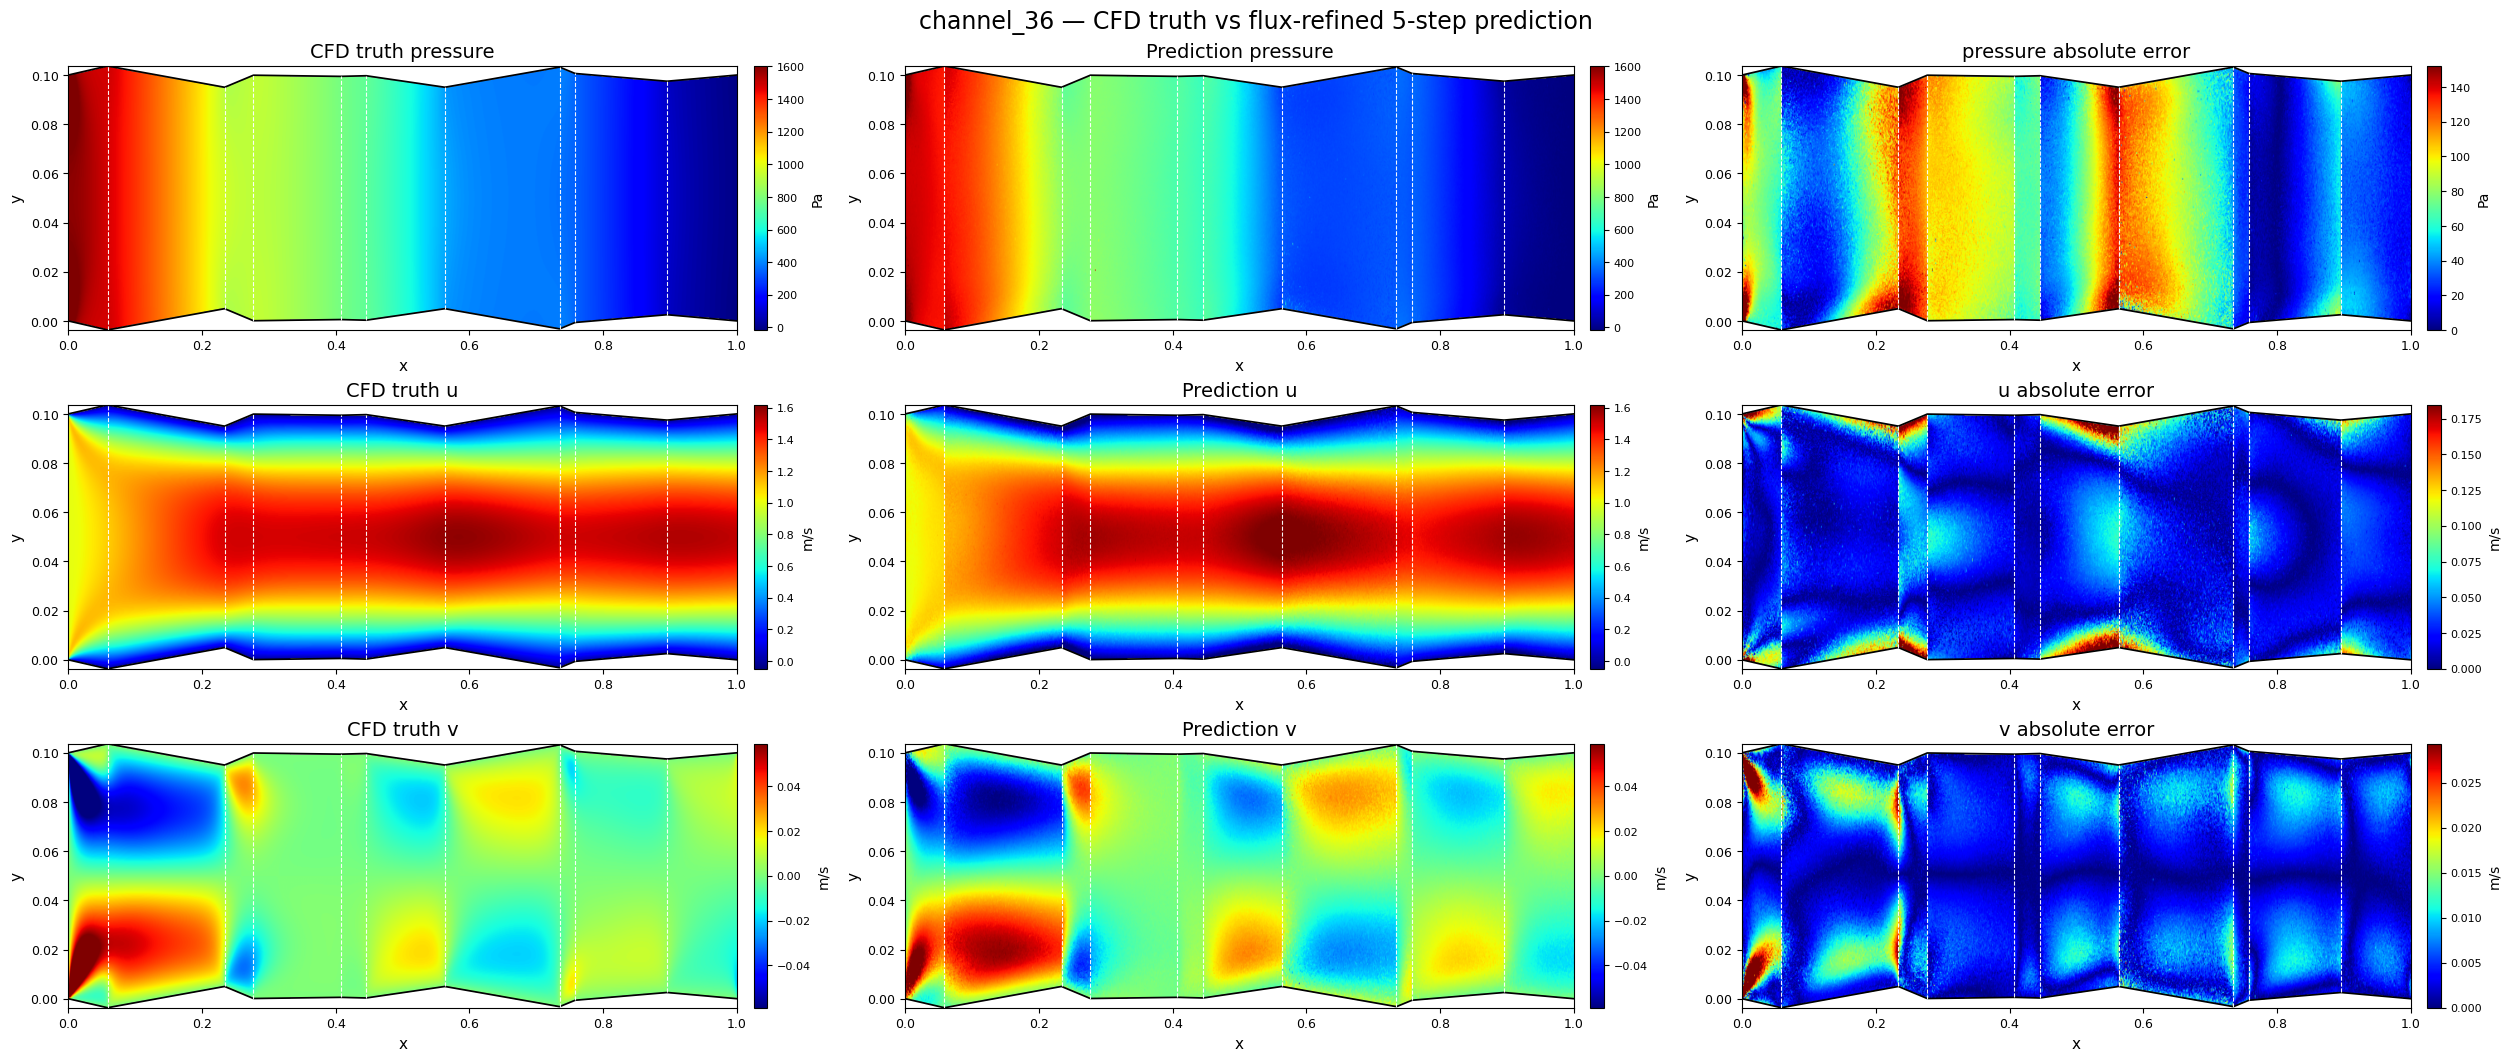

Target dataset path          : samples/<sample_index>/target
Truth array shape            : (227504, 3)
Prediction array shape       : (227504, 3)
Mapped points inside geometry: 100.000000%
Plot arrangement             : 3 rows × 3 columns
Colormap                     : jet

Pointwise evaluation metrics
  pressure   | RMSE=77.35461729 Pa | MAE=65.89244080 Pa | R²=0.970618 | corr=0.995861
  u          | RMSE=0.04182673 m/s | MAE=0.02905888 m/s | R²=0.990703 | corr=0.997171
  v          | RMSE=0.00791793 m/s | MAE=0.00524159 m/s | R²=0.839902 | corr=0.926982

Display ranges
  pressure   | truth/pred=-15.23052148 to +1602.52069658 | error=0 to 152.14432418
  u          | truth/pred=-0.05033491 to +1.61743801 | error=0 to 0.18455179
  v          | truth/pred=-0.05884040 to +0.05884040 | error=0 to 0.02931167

[READY] CFD truth, prediction, and absolute-error fields were plotted in a 3 × 3 layout.
[READY] CFD truth was used only for post-inference evaluation.


In [32]:
# ============================================================
# Cell 15 — CFD truth / prediction / absolute error
#
# Layout:
#   Row 1: pressure truth | pressure prediction | pressure error
#   Row 2: u truth        | u prediction        | u error
#   Row 3: v truth        | v prediction        | v error
#
# Plot style:
#   - jet colormap
#   - 3 rows × 3 columns
#   - truth and prediction share the same color range
#   - absolute error uses its own range starting from zero
#   - black channel walls
#   - white dashed internal interfaces
#
# Important:
#   CFD truth is loaded here only for post-inference evaluation.
#   It was not used in initialization or optimization.
# ============================================================

from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


print("=" * 152)
print("Cell 15 — CFD truth, prediction, and absolute-error fields")
print("=" * 152)


# ============================================================
# 1. Dataset path
# ============================================================

H5_PATH = Path(
    "/home/nuoxu9/PIDIF/"
    "channel_diffusion_dataset/"
    "deeponet_style_dataset/"
    "channel_deeponet_style_pressure_u_v_controlpoints.h5"
)

if not H5_PATH.exists():
    raise FileNotFoundError(
        f"H5 dataset does not exist:\n{H5_PATH}"
    )


# ============================================================
# 2–3. Load per-sample CFD target and coordinate metadata
#
# H5 structure:
#     samples/<sample_index>/target
#
# CFD truth is loaded here only for post-inference evaluation.
# ============================================================

coordinate_metadata_names = [
    "x_left_mm",
    "x_right_mm",
    "y_local_origin_mm",
    "y_local_scale_mm",
]

coordinate_metadata = {
    name: []
    for name in coordinate_metadata_names
}

cfd_truth_physical_list = []

target_dataset_paths = []


with h5py.File(
    H5_PATH,
    "r",
) as h5_file:

    for sample_index in channel_sample_indices:

        # ----------------------------------------------------
        # A. Geometry metadata
        #
        # Prefer global metadata/<name>[sample_index].
        # Fall back to samples/<index>/metadata/<name>.
        # ----------------------------------------------------

        for metadata_name in coordinate_metadata_names:

            global_metadata_path = (
                f"metadata/{metadata_name}"
            )

            grouped_metadata_path = (
                f"samples/{sample_index}/metadata/{metadata_name}"
            )

            direct_grouped_metadata_path = (
                f"samples/{sample_index}/{metadata_name}"
            )

            if global_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        global_metadata_path
                    ][
                        sample_index
                    ]
                ).reshape(-1)

            elif grouped_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        grouped_metadata_path
                    ][()]
                ).reshape(-1)

            elif direct_grouped_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        direct_grouped_metadata_path
                    ][()]
                ).reshape(-1)

            else:

                raise KeyError(
                    "Could not locate coordinate metadata:\n"
                    f"sample index   : {sample_index}\n"
                    f"metadata name  : {metadata_name}\n"
                    f"checked paths  :\n"
                    f"  {global_metadata_path}\n"
                    f"  {grouped_metadata_path}\n"
                    f"  {direct_grouped_metadata_path}"
                )

            coordinate_metadata[
                metadata_name
            ].append(
                float(
                    metadata_value[0]
                )
            )


        # ----------------------------------------------------
        # B. Per-sample CFD target
        # ----------------------------------------------------

        target_path_candidates = [
            f"samples/{sample_index}/target",
            f"samples/{sample_index}/targets",
            f"samples/{sample_index}/field",
            f"samples/{sample_index}/fields",
        ]

        target_dataset_path = None

        for candidate_path in target_path_candidates:

            if (
                candidate_path in h5_file
                and isinstance(
                    h5_file[
                        candidate_path
                    ],
                    h5py.Dataset,
                )
            ):

                target_dataset_path = candidate_path
                break


        if target_dataset_path is None:

            sample_group_path = (
                f"samples/{sample_index}"
            )

            if sample_group_path not in h5_file:

                raise KeyError(
                    f"Missing H5 sample group: "
                    f"{sample_group_path}"
                )

            available_items = list(
                h5_file[
                    sample_group_path
                ].keys()
            )

            raise KeyError(
                "Could not locate target for sample:\n"
                f"sample index    : {sample_index}\n"
                f"sample group    : {sample_group_path}\n"
                f"available items : {available_items}"
            )


        target_dataset_paths.append(
            target_dataset_path
        )


        target_array = np.asarray(
            h5_file[
                target_dataset_path
            ][()],
            dtype=np.float32,
        )


        # ----------------------------------------------------
        # C. Normalize target shape to (N_points, 3)
        # ----------------------------------------------------

        target_array = np.squeeze(
            target_array
        )


        if target_array.ndim == 1:

            if target_array.size % 3 != 0:

                raise RuntimeError(
                    f"Target sample {sample_index} has shape "
                    f"{target_array.shape} and cannot be "
                    "reshaped to (-1, 3)."
                )

            target_array = target_array.reshape(
                -1,
                3,
            )


        elif target_array.ndim == 2:

            if target_array.shape[1] == 3:

                pass

            elif target_array.shape[0] == 3:

                target_array = (
                    target_array.T
                )

            else:

                raise RuntimeError(
                    f"Unexpected 2D target shape for sample "
                    f"{sample_index}: {target_array.shape}"
                )


        else:

            if target_array.shape[-1] == 3:

                target_array = (
                    target_array.reshape(
                        -1,
                        3,
                    )
                )

            elif target_array.shape[0] == 3:

                target_array = (
                    np.moveaxis(
                        target_array,
                        0,
                        -1,
                    )
                    .reshape(
                        -1,
                        3,
                    )
                )

            else:

                raise RuntimeError(
                    f"Unexpected target shape for sample "
                    f"{sample_index}: {target_array.shape}"
                )


        cfd_truth_physical_list.append(
            target_array.astype(
                np.float32,
                copy=False,
            )
        )


for metadata_name in coordinate_metadata:

    coordinate_metadata[
        metadata_name
    ] = np.asarray(
        coordinate_metadata[
            metadata_name
        ],
        dtype=np.float64,
    )


# Keep a printable target description for the diagnostics
# section at the end of Cell 15.
target_dataset_path = (
    "samples/<sample_index>/target"
)


print(
    "Loaded target paths:"
)

for path in target_dataset_paths:

    print(
        " ",
        path,
    )

print(
    "\nLoaded target shapes:"
)

for subdomain_id, target_array in enumerate(
    cfd_truth_physical_list
):

    print(
        f"  subdomain {subdomain_id:02d}: "
        f"{target_array.shape}"
    )

# ============================================================
# Cell 15 patch — Recover query lengths from channel_query_list
# ============================================================

query_lengths = np.asarray(
    [
        int(
            np.asarray(
                channel_query_list[
                    subdomain_id
                ]
            ).shape[0]
        )
        for subdomain_id in range(
            NUM_SUBDOMAINS
        )
    ],
    dtype=np.int64,
)


query_offsets = np.concatenate(
    [
        np.asarray(
            [0],
            dtype=np.int64,
        ),
        np.cumsum(
            query_lengths,
            dtype=np.int64,
        ),
    ]
)


if int(
    query_lengths.sum()
) != int(
    pretruth_selected_prediction_physical_np.shape[0]
):

    raise RuntimeError(
        "Recovered query lengths do not match the final "
        "prediction length:\n"
        f"sum(query_lengths) = {query_lengths.sum()}\n"
        f"prediction points  = "
        f"{pretruth_selected_prediction_physical_np.shape[0]}"
    )


print(
    "Recovered query lengths:",
    query_lengths.tolist(),
)

print(
    "Recovered query offsets:",
    query_offsets.tolist(),
)

print(
    "Total query points:",
    int(
        query_lengths.sum()
    ),
)

# ============================================================
# 4. Validate target lengths
# ============================================================

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    expected_count = int(
        query_lengths[
            subdomain_id
        ]
    )

    actual_count = int(
        cfd_truth_physical_list[
            subdomain_id
        ].shape[0]
    )

    if actual_count != expected_count:
        raise RuntimeError(
            f"Subdomain {subdomain_id}: target/query count "
            f"mismatch: target={actual_count}, "
            f"query={expected_count}"
        )


cfd_truth_physical_np = np.concatenate(
    cfd_truth_physical_list,
    axis=0,
)


if cfd_truth_physical_np.shape != (
    pretruth_selected_prediction_physical_np.shape
):
    raise RuntimeError(
        "Truth/prediction shape mismatch:\n"
        f"truth      = {cfd_truth_physical_np.shape}\n"
        f"prediction = {pretruth_selected_prediction_physical_np.shape}"
    )


# ============================================================
# 5. Convert local query coordinates to global coordinates
# ============================================================

global_query_list_mm = []
global_query_subdomain_id_list = []


for subdomain_id in range(
    NUM_SUBDOMAINS
):

    local_query = np.asarray(
        channel_query_list[
            subdomain_id
        ],
        dtype=np.float64,
    )

    x_left_local = coordinate_metadata[
        "x_left_mm"
    ][
        subdomain_id
    ]

    x_right_local = coordinate_metadata[
        "x_right_mm"
    ][
        subdomain_id
    ]

    y_origin_local = coordinate_metadata[
        "y_local_origin_mm"
    ][
        subdomain_id
    ]

    y_scale_local = coordinate_metadata[
        "y_local_scale_mm"
    ][
        subdomain_id
    ]

    x_global_mm = (
        x_left_local
        + local_query[:, 0]
        * (
            x_right_local
            - x_left_local
        )
    )

    y_global_mm = (
        y_origin_local
        + local_query[:, 1]
        * y_scale_local
    )

    global_coordinates = np.column_stack(
        [
            x_global_mm,
            y_global_mm,
        ]
    )

    global_query_list_mm.append(
        global_coordinates
    )

    global_query_subdomain_id_list.append(
        np.full(
            global_coordinates.shape[0],
            subdomain_id,
            dtype=np.int64,
        )
    )


global_query_mm = np.concatenate(
    global_query_list_mm,
    axis=0,
)

global_query_subdomain_id = np.concatenate(
    global_query_subdomain_id_list,
    axis=0,
)


# ============================================================
# 6. Determine valid query points inside channel geometry
# ============================================================

bottom_at_query_mm = np.interp(
    global_query_mm[:, 0],
    x_points_mm,
    bottom_y_mm,
)

top_at_query_mm = np.interp(
    global_query_mm[:, 0],
    x_points_mm,
    top_y_mm,
)


GEOMETRY_TOLERANCE_MM = 2.0e-5

inside_geometry_mask = (
    (
        global_query_mm[:, 1]
        >= bottom_at_query_mm
        - GEOMETRY_TOLERANCE_MM
    )
    & (
        global_query_mm[:, 1]
        <= top_at_query_mm
        + GEOMETRY_TOLERANCE_MM
    )
)


inside_fraction = float(
    inside_geometry_mask.mean()
)


# ============================================================
# 7. Regular plotting grid
# ============================================================

N_X_PLOT = 1200
N_Y_PLOT = 300


x_plot_mm = np.linspace(
    float(x_points_mm.min()),
    float(x_points_mm.max()),
    N_X_PLOT,
)

y_plot_mm = np.linspace(
    float(bottom_y_mm.min()),
    float(top_y_mm.max()),
    N_Y_PLOT,
)


X_PLOT_MM, Y_PLOT_MM = np.meshgrid(
    x_plot_mm,
    y_plot_mm,
)


bottom_plot_mm = np.interp(
    x_plot_mm,
    x_points_mm,
    bottom_y_mm,
)

top_plot_mm = np.interp(
    x_plot_mm,
    x_points_mm,
    top_y_mm,
)


channel_plot_mask = (
    (
        Y_PLOT_MM
        >= bottom_plot_mm[None, :]
    )
    & (
        Y_PLOT_MM
        <= top_plot_mm[None, :]
    )
)


# ============================================================
# 8. Interpolate one complete field onto plotting grid
#
# Interpolation is performed subdomain-by-subdomain to avoid
# connecting non-neighboring points across decomposition blocks.
# ============================================================

def interpolate_complete_field_to_grid(
    field_list,
):

    output_grids = [
        np.full(
            X_PLOT_MM.shape,
            np.nan,
            dtype=np.float64,
        )
        for _ in range(3)
    ]

    for subdomain_id in range(
        NUM_SUBDOMAINS
    ):

        query_coordinates = (
            global_query_list_mm[
                subdomain_id
            ]
        )

        field_values = np.asarray(
            field_list[
                subdomain_id
            ],
            dtype=np.float64,
        )

        x_left_local = float(
            coordinate_metadata[
                "x_left_mm"
            ][
                subdomain_id
            ]
        )

        x_right_local = float(
            coordinate_metadata[
                "x_right_mm"
            ][
                subdomain_id
            ]
        )

        grid_column_indices = np.where(
            (
                x_plot_mm
                >= x_left_local
            )
            & (
                x_plot_mm
                <= x_right_local
            )
        )[0]

        if grid_column_indices.size == 0:
            continue

        X_SUBGRID = X_PLOT_MM[
            :,
            grid_column_indices,
        ]

        Y_SUBGRID = Y_PLOT_MM[
            :,
            grid_column_indices,
        ]

        for field_index in range(3):

            interpolated_subgrid = griddata(
                points=query_coordinates,
                values=field_values[
                    :,
                    field_index,
                ],
                xi=(
                    X_SUBGRID,
                    Y_SUBGRID,
                ),
                method="linear",
            )

            missing_mask = ~np.isfinite(
                interpolated_subgrid
            )

            if missing_mask.any():

                nearest_subgrid = griddata(
                    points=query_coordinates,
                    values=field_values[
                        :,
                        field_index,
                    ],
                    xi=(
                        X_SUBGRID,
                        Y_SUBGRID,
                    ),
                    method="nearest",
                )

                interpolated_subgrid[
                    missing_mask
                ] = nearest_subgrid[
                    missing_mask
                ]

            output_grids[
                field_index
            ][
                :,
                grid_column_indices,
            ] = interpolated_subgrid

    for field_index in range(3):

        output_grids[
            field_index
        ][
            ~channel_plot_mask
        ] = np.nan

    return output_grids


# ============================================================
# 9. Prepare prediction lists as NumPy arrays
# ============================================================

pretruth_selected_prediction_physical_list_np = [
    tensor.detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
    for tensor in pretruth_selected_prediction_physical_list
]


# ============================================================
# 10. Interpolate truth and prediction
# ============================================================

truth_grids = interpolate_complete_field_to_grid(
    cfd_truth_physical_list
)

pretruth_selected_prediction_grids = interpolate_complete_field_to_grid(
    pretruth_selected_prediction_physical_list_np
)


pretruth_selected_absolute_error_grids = [
    np.abs(
        pretruth_selected_prediction_grids[field_index]
        - truth_grids[field_index]
    )
    for field_index in range(3)
]


# ============================================================
# 11. Plot configuration
# ============================================================

FIELD_NAMES = [
    "pressure",
    "u",
    "v",
]

FIELD_UNITS = [
    "Pa",
    "m/s",
    "m/s",
]


DISPLAY_LOW_PERCENTILE = 0.5
DISPLAY_HIGH_PERCENTILE = 99.5
ERROR_HIGH_PERCENTILE = 99.5


plot_extent = [
    float(x_plot_mm.min()),
    float(x_plot_mm.max()),
    float(y_plot_mm.min()),
    float(y_plot_mm.max()),
]


# ============================================================
# 12. Shared color limits for truth and prediction
# ============================================================

pretruth_selected_truth_prediction_ranges = []
pretruth_selected_absolute_error_ranges = []


for field_index in range(3):

    truth_values = truth_grids[
        field_index
    ][
        np.isfinite(
            truth_grids[
                field_index
            ]
        )
    ]

    prediction_values = pretruth_selected_prediction_grids[
        field_index
    ][
        np.isfinite(
            pretruth_selected_prediction_grids[
                field_index
            ]
        )
    ]

    combined_values = np.concatenate(
        [
            truth_values,
            prediction_values,
        ]
    )

    shared_vmin = float(
        np.percentile(
            combined_values,
            DISPLAY_LOW_PERCENTILE,
        )
    )

    shared_vmax = float(
        np.percentile(
            combined_values,
            DISPLAY_HIGH_PERCENTILE,
        )
    )

    # Keep v truth and prediction centered around zero.
    if field_index == 2:

        symmetric_limit = max(
            abs(shared_vmin),
            abs(shared_vmax),
        )

        shared_vmin = -symmetric_limit
        shared_vmax = symmetric_limit

    pretruth_selected_truth_prediction_ranges.append(
        (
            shared_vmin,
            shared_vmax,
        )
    )

    error_values = pretruth_selected_absolute_error_grids[
        field_index
    ][
        np.isfinite(
            pretruth_selected_absolute_error_grids[
                field_index
            ]
        )
    ]

    error_vmax = float(
        np.percentile(
            error_values,
            ERROR_HIGH_PERCENTILE,
        )
    )

    pretruth_selected_absolute_error_ranges.append(
        (
            0.0,
            error_vmax,
        )
    )


# ============================================================
# 13. Helper for channel outlines and interfaces
# ============================================================

def add_channel_geometry(
    axis,
):

    axis.plot(
        x_points_mm,
        bottom_y_mm,
        color="black",
        linewidth=1.25,
        zorder=5,
    )

    axis.plot(
        x_points_mm,
        top_y_mm,
        color="black",
        linewidth=1.25,
        zorder=5,
    )

    for interface_x_mm in x_points_mm[
        1:-1
    ]:

        interface_bottom_mm = float(
            np.interp(
                interface_x_mm,
                x_points_mm,
                bottom_y_mm,
            )
        )

        interface_top_mm = float(
            np.interp(
                interface_x_mm,
                x_points_mm,
                top_y_mm,
            )
        )

        axis.plot(
            [
                interface_x_mm,
                interface_x_mm,
            ],
            [
                interface_bottom_mm,
                interface_top_mm,
            ],
            color="white",
            linestyle="--",
            linewidth=0.8,
            alpha=0.95,
            zorder=6,
        )

    axis.set_xlim(
        float(x_points_mm.min()),
        float(x_points_mm.max()),
    )

    axis.set_ylim(
        float(bottom_y_mm.min()),
        float(top_y_mm.max()),
    )

    axis.set_xlabel(
        "x",
        fontsize=11,
    )

    axis.set_ylabel(
        "y",
        fontsize=11,
    )

    axis.tick_params(
        labelsize=9
    )


# ============================================================
# 14. Plot 3 rows × 3 columns
# ============================================================

figure, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(
        25,
        10.5,
    ),
    constrained_layout=True,
)


for field_index in range(3):

    field_name = FIELD_NAMES[
        field_index
    ]

    field_unit = FIELD_UNITS[
        field_index
    ]

    shared_vmin, shared_vmax = (
        pretruth_selected_truth_prediction_ranges[
            field_index
        ]
    )

    error_vmin, error_vmax = (
        pretruth_selected_absolute_error_ranges[
            field_index
        ]
    )

    # --------------------------------------------------------
    # Column 1: CFD truth
    # --------------------------------------------------------

    truth_image = axes[
        field_index,
        0,
    ].imshow(
        np.ma.masked_invalid(
            truth_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )

    axes[
        field_index,
        0,
    ].set_title(
        f"CFD truth {field_name}",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            0,
        ]
    )

    truth_colorbar = figure.colorbar(
        truth_image,
        ax=axes[
            field_index,
            0,
        ],
        pad=0.01,
        fraction=0.035,
    )

    truth_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    truth_colorbar.ax.tick_params(
        labelsize=8
    )

    # --------------------------------------------------------
    # Column 2: prediction
    # --------------------------------------------------------

    prediction_image = axes[
        field_index,
        1,
    ].imshow(
        np.ma.masked_invalid(
            pretruth_selected_prediction_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )

    axes[
        field_index,
        1,
    ].set_title(
        f"Prediction {field_name}",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            1,
        ]
    )

    prediction_colorbar = figure.colorbar(
        prediction_image,
        ax=axes[
            field_index,
            1,
        ],
        pad=0.01,
        fraction=0.035,
    )

    prediction_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    prediction_colorbar.ax.tick_params(
        labelsize=8
    )

    # --------------------------------------------------------
    # Column 3: absolute error
    # --------------------------------------------------------

    error_image = axes[
        field_index,
        2,
    ].imshow(
        np.ma.masked_invalid(
            pretruth_selected_absolute_error_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=error_vmin,
        vmax=error_vmax,
    )

    axes[
        field_index,
        2,
    ].set_title(
        f"{field_name} absolute error",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            2,
        ]
    )

    error_colorbar = figure.colorbar(
        error_image,
        ax=axes[
            field_index,
            2,
        ],
        pad=0.01,
        fraction=0.035,
    )

    error_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    error_colorbar.ax.tick_params(
        labelsize=8
    )


figure.suptitle(
    f"{CASE_NAME} — CFD truth vs "
    f"{PRETRUTH_SELECTED_INTERFACE_STATE_NAME} "
    "5-step pre-truth selected prediction",
    fontsize=17,
)


plt.show()


# ============================================================
# 15. Pointwise metrics over valid original query points
# ============================================================

truth_valid = cfd_truth_physical_np[
    inside_geometry_mask
]

prediction_valid = pretruth_selected_prediction_physical_np[
    inside_geometry_mask
]

pointwise_error = (
    prediction_valid
    - truth_valid
)


pretruth_selected_evaluation_metrics = {}


for field_index, (
    field_name,
    field_unit,
) in enumerate(
    zip(
        FIELD_NAMES,
        FIELD_UNITS,
    )
):

    truth_field = truth_valid[
        :,
        field_index
    ]

    prediction_field = prediction_valid[
        :,
        field_index
    ]

    error_field = pointwise_error[
        :,
        field_index
    ]

    mse = float(
        np.mean(
            error_field ** 2
        )
    )

    rmse = float(
        np.sqrt(mse)
    )

    mae = float(
        np.mean(
            np.abs(
                error_field
            )
        )
    )

    truth_variance = float(
        np.var(
            truth_field
        )
    )

    r2 = (
        1.0
        - mse / truth_variance
        if truth_variance > 0.0
        else np.nan
    )

    correlation = float(
        np.corrcoef(
            truth_field,
            prediction_field,
        )[0, 1]
    )

    pretruth_selected_evaluation_metrics[
        field_name
    ] = {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "correlation": correlation,
        "unit": field_unit,
    }


# ============================================================
# 16. Save evaluation and plotting state
# ============================================================

pretruth_selected_visualization_state = {
    "prediction_protocol": (
        "pretruth_selected"
    ),

    "prediction_interface_state_name": (
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ),

    "prediction_selection_used_cfd_truth": (
        False
    ),

    "metrics_used_cfd_truth": (
        True
    ),
    "target_dataset_path": (
        target_dataset_path
    ),

    "global_query_mm": (
        global_query_mm
    ),

    "global_query_list_mm": (
        global_query_list_mm
    ),

    "global_query_subdomain_id": (
        global_query_subdomain_id
    ),

    "inside_geometry_mask": (
        inside_geometry_mask
    ),

    "truth_physical_np": (
        cfd_truth_physical_np
    ),

    "prediction_physical_np": (
        pretruth_selected_prediction_physical_np
    ),

    "truth_grids": (
        truth_grids
    ),

    "pretruth_selected_prediction_grids": (
        pretruth_selected_prediction_grids
    ),

    "pretruth_selected_absolute_error_grids": (
        pretruth_selected_absolute_error_grids
    ),

    "pretruth_selected_truth_prediction_ranges": (
        pretruth_selected_truth_prediction_ranges
    ),

    "pretruth_selected_absolute_error_ranges": (
        pretruth_selected_absolute_error_ranges
    ),

    "pretruth_selected_evaluation_metrics": (
        pretruth_selected_evaluation_metrics
    ),
}


# ============================================================
# 17. Diagnostics
# ============================================================

print(
    "Target dataset path          :",
    target_dataset_path,
)

print(
    "Truth array shape            :",
    cfd_truth_physical_np.shape,
)

print(
    "Pre-truth prediction array shape:",
    pretruth_selected_prediction_physical_np.shape,
)

print(
    "Mapped points inside geometry:",
    f"{inside_fraction * 100.0:.6f}%",
)

print(
    "Plot arrangement             :",
    "3 rows × 3 columns",
)

print(
    "Colormap                     :",
    "jet",
)


print("\nPre-truth selected candidate metrics")

for field_name in FIELD_NAMES:

    metrics = pretruth_selected_evaluation_metrics[
        field_name
    ]

    print(
        f"  {field_name:<10} | "
        f"RMSE={metrics['rmse']:.8f} {metrics['unit']} | "
        f"MAE={metrics['mae']:.8f} {metrics['unit']} | "
        f"R²={metrics['r2']:.6f} | "
        f"corr={metrics['correlation']:.6f}"
    )


print("\nDisplay ranges")

for field_index, field_name in enumerate(
    FIELD_NAMES
):

    shared_vmin, shared_vmax = (
        pretruth_selected_truth_prediction_ranges[
            field_index
        ]
    )

    _, error_vmax = (
        pretruth_selected_absolute_error_ranges[
            field_index
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"truth/pred={shared_vmin:+.8f} to "
        f"{shared_vmax:+.8f} | "
        f"error=0 to {error_vmax:.8f}"
    )


print("\n" + "=" * 152)

print(
    "[READY] CFD truth, prediction, and absolute-error fields "
    "were plotted in a 3 × 3 layout."
)

print(
    "[READY] CFD truth was used for pre-truth metrics only; "
    "it did not select the candidate."
)

print("=" * 152)

Cell 16 — Post-hoc comparison of truth-free interface strategies

Overall candidate comparison
----------------------------------------------------------------------------------------------------------------------------------------------------------

[Zero interface]
  average normalized RMSE/std: 2.181903
  pressure   | RMSE=470.88708603 Pa | MAE=352.59454459 Pa | NRMSE/std=1.043452 | R²=-0.088792 | corr=0.339007
  u          | RMSE=0.37535803 m/s | MAE=0.30952015 m/s | NRMSE/std=0.865314 | R²=0.251231 | corr=0.505646
  v          | RMSE=0.09175936 m/s | MAE=0.05125532 m/s | NRMSE/std=4.636942 | R²=-20.501229 | corr=0.280788

[Physics initialization]
  average normalized RMSE/std: 0.308753
  pressure   | RMSE=74.96079736 Pa | MAE=39.17889649 Pa | NRMSE/std=0.166108 | R²=0.972408 | corr=0.989700
  u          | RMSE=0.05878845 m/s | MAE=0.03878206 m/s | NRMSE/std=0.135525 | R²=0.981633 | corr=0.992946
  v          | RMSE=0.01236057 m/s | MAE=0.00645118 m/s | NRMSE/std=0.624625 | R²=0.60

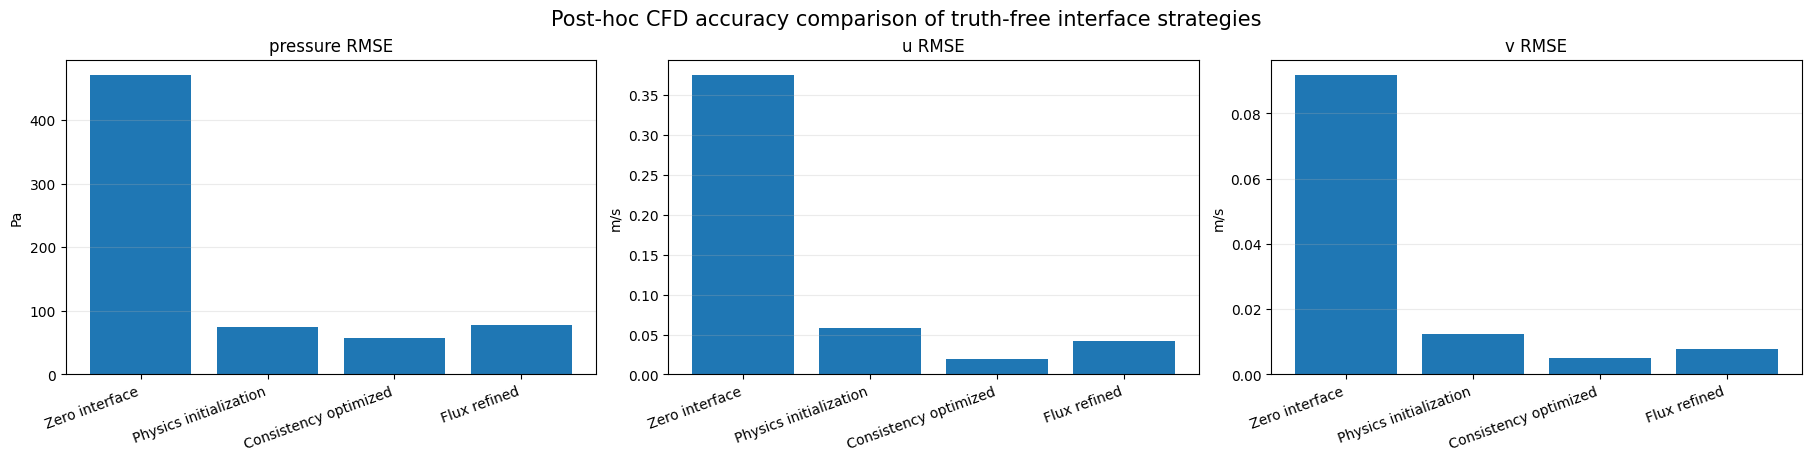

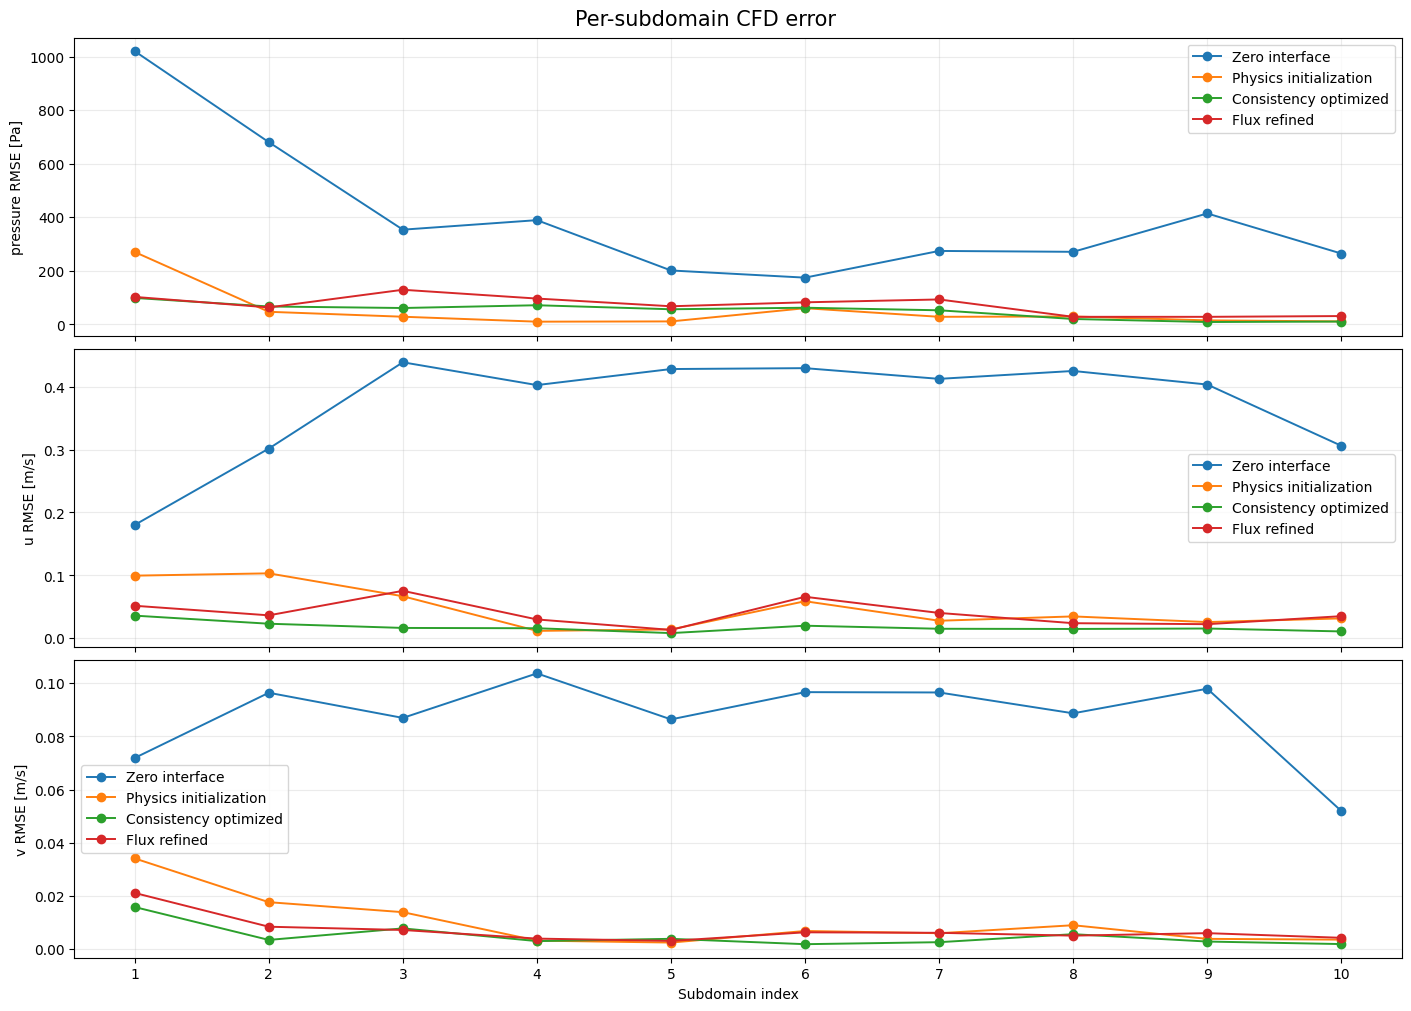


[READY] All four truth-free interface strategies were evaluated against CFD after inference.
[READY] CFD truth did not participate in initialization or optimization.
[NEXT] Use the comparison to determine whether flux refinement improves physical conservation at the cost of prediction accuracy.


In [33]:
# ============================================================
# Cell 16 — Post-hoc comparison of all truth-free candidates
#
# Compare:
#   1. zero
#   2. physics_initial
#   3. consistency_optimized
#   4. flux_refined
#
# Metrics:
#   - RMSE
#   - MAE
#   - normalized RMSE
#   - R²
#   - correlation
#   - per-subdomain RMSE
#
# CFD truth is used only for post-inference evaluation.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


print("=" * 154)
print("Cell 16 — Post-hoc comparison of truth-free interface strategies")
print("=" * 154)


# ============================================================
# 1. Candidate order and labels
# ============================================================

CANDIDATE_NAMES = [
    "zero",
    "physics_initial",
    "consistency_optimized",
    "flux_refined",
]

CANDIDATE_LABELS = {
    "zero": "Zero interface",
    "physics_initial": "Physics initialization",
    "consistency_optimized": "Consistency optimized",
    "flux_refined": "Flux refined",
}

FIELD_NAMES = [
    "pressure",
    "u",
    "v",
]

FIELD_UNITS = [
    "Pa",
    "m/s",
    "m/s",
]


# ============================================================
# 2. CFD truth over valid original query points
# ============================================================

truth_valid = cfd_truth_physical_np[
    inside_geometry_mask
].astype(
    np.float64,
    copy=False,
)


truth_mean = truth_valid.mean(
    axis=0
)

truth_std = truth_valid.std(
    axis=0
)

truth_variance = truth_valid.var(
    axis=0
)

truth_range = (
    truth_valid.max(axis=0)
    - truth_valid.min(axis=0)
)


# ============================================================
# 3. Metric helper
# ============================================================

def compute_candidate_metrics(
    prediction_physical_np,
):
    """
    Evaluate one candidate against CFD truth over valid points.
    """

    prediction_valid = prediction_physical_np[
        inside_geometry_mask
    ].astype(
        np.float64,
        copy=False,
    )

    error = (
        prediction_valid
        - truth_valid
    )

    mse = np.mean(
        error ** 2,
        axis=0,
    )

    rmse = np.sqrt(
        mse
    )

    mae = np.mean(
        np.abs(error),
        axis=0,
    )

    normalized_rmse_std = (
        rmse
        / np.maximum(
            truth_std,
            1.0e-12,
        )
    )

    normalized_rmse_range = (
        rmse
        / np.maximum(
            truth_range,
            1.0e-12,
        )
    )

    r2 = (
        1.0
        - mse
        / np.maximum(
            truth_variance,
            1.0e-12,
        )
    )

    correlation = np.zeros(
        3,
        dtype=np.float64,
    )

    for field_index in range(3):

        correlation[
            field_index
        ] = np.corrcoef(
            truth_valid[
                :,
                field_index
            ],
            prediction_valid[
                :,
                field_index
            ],
        )[0, 1]

    return {
        "prediction_valid": (
            prediction_valid
        ),

        "error": (
            error
        ),

        "mse": (
            mse
        ),

        "rmse": (
            rmse
        ),

        "mae": (
            mae
        ),

        "nrmse_std": (
            normalized_rmse_std
        ),

        "nrmse_range": (
            normalized_rmse_range
        ),

        "r2": (
            r2
        ),

        "correlation": (
            correlation
        ),
    }


# ============================================================
# 4. Evaluate all four candidate fields
# ============================================================

candidate_metrics_by_name = {}


for candidate_name in CANDIDATE_NAMES:

    candidate_prediction_np = (
        full_field_results[
            candidate_name
        ][
            "physical"
        ]
        .detach()
        .cpu()
        .numpy()
    )

    candidate_metrics_by_name[
        candidate_name
    ] = compute_candidate_metrics(
        candidate_prediction_np
    )


# ============================================================
# 5. Aggregate score
#
# Average normalized RMSE by truth standard deviation.
# Lower is better.
# ============================================================

for candidate_name in CANDIDATE_NAMES:

    candidate_metrics_by_name[
        candidate_name
    ][
        "average_nrmse_std"
    ] = float(
        np.mean(
            candidate_metrics_by_name[
                candidate_name
            ][
                "nrmse_std"
            ]
        )
    )


ORACLE_SELECTED_INTERFACE_STATE_NAME = min(
    CANDIDATE_NAMES,
    key=lambda name: (
        candidate_metrics_by_name[
            name
        ][
            "average_nrmse_std"
        ]
    ),
)

pretruth_selected_metrics = candidate_metrics_by_name[
    PRETRUTH_SELECTED_INTERFACE_STATE_NAME
]

oracle_posthoc_metrics = candidate_metrics_by_name[
    ORACLE_SELECTED_INTERFACE_STATE_NAME
]


# ============================================================
# 6. Per-subdomain RMSE
# ============================================================

per_subdomain_rmse = {
    candidate_name: np.zeros(
        (
            NUM_SUBDOMAINS,
            3,
        ),
        dtype=np.float64,
    )
    for candidate_name in CANDIDATE_NAMES
}


for subdomain_id in range(
    NUM_SUBDOMAINS
):

    start = int(
        query_offsets[
            subdomain_id
        ]
    )

    end = int(
        query_offsets[
            subdomain_id + 1
        ]
    )

    truth_subdomain = (
        cfd_truth_physical_np[
            start:end
        ].astype(
            np.float64,
            copy=False,
        )
    )

    for candidate_name in CANDIDATE_NAMES:

        prediction_subdomain = (
            full_field_results[
                candidate_name
            ][
                "physical"
            ][
                start:end
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.float64,
                copy=False,
            )
        )

        per_subdomain_rmse[
            candidate_name
        ][
            subdomain_id
        ] = np.sqrt(
            np.mean(
                (
                    prediction_subdomain
                    - truth_subdomain
                ) ** 2,
                axis=0,
            )
        )


# ============================================================
# 7. Print overall comparison table
# ============================================================

print("\nOverall candidate comparison")
print("-" * 154)

for candidate_name in CANDIDATE_NAMES:

    result = candidate_metrics_by_name[
        candidate_name
    ]

    print(
        f"\n[{CANDIDATE_LABELS[candidate_name]}]"
    )

    print(
        f"  average normalized RMSE/std: "
        f"{result['average_nrmse_std']:.6f}"
    )

    for field_index, (
        field_name,
        field_unit,
    ) in enumerate(
        zip(
            FIELD_NAMES,
            FIELD_UNITS,
        )
    ):

        print(
            f"  {field_name:<10} | "
            f"RMSE={result['rmse'][field_index]:.8f} {field_unit} | "
            f"MAE={result['mae'][field_index]:.8f} {field_unit} | "
            f"NRMSE/std={result['nrmse_std'][field_index]:.6f} | "
            f"R²={result['r2'][field_index]:.6f} | "
            f"corr={result['correlation'][field_index]:.6f}"
        )


print("\n" + "-" * 154)

print(
    "Pre-truth selected candidate:",
    PRETRUTH_SELECTED_INTERFACE_STATE_NAME,
)

print(
    "Pre-truth candidate selected using CFD target truth:",
    False,
)

print(
    "Pre-truth candidate evaluated using CFD target truth:",
    True,
)

print(
    "Pre-truth average normalized RMSE/std:",
    f"{pretruth_selected_metrics['average_nrmse_std']:.6f}",
)

print(
    "Oracle/post-hoc selected candidate:",
    ORACLE_SELECTED_INTERFACE_STATE_NAME,
)

print(
    "Oracle/post-hoc selection used CFD target truth:",
    True,
)

print(
    "Oracle average normalized RMSE/std:",
    f"{oracle_posthoc_metrics['average_nrmse_std']:.6f}",
)


# 8. Compact RMSE comparison plot
# ============================================================

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(
        18,
        4.5,
    ),
    constrained_layout=True,
)


candidate_x = np.arange(
    len(
        CANDIDATE_NAMES
    )
)

candidate_tick_labels = [
    CANDIDATE_LABELS[
        name
    ]
    for name in CANDIDATE_NAMES
]


for field_index, axis in enumerate(
    axes
):

    field_rmse_values = [
        candidate_metrics_by_name[
            candidate_name
        ][
            "rmse"
        ][
            field_index
        ]
        for candidate_name in CANDIDATE_NAMES
    ]

    axis.bar(
        candidate_x,
        field_rmse_values,
    )

    axis.set_xticks(
        candidate_x
    )

    axis.set_xticklabels(
        candidate_tick_labels,
        rotation=20,
        ha="right",
    )

    axis.set_title(
        f"{FIELD_NAMES[field_index]} RMSE"
    )

    axis.set_ylabel(
        FIELD_UNITS[
            field_index
        ]
    )

    axis.grid(
        axis="y",
        alpha=0.25,
    )


figure.suptitle(
    "CFD diagnostic comparison of truth-free interface candidates",
    fontsize=15,
)

plt.show()


# ============================================================
# 9. Per-subdomain RMSE curves
# ============================================================

figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(
        14,
        10,
    ),
    sharex=True,
    constrained_layout=True,
)


subdomain_axis = np.arange(
    1,
    NUM_SUBDOMAINS + 1,
)


for field_index, axis in enumerate(
    axes
):

    for candidate_name in CANDIDATE_NAMES:

        axis.plot(
            subdomain_axis,
            per_subdomain_rmse[
                candidate_name
            ][
                :,
                field_index
            ],
            marker="o",
            linewidth=1.4,
            label=CANDIDATE_LABELS[
                candidate_name
            ],
        )

    axis.set_ylabel(
        f"{FIELD_NAMES[field_index]} RMSE "
        f"[{FIELD_UNITS[field_index]}]"
    )

    axis.grid(
        alpha=0.25
    )

    axis.legend(
        loc="best"
    )


axes[-1].set_xlabel(
    "Subdomain index"
)

axes[-1].set_xticks(
    subdomain_axis
)


figure.suptitle(
    "Per-subdomain CFD error",
    fontsize=15,
)

plt.show()


# ============================================================
# 10. Preserve evaluation state
# ============================================================

candidate_comparison_state = {
    "candidate_metrics_by_name": (
        candidate_metrics_by_name
    ),

    "per_subdomain_rmse": (
        per_subdomain_rmse
    ),

    "oracle_selected_interface_state_name": (
        ORACLE_SELECTED_INTERFACE_STATE_NAME
    ),

    "oracle_selected_interface_state_label": (
        CANDIDATE_LABELS[
            ORACLE_SELECTED_INTERFACE_STATE_NAME
        ]
    ),

    "pretruth_selected_interface_state_name": (
        PRETRUTH_SELECTED_INTERFACE_STATE_NAME
    ),

    "pretruth_selected_metrics": (
        pretruth_selected_metrics
    ),

    "oracle_posthoc_metrics": (
        oracle_posthoc_metrics
    ),
}


print("\n" + "=" * 154)

print(
    "[READY] All four truth-free interface strategies were "
    "evaluated against CFD after inference."
)

print(
    "[READY] CFD truth did not participate in initialization "
    "or optimization; oracle selection is reported separately."
)

print(
    "[NEXT] Treat the pre-truth candidate and oracle/post-hoc "
    "candidate as separate protocols."
)

print("=" * 154)

In [34]:
# ============================================================
# Cell 16B — Preserve the oracle/post-hoc selected solution
#
# Cell 16 selected an oracle/post-hoc candidate using CFD truth.
# The candidate name remains dynamic and is kept separate from
# the pre-truth selected candidate.
#
# CFD truth is used for oracle/post-hoc candidate selection here.
# It did not participate in interface optimization.
# ============================================================

import numpy as np
import torch


print("=" * 150)
print("Cell 16B — Preserve oracle/post-hoc selected field")
print("=" * 150)


# ============================================================
# 1. Preserve the dynamically selected oracle/post-hoc candidate
#
# ORACLE_SELECTED_INTERFACE_STATE_NAME was computed in Cell 16
# from CFD truth metrics.  It must not overwrite pre-truth state.
# ============================================================

oracle_posthoc_full_field_result = (
    full_field_results[
        ORACLE_SELECTED_INTERFACE_STATE_NAME
    ]
)


# 2. Select the already-generated oracle/post-hoc interface state
# ============================================================

oracle_posthoc_interface_state = (
    candidate_interface_states[
        ORACLE_SELECTED_INTERFACE_STATE_NAME
    ]
    .detach()
    .clone()
)

oracle_posthoc_interface_normalized = (
    oracle_posthoc_interface_state
)

oracle_posthoc_interface_physical = (
    interface_normalized_to_physical(
        oracle_posthoc_interface_normalized
    )
    .detach()
    .clone()
)


# 3. Preserve the oracle/post-hoc full-field prediction
# ============================================================

oracle_posthoc_prediction_normalized = (
    oracle_posthoc_full_field_result[
        "normalized"
    ]
    .detach()
    .clone()
)

oracle_posthoc_prediction_physical = (
    oracle_posthoc_full_field_result[
        "physical"
    ]
    .detach()
    .clone()
)

oracle_posthoc_prediction_normalized_list = [
    tensor.detach().clone()
    for tensor in oracle_posthoc_full_field_result[
        "normalized_list"
    ]
]

oracle_posthoc_prediction_physical_list = [
    tensor.detach().clone()
    for tensor in oracle_posthoc_full_field_result[
        "physical_list"
    ]
]


# 4. CPU NumPy arrays used by plotting and saving cells
# ============================================================

oracle_posthoc_prediction_normalized_np = (
    oracle_posthoc_prediction_normalized
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

oracle_posthoc_prediction_physical_np = (
    oracle_posthoc_prediction_physical
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

oracle_posthoc_interface_normalized_np = (
    oracle_posthoc_interface_normalized
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)

oracle_posthoc_interface_physical_np = (
    oracle_posthoc_interface_physical
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
)


# ============================================================
# 5. Restore Stage-1 interface diagnostics
# ============================================================

consistency_interface_result = (
    interface_optimization_state[
        "optimized_result"
    ]
)


consistency_flow_rates = (
    consistency_interface_result[
        "interface_flow_rates"
    ]
    .detach()
    .cpu()
    .numpy()
)

consistency_flow_residuals = (
    consistency_interface_result[
        "relative_flow_residual"
    ]
    .detach()
    .cpu()
    .numpy()
)

consistency_pressure_means = (
    consistency_interface_result[
        "pressure_mean_by_interface"
    ]
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# 6. Preserve a separate oracle/post-hoc generation state
# ============================================================

oracle_posthoc_generation_state = {
    "selected_state": (
        ORACLE_SELECTED_INTERFACE_STATE_NAME
    ),

    "all_results": (
        full_field_results
    ),

    "field_statistics": (
        field_statistics
    ),

    "pairwise_change_diagnostics": (
        pairwise_change_diagnostics
    ),

    "generation_seconds": (
        total_generation_seconds
    ),
}

oracle_posthoc_generation_state[
    "selected_state"
] = ORACLE_SELECTED_INTERFACE_STATE_NAME

oracle_posthoc_generation_state[
    "oracle_posthoc_prediction_normalized"
] = oracle_posthoc_prediction_normalized

oracle_posthoc_generation_state[
    "oracle_posthoc_prediction_physical"
] = oracle_posthoc_prediction_physical

oracle_posthoc_generation_state[
    "oracle_posthoc_prediction_normalized_np"
] = oracle_posthoc_prediction_normalized_np

oracle_posthoc_generation_state[
    "oracle_posthoc_prediction_physical_np"
] = oracle_posthoc_prediction_physical_np

oracle_posthoc_generation_state[
    "oracle_posthoc_interface_normalized_np"
] = oracle_posthoc_interface_normalized_np

oracle_posthoc_generation_state[
    "oracle_posthoc_interface_physical_np"
] = oracle_posthoc_interface_physical_np


# ============================================================
# 7. Print selected accuracy
# ============================================================

oracle_posthoc_metrics = candidate_metrics_by_name[
    ORACLE_SELECTED_INTERFACE_STATE_NAME
]


print(
    "Oracle/post-hoc selected candidate:",
    ORACLE_SELECTED_INTERFACE_STATE_NAME,
)

print(
    "Oracle average normalized RMSE/std:",
    f"{oracle_posthoc_metrics['average_nrmse_std']:.6f}",
)


print("\nOracle/post-hoc CFD metrics")

for field_index, (
    field_name,
    field_unit,
) in enumerate(
    zip(
        FIELD_NAMES,
        FIELD_UNITS,
    )
):

    print(
        f"  {field_name:<10} | "
        f"RMSE={oracle_posthoc_metrics['rmse'][field_index]:.8f} "
        f"{field_unit} | "
        f"MAE={oracle_posthoc_metrics['mae'][field_index]:.8f} "
        f"{field_unit} | "
        f"R²={oracle_posthoc_metrics['r2'][field_index]:.6f} | "
        f"corr={oracle_posthoc_metrics['correlation'][field_index]:.6f}"
    )


# ============================================================
# 8. Report physical-conservation tradeoff
# ============================================================

print(
    "Pre-truth selection used CFD target truth:",
    False,
)

print(
    "Oracle/post-hoc selection used CFD target truth:",
    True,
)

print("\nConsistency-optimized interface flow rates")

for interface_id in range(
    NUM_INTERNAL_INTERFACES
):

    print(
        f"  I{interface_id + 1:02d} | "
        f"Q={consistency_flow_rates[interface_id]:.8e} m²/s | "
        f"relative residual="
        f"{consistency_flow_residuals[interface_id]:+.6e}"
    )


print(
    "\nMaximum |relative flow residual|:",
    f"{np.max(np.abs(consistency_flow_residuals)):.6e}",
)

print(
    "Mean |relative flow residual|   :",
    f"{np.mean(np.abs(consistency_flow_residuals)):.6e}",
)


print("\nConsistency-optimized pressure means [Pa]")

print(
    " ",
    np.round(
        consistency_pressure_means,
        4,
    ).tolist(),
)


# ============================================================
# 9. Oracle/post-hoc field statistics
# ============================================================

print("\nSelected full-field physical ranges")

for field_index, (
    field_name,
    field_unit,
) in enumerate(
    zip(
        FIELD_NAMES,
        FIELD_UNITS,
    )
):

    field_values = (
        oracle_posthoc_prediction_physical_np[
            :,
            field_index
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"min={field_values.min():+.8f} {field_unit} | "
        f"max={field_values.max():+.8f} {field_unit} | "
        f"mean={field_values.mean():+.8f} {field_unit} | "
        f"std={field_values.std():.8f} {field_unit}"
    )


print("\nOracle/post-hoc array shapes")

print(
    "  full-field normalized :",
    oracle_posthoc_prediction_normalized_np.shape,
)

print(
    "  full-field physical   :",
    oracle_posthoc_prediction_physical_np.shape,
)

print(
    "  interface normalized  :",
    oracle_posthoc_interface_normalized_np.shape,
)

print(
    "  interface physical    :",
    oracle_posthoc_interface_physical_np.shape,
)


print("\n" + "=" * 150)

print(
    "[READY] Oracle/post-hoc selection remains separate from the "
    "pre-truth selected candidate."
)

print(
    "[READY] Candidate names retain their original meanings; "
    "no official method was selected."
)

print(
    "[NEXT] Keep pre-truth and oracle/post-hoc predictions in "
    "separate plotting and reporting variables."
)

print("=" * 150)

Cell 16B — Select consistency-optimized field as final result
Selected final candidate       : consistency_optimized
Average normalized RMSE/std    : 0.142173

Post-hoc CFD metrics
  pressure   | RMSE=57.62019831 Pa | MAE=49.40812633 Pa | R²=0.983697 | corr=0.998826
  u          | RMSE=0.01896962 m/s | MAE=0.01346862 m/s | R²=0.998088 | corr=0.999090
  v          | RMSE=0.00504824 m/s | MAE=0.00259165 m/s | R²=0.934921 | corr=0.967887

Consistency-optimized interface flow rates
  I01 | Q=1.06271778e-04 m²/s | relative residual=+6.271781e-02
  I02 | Q=9.07741924e-05 m²/s | relative residual=-9.225805e-02
  I03 | Q=1.01034508e-04 m²/s | relative residual=+1.034510e-02
  I04 | Q=9.87000967e-05 m²/s | relative residual=-1.299901e-02
  I05 | Q=1.00516532e-04 m²/s | relative residual=+5.165348e-03
  I06 | Q=9.15740166e-05 m²/s | relative residual=-8.425981e-02
  I07 | Q=1.04832361e-04 m²/s | relative residual=+4.832364e-02
  I08 | Q=1.00206096e-04 m²/s | relative residual=+2.060988e-03
  I09

Cell 15 — CFD truth, prediction, and absolute-error fields
Loaded target paths:
  samples/360/target
  samples/361/target
  samples/362/target
  samples/363/target
  samples/364/target
  samples/365/target
  samples/366/target
  samples/367/target
  samples/368/target
  samples/369/target

Loaded target shapes:
  subdomain 00: (14143, 3)
  subdomain 01: (39976, 3)
  subdomain 02: (9495, 3)
  subdomain 03: (29972, 3)
  subdomain 04: (8777, 3)
  subdomain 05: (25824, 3)
  subdomain 06: (39000, 3)
  subdomain 07: (5564, 3)
  subdomain 08: (31228, 3)
  subdomain 09: (23525, 3)
Recovered query lengths: [14143, 39976, 9495, 29972, 8777, 25824, 39000, 5564, 31228, 23525]
Recovered query offsets: [0, 14143, 54119, 63614, 93586, 102363, 128187, 167187, 172751, 203979, 227504]
Total query points: 227504


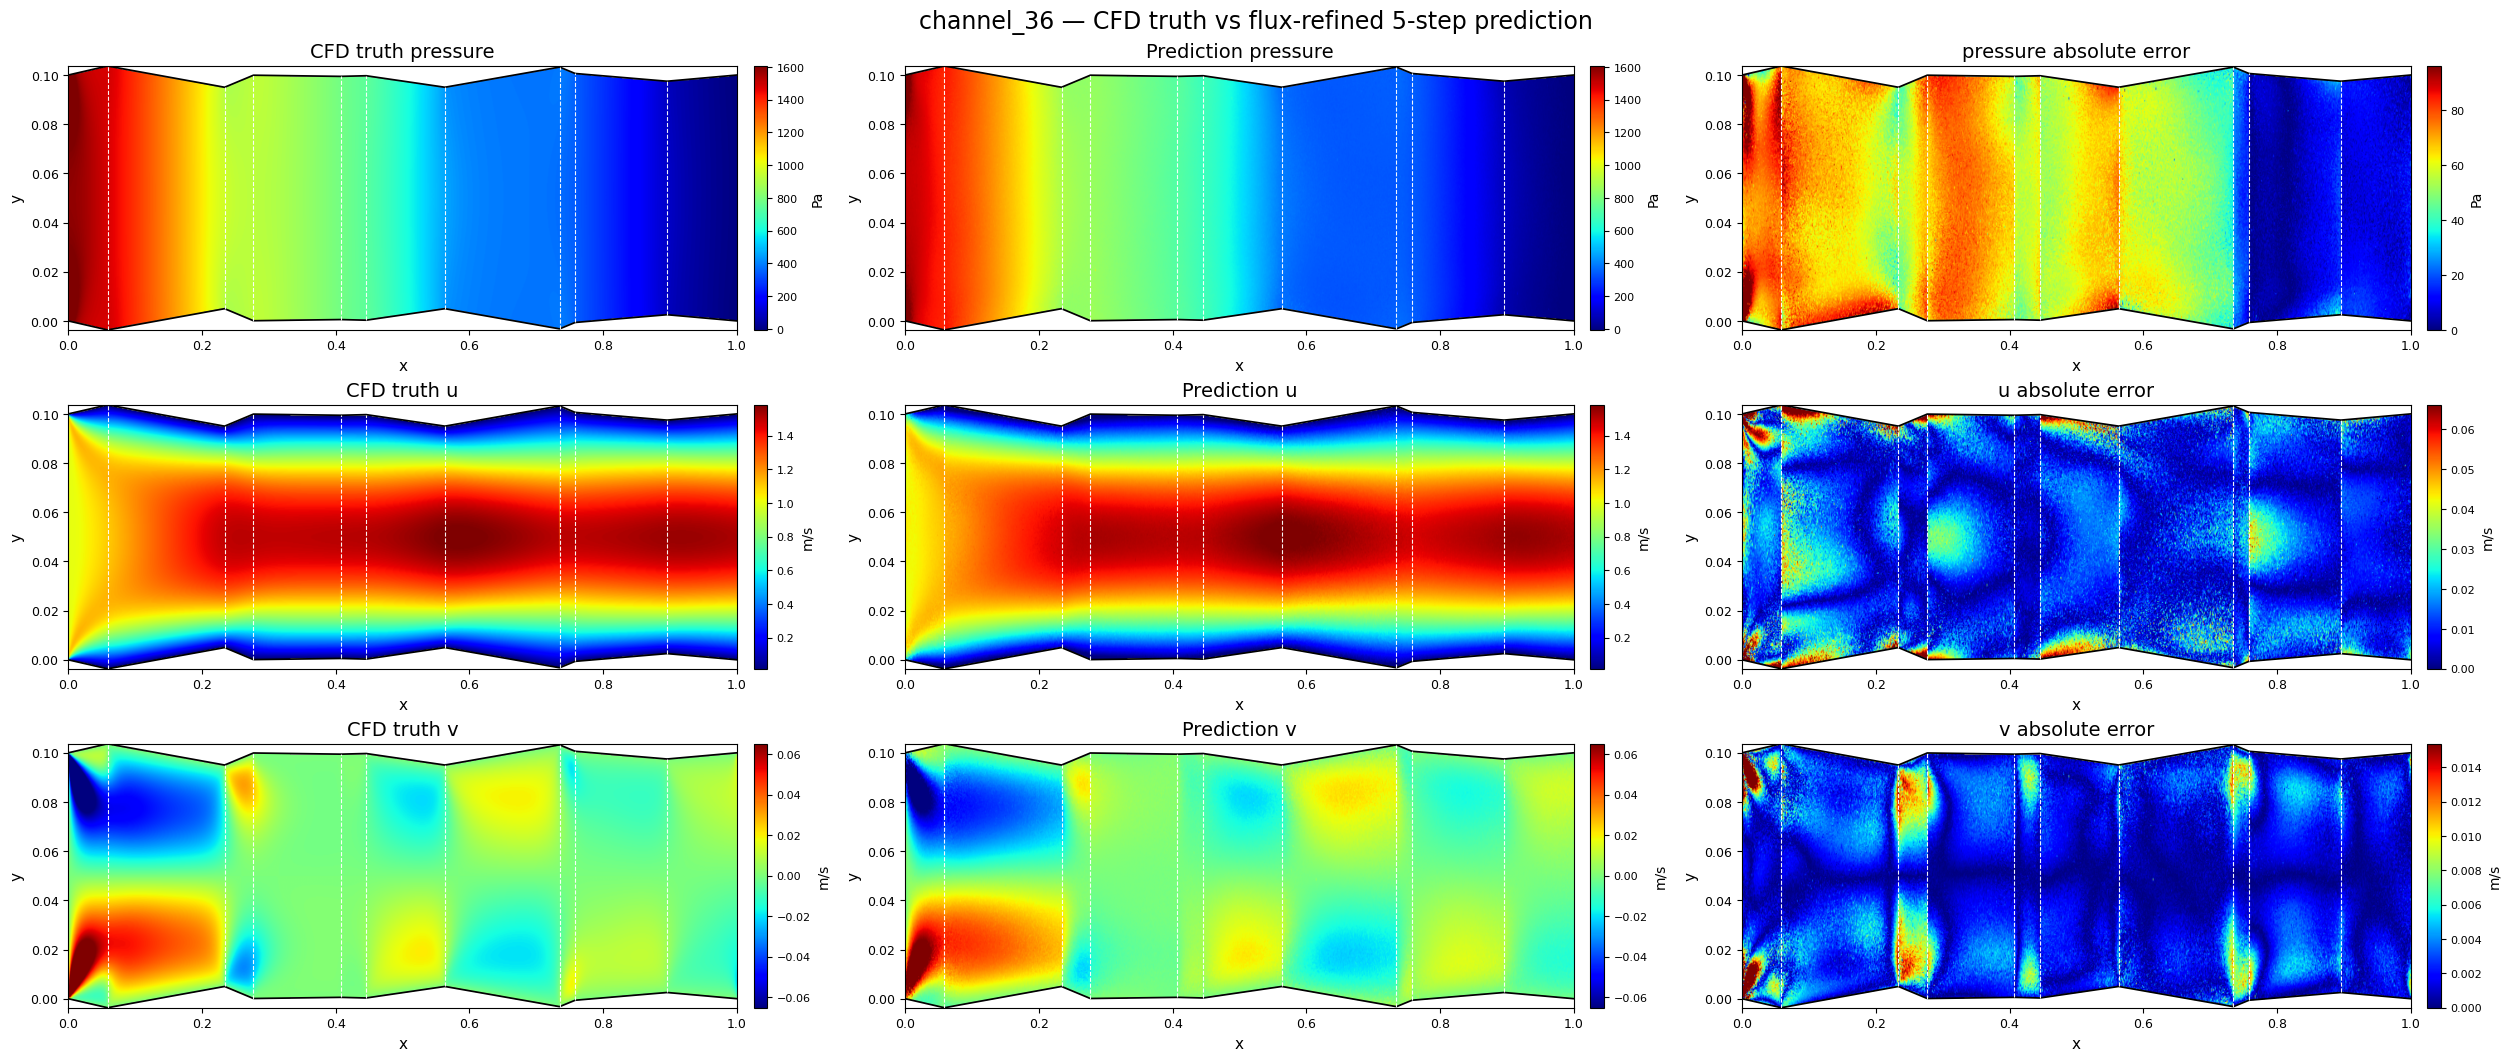

Target dataset path          : samples/<sample_index>/target
Truth array shape            : (227504, 3)
Prediction array shape       : (227504, 3)
Mapped points inside geometry: 100.000000%
Plot arrangement             : 3 rows × 3 columns
Colormap                     : jet

Pointwise evaluation metrics
  pressure   | RMSE=57.62019748 Pa | MAE=49.40812302 Pa | R²=0.983697 | corr=0.998826
  u          | RMSE=0.01896962 m/s | MAE=0.01346862 m/s | R²=0.998088 | corr=0.999090
  v          | RMSE=0.00504824 m/s | MAE=0.00259165 m/s | R²=0.934921 | corr=0.967887

Display ranges
  pressure   | truth/pred=-5.89236419 to +1605.63229329 | error=0 to 96.13956789
  u          | truth/pred=+0.01430408 to +1.58231800 | error=0 to 0.06611471
  v          | truth/pred=-0.06512593 to +0.06512593 | error=0 to 0.01537911

[READY] CFD truth, prediction, and absolute-error fields were plotted in a 3 × 3 layout.
[READY] CFD truth was used only for post-inference evaluation.


In [35]:
# ============================================================
# Cell 15 — CFD truth / oracle-post-hoc prediction / absolute error
#
# Layout:
#   Row 1: pressure truth | pressure prediction | pressure error
#   Row 2: u truth        | u prediction        | u error
#   Row 3: v truth        | v prediction        | v error
#
# Plot style:
#   - jet colormap
#   - 3 rows × 3 columns
#   - truth and prediction share the same color range
#   - absolute error uses its own range starting from zero
#   - black channel walls
#   - white dashed internal interfaces
#
# Important:
#   CFD truth is loaded here only for post-inference evaluation.
#   It was not used in initialization or optimization.
# ============================================================

from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


print("=" * 152)
print("Cell 15 — CFD truth, prediction, and absolute-error fields")
print("=" * 152)


# ============================================================
# 1. Dataset path
# ============================================================

H5_PATH = Path(
    "/home/nuoxu9/PIDIF/"
    "channel_diffusion_dataset/"
    "deeponet_style_dataset/"
    "channel_deeponet_style_pressure_u_v_controlpoints.h5"
)

if not H5_PATH.exists():
    raise FileNotFoundError(
        f"H5 dataset does not exist:\n{H5_PATH}"
    )


# ============================================================
# 2–3. Load per-sample CFD target and coordinate metadata
#
# H5 structure:
#     samples/<sample_index>/target
#
# CFD truth is loaded here only for post-inference evaluation.
# ============================================================

coordinate_metadata_names = [
    "x_left_mm",
    "x_right_mm",
    "y_local_origin_mm",
    "y_local_scale_mm",
]

coordinate_metadata = {
    name: []
    for name in coordinate_metadata_names
}

cfd_truth_physical_list = []

target_dataset_paths = []


with h5py.File(
    H5_PATH,
    "r",
) as h5_file:

    for sample_index in channel_sample_indices:

        # ----------------------------------------------------
        # A. Geometry metadata
        #
        # Prefer global metadata/<name>[sample_index].
        # Fall back to samples/<index>/metadata/<name>.
        # ----------------------------------------------------

        for metadata_name in coordinate_metadata_names:

            global_metadata_path = (
                f"metadata/{metadata_name}"
            )

            grouped_metadata_path = (
                f"samples/{sample_index}/metadata/{metadata_name}"
            )

            direct_grouped_metadata_path = (
                f"samples/{sample_index}/{metadata_name}"
            )

            if global_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        global_metadata_path
                    ][
                        sample_index
                    ]
                ).reshape(-1)

            elif grouped_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        grouped_metadata_path
                    ][()]
                ).reshape(-1)

            elif direct_grouped_metadata_path in h5_file:

                metadata_value = np.asarray(
                    h5_file[
                        direct_grouped_metadata_path
                    ][()]
                ).reshape(-1)

            else:

                raise KeyError(
                    "Could not locate coordinate metadata:\n"
                    f"sample index   : {sample_index}\n"
                    f"metadata name  : {metadata_name}\n"
                    f"checked paths  :\n"
                    f"  {global_metadata_path}\n"
                    f"  {grouped_metadata_path}\n"
                    f"  {direct_grouped_metadata_path}"
                )

            coordinate_metadata[
                metadata_name
            ].append(
                float(
                    metadata_value[0]
                )
            )


        # ----------------------------------------------------
        # B. Per-sample CFD target
        # ----------------------------------------------------

        target_path_candidates = [
            f"samples/{sample_index}/target",
            f"samples/{sample_index}/targets",
            f"samples/{sample_index}/field",
            f"samples/{sample_index}/fields",
        ]

        target_dataset_path = None

        for candidate_path in target_path_candidates:

            if (
                candidate_path in h5_file
                and isinstance(
                    h5_file[
                        candidate_path
                    ],
                    h5py.Dataset,
                )
            ):

                target_dataset_path = candidate_path
                break


        if target_dataset_path is None:

            sample_group_path = (
                f"samples/{sample_index}"
            )

            if sample_group_path not in h5_file:

                raise KeyError(
                    f"Missing H5 sample group: "
                    f"{sample_group_path}"
                )

            available_items = list(
                h5_file[
                    sample_group_path
                ].keys()
            )

            raise KeyError(
                "Could not locate target for sample:\n"
                f"sample index    : {sample_index}\n"
                f"sample group    : {sample_group_path}\n"
                f"available items : {available_items}"
            )


        target_dataset_paths.append(
            target_dataset_path
        )


        target_array = np.asarray(
            h5_file[
                target_dataset_path
            ][()],
            dtype=np.float32,
        )


        # ----------------------------------------------------
        # C. Normalize target shape to (N_points, 3)
        # ----------------------------------------------------

        target_array = np.squeeze(
            target_array
        )


        if target_array.ndim == 1:

            if target_array.size % 3 != 0:

                raise RuntimeError(
                    f"Target sample {sample_index} has shape "
                    f"{target_array.shape} and cannot be "
                    "reshaped to (-1, 3)."
                )

            target_array = target_array.reshape(
                -1,
                3,
            )


        elif target_array.ndim == 2:

            if target_array.shape[1] == 3:

                pass

            elif target_array.shape[0] == 3:

                target_array = (
                    target_array.T
                )

            else:

                raise RuntimeError(
                    f"Unexpected 2D target shape for sample "
                    f"{sample_index}: {target_array.shape}"
                )


        else:

            if target_array.shape[-1] == 3:

                target_array = (
                    target_array.reshape(
                        -1,
                        3,
                    )
                )

            elif target_array.shape[0] == 3:

                target_array = (
                    np.moveaxis(
                        target_array,
                        0,
                        -1,
                    )
                    .reshape(
                        -1,
                        3,
                    )
                )

            else:

                raise RuntimeError(
                    f"Unexpected target shape for sample "
                    f"{sample_index}: {target_array.shape}"
                )


        cfd_truth_physical_list.append(
            target_array.astype(
                np.float32,
                copy=False,
            )
        )


for metadata_name in coordinate_metadata:

    coordinate_metadata[
        metadata_name
    ] = np.asarray(
        coordinate_metadata[
            metadata_name
        ],
        dtype=np.float64,
    )


# Keep a printable target description for the diagnostics
# section at the end of Cell 15.
target_dataset_path = (
    "samples/<sample_index>/target"
)


print(
    "Loaded target paths:"
)

for path in target_dataset_paths:

    print(
        " ",
        path,
    )

print(
    "\nLoaded target shapes:"
)

for subdomain_id, target_array in enumerate(
    cfd_truth_physical_list
):

    print(
        f"  subdomain {subdomain_id:02d}: "
        f"{target_array.shape}"
    )

# ============================================================
# Cell 15 patch — Recover query lengths from channel_query_list
# ============================================================

query_lengths = np.asarray(
    [
        int(
            np.asarray(
                channel_query_list[
                    subdomain_id
                ]
            ).shape[0]
        )
        for subdomain_id in range(
            NUM_SUBDOMAINS
        )
    ],
    dtype=np.int64,
)


query_offsets = np.concatenate(
    [
        np.asarray(
            [0],
            dtype=np.int64,
        ),
        np.cumsum(
            query_lengths,
            dtype=np.int64,
        ),
    ]
)


if int(
    query_lengths.sum()
) != int(
    oracle_posthoc_prediction_physical_np.shape[0]
):

    raise RuntimeError(
        "Recovered query lengths do not match the final "
        "prediction length:\n"
        f"sum(query_lengths) = {query_lengths.sum()}\n"
        f"prediction points  = "
        f"{oracle_posthoc_prediction_physical_np.shape[0]}"
    )


print(
    "Recovered query lengths:",
    query_lengths.tolist(),
)

print(
    "Recovered query offsets:",
    query_offsets.tolist(),
)

print(
    "Total query points:",
    int(
        query_lengths.sum()
    ),
)

# ============================================================
# 4. Validate target lengths
# ============================================================

for subdomain_id in range(
    NUM_SUBDOMAINS
):

    expected_count = int(
        query_lengths[
            subdomain_id
        ]
    )

    actual_count = int(
        cfd_truth_physical_list[
            subdomain_id
        ].shape[0]
    )

    if actual_count != expected_count:
        raise RuntimeError(
            f"Subdomain {subdomain_id}: target/query count "
            f"mismatch: target={actual_count}, "
            f"query={expected_count}"
        )


cfd_truth_physical_np = np.concatenate(
    cfd_truth_physical_list,
    axis=0,
)


if cfd_truth_physical_np.shape != (
    oracle_posthoc_prediction_physical_np.shape
):
    raise RuntimeError(
        "Truth/prediction shape mismatch:\n"
        f"truth      = {cfd_truth_physical_np.shape}\n"
        f"prediction = {oracle_posthoc_prediction_physical_np.shape}"
    )


# ============================================================
# 5. Convert local query coordinates to global coordinates
# ============================================================

global_query_list_mm = []
global_query_subdomain_id_list = []


for subdomain_id in range(
    NUM_SUBDOMAINS
):

    local_query = np.asarray(
        channel_query_list[
            subdomain_id
        ],
        dtype=np.float64,
    )

    x_left_local = coordinate_metadata[
        "x_left_mm"
    ][
        subdomain_id
    ]

    x_right_local = coordinate_metadata[
        "x_right_mm"
    ][
        subdomain_id
    ]

    y_origin_local = coordinate_metadata[
        "y_local_origin_mm"
    ][
        subdomain_id
    ]

    y_scale_local = coordinate_metadata[
        "y_local_scale_mm"
    ][
        subdomain_id
    ]

    x_global_mm = (
        x_left_local
        + local_query[:, 0]
        * (
            x_right_local
            - x_left_local
        )
    )

    y_global_mm = (
        y_origin_local
        + local_query[:, 1]
        * y_scale_local
    )

    global_coordinates = np.column_stack(
        [
            x_global_mm,
            y_global_mm,
        ]
    )

    global_query_list_mm.append(
        global_coordinates
    )

    global_query_subdomain_id_list.append(
        np.full(
            global_coordinates.shape[0],
            subdomain_id,
            dtype=np.int64,
        )
    )


global_query_mm = np.concatenate(
    global_query_list_mm,
    axis=0,
)

global_query_subdomain_id = np.concatenate(
    global_query_subdomain_id_list,
    axis=0,
)


# ============================================================
# 6. Determine valid query points inside channel geometry
# ============================================================

bottom_at_query_mm = np.interp(
    global_query_mm[:, 0],
    x_points_mm,
    bottom_y_mm,
)

top_at_query_mm = np.interp(
    global_query_mm[:, 0],
    x_points_mm,
    top_y_mm,
)


GEOMETRY_TOLERANCE_MM = 2.0e-5

inside_geometry_mask = (
    (
        global_query_mm[:, 1]
        >= bottom_at_query_mm
        - GEOMETRY_TOLERANCE_MM
    )
    & (
        global_query_mm[:, 1]
        <= top_at_query_mm
        + GEOMETRY_TOLERANCE_MM
    )
)


inside_fraction = float(
    inside_geometry_mask.mean()
)


# ============================================================
# 7. Regular plotting grid
# ============================================================

N_X_PLOT = 1200
N_Y_PLOT = 300


x_plot_mm = np.linspace(
    float(x_points_mm.min()),
    float(x_points_mm.max()),
    N_X_PLOT,
)

y_plot_mm = np.linspace(
    float(bottom_y_mm.min()),
    float(top_y_mm.max()),
    N_Y_PLOT,
)


X_PLOT_MM, Y_PLOT_MM = np.meshgrid(
    x_plot_mm,
    y_plot_mm,
)


bottom_plot_mm = np.interp(
    x_plot_mm,
    x_points_mm,
    bottom_y_mm,
)

top_plot_mm = np.interp(
    x_plot_mm,
    x_points_mm,
    top_y_mm,
)


channel_plot_mask = (
    (
        Y_PLOT_MM
        >= bottom_plot_mm[None, :]
    )
    & (
        Y_PLOT_MM
        <= top_plot_mm[None, :]
    )
)


# ============================================================
# 8. Interpolate one complete field onto plotting grid
#
# Interpolation is performed subdomain-by-subdomain to avoid
# connecting non-neighboring points across decomposition blocks.
# ============================================================

def interpolate_complete_field_to_grid(
    field_list,
):

    output_grids = [
        np.full(
            X_PLOT_MM.shape,
            np.nan,
            dtype=np.float64,
        )
        for _ in range(3)
    ]

    for subdomain_id in range(
        NUM_SUBDOMAINS
    ):

        query_coordinates = (
            global_query_list_mm[
                subdomain_id
            ]
        )

        field_values = np.asarray(
            field_list[
                subdomain_id
            ],
            dtype=np.float64,
        )

        x_left_local = float(
            coordinate_metadata[
                "x_left_mm"
            ][
                subdomain_id
            ]
        )

        x_right_local = float(
            coordinate_metadata[
                "x_right_mm"
            ][
                subdomain_id
            ]
        )

        grid_column_indices = np.where(
            (
                x_plot_mm
                >= x_left_local
            )
            & (
                x_plot_mm
                <= x_right_local
            )
        )[0]

        if grid_column_indices.size == 0:
            continue

        X_SUBGRID = X_PLOT_MM[
            :,
            grid_column_indices,
        ]

        Y_SUBGRID = Y_PLOT_MM[
            :,
            grid_column_indices,
        ]

        for field_index in range(3):

            interpolated_subgrid = griddata(
                points=query_coordinates,
                values=field_values[
                    :,
                    field_index,
                ],
                xi=(
                    X_SUBGRID,
                    Y_SUBGRID,
                ),
                method="linear",
            )

            missing_mask = ~np.isfinite(
                interpolated_subgrid
            )

            if missing_mask.any():

                nearest_subgrid = griddata(
                    points=query_coordinates,
                    values=field_values[
                        :,
                        field_index,
                    ],
                    xi=(
                        X_SUBGRID,
                        Y_SUBGRID,
                    ),
                    method="nearest",
                )

                interpolated_subgrid[
                    missing_mask
                ] = nearest_subgrid[
                    missing_mask
                ]

            output_grids[
                field_index
            ][
                :,
                grid_column_indices,
            ] = interpolated_subgrid

    for field_index in range(3):

        output_grids[
            field_index
        ][
            ~channel_plot_mask
        ] = np.nan

    return output_grids


# ============================================================
# 9. Prepare prediction lists as NumPy arrays
# ============================================================

oracle_posthoc_prediction_physical_list_np = [
    tensor.detach()
    .cpu()
    .numpy()
    .astype(
        np.float32,
        copy=False,
    )
    for tensor in oracle_posthoc_prediction_physical_list
]


# ============================================================
# 10. Interpolate truth and prediction
# ============================================================

truth_grids = interpolate_complete_field_to_grid(
    cfd_truth_physical_list
)

oracle_posthoc_prediction_grids = interpolate_complete_field_to_grid(
    oracle_posthoc_prediction_physical_list_np
)


oracle_posthoc_absolute_error_grids = [
    np.abs(
        oracle_posthoc_prediction_grids[field_index]
        - truth_grids[field_index]
    )
    for field_index in range(3)
]


# ============================================================
# 11. Plot configuration
# ============================================================

FIELD_NAMES = [
    "pressure",
    "u",
    "v",
]

FIELD_UNITS = [
    "Pa",
    "m/s",
    "m/s",
]


DISPLAY_LOW_PERCENTILE = 0.5
DISPLAY_HIGH_PERCENTILE = 99.5
ERROR_HIGH_PERCENTILE = 99.5


plot_extent = [
    float(x_plot_mm.min()),
    float(x_plot_mm.max()),
    float(y_plot_mm.min()),
    float(y_plot_mm.max()),
]


# ============================================================
# 12. Shared color limits for truth and prediction
# ============================================================

oracle_posthoc_truth_prediction_ranges = []
oracle_posthoc_absolute_error_ranges = []


for field_index in range(3):

    truth_values = truth_grids[
        field_index
    ][
        np.isfinite(
            truth_grids[
                field_index
            ]
        )
    ]

    prediction_values = oracle_posthoc_prediction_grids[
        field_index
    ][
        np.isfinite(
            oracle_posthoc_prediction_grids[
                field_index
            ]
        )
    ]

    combined_values = np.concatenate(
        [
            truth_values,
            prediction_values,
        ]
    )

    shared_vmin = float(
        np.percentile(
            combined_values,
            DISPLAY_LOW_PERCENTILE,
        )
    )

    shared_vmax = float(
        np.percentile(
            combined_values,
            DISPLAY_HIGH_PERCENTILE,
        )
    )

    # Keep v truth and prediction centered around zero.
    if field_index == 2:

        symmetric_limit = max(
            abs(shared_vmin),
            abs(shared_vmax),
        )

        shared_vmin = -symmetric_limit
        shared_vmax = symmetric_limit

    oracle_posthoc_truth_prediction_ranges.append(
        (
            shared_vmin,
            shared_vmax,
        )
    )

    error_values = oracle_posthoc_absolute_error_grids[
        field_index
    ][
        np.isfinite(
            oracle_posthoc_absolute_error_grids[
                field_index
            ]
        )
    ]

    error_vmax = float(
        np.percentile(
            error_values,
            ERROR_HIGH_PERCENTILE,
        )
    )

    oracle_posthoc_absolute_error_ranges.append(
        (
            0.0,
            error_vmax,
        )
    )


# ============================================================
# 13. Helper for channel outlines and interfaces
# ============================================================

def add_channel_geometry(
    axis,
):

    axis.plot(
        x_points_mm,
        bottom_y_mm,
        color="black",
        linewidth=1.25,
        zorder=5,
    )

    axis.plot(
        x_points_mm,
        top_y_mm,
        color="black",
        linewidth=1.25,
        zorder=5,
    )

    for interface_x_mm in x_points_mm[
        1:-1
    ]:

        interface_bottom_mm = float(
            np.interp(
                interface_x_mm,
                x_points_mm,
                bottom_y_mm,
            )
        )

        interface_top_mm = float(
            np.interp(
                interface_x_mm,
                x_points_mm,
                top_y_mm,
            )
        )

        axis.plot(
            [
                interface_x_mm,
                interface_x_mm,
            ],
            [
                interface_bottom_mm,
                interface_top_mm,
            ],
            color="white",
            linestyle="--",
            linewidth=0.8,
            alpha=0.95,
            zorder=6,
        )

    axis.set_xlim(
        float(x_points_mm.min()),
        float(x_points_mm.max()),
    )

    axis.set_ylim(
        float(bottom_y_mm.min()),
        float(top_y_mm.max()),
    )

    axis.set_xlabel(
        "x",
        fontsize=11,
    )

    axis.set_ylabel(
        "y",
        fontsize=11,
    )

    axis.tick_params(
        labelsize=9
    )


# ============================================================
# 14. Plot 3 rows × 3 columns
# ============================================================

figure, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(
        25,
        10.5,
    ),
    constrained_layout=True,
)


for field_index in range(3):

    field_name = FIELD_NAMES[
        field_index
    ]

    field_unit = FIELD_UNITS[
        field_index
    ]

    shared_vmin, shared_vmax = (
        oracle_posthoc_truth_prediction_ranges[
            field_index
        ]
    )

    error_vmin, error_vmax = (
        oracle_posthoc_absolute_error_ranges[
            field_index
        ]
    )

    # --------------------------------------------------------
    # Column 1: CFD truth
    # --------------------------------------------------------

    truth_image = axes[
        field_index,
        0,
    ].imshow(
        np.ma.masked_invalid(
            truth_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )

    axes[
        field_index,
        0,
    ].set_title(
        f"CFD truth {field_name}",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            0,
        ]
    )

    truth_colorbar = figure.colorbar(
        truth_image,
        ax=axes[
            field_index,
            0,
        ],
        pad=0.01,
        fraction=0.035,
    )

    truth_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    truth_colorbar.ax.tick_params(
        labelsize=8
    )

    # --------------------------------------------------------
    # Column 2: prediction
    # --------------------------------------------------------

    prediction_image = axes[
        field_index,
        1,
    ].imshow(
        np.ma.masked_invalid(
            oracle_posthoc_prediction_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )

    axes[
        field_index,
        1,
    ].set_title(
        f"Prediction {field_name}",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            1,
        ]
    )

    prediction_colorbar = figure.colorbar(
        prediction_image,
        ax=axes[
            field_index,
            1,
        ],
        pad=0.01,
        fraction=0.035,
    )

    prediction_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    prediction_colorbar.ax.tick_params(
        labelsize=8
    )

    # --------------------------------------------------------
    # Column 3: absolute error
    # --------------------------------------------------------

    error_image = axes[
        field_index,
        2,
    ].imshow(
        np.ma.masked_invalid(
            oracle_posthoc_absolute_error_grids[
                field_index
            ]
        ),
        extent=plot_extent,
        origin="lower",
        cmap="jet",
        aspect="auto",
        interpolation="bilinear",
        vmin=error_vmin,
        vmax=error_vmax,
    )

    axes[
        field_index,
        2,
    ].set_title(
        f"{field_name} absolute error",
        fontsize=14,
    )

    add_channel_geometry(
        axes[
            field_index,
            2,
        ]
    )

    error_colorbar = figure.colorbar(
        error_image,
        ax=axes[
            field_index,
            2,
        ],
        pad=0.01,
        fraction=0.035,
    )

    error_colorbar.set_label(
        field_unit,
        fontsize=10,
    )

    error_colorbar.ax.tick_params(
        labelsize=8
    )


figure.suptitle(
    f"{CASE_NAME} — CFD truth vs "
    f"{ORACLE_SELECTED_INTERFACE_STATE_NAME} "
    "5-step oracle/post-hoc selected prediction",
    fontsize=17,
)


plt.show()


# ============================================================
# 15. Pointwise metrics over valid original query points
# ============================================================

truth_valid = cfd_truth_physical_np[
    inside_geometry_mask
]

prediction_valid = oracle_posthoc_prediction_physical_np[
    inside_geometry_mask
]

pointwise_error = (
    prediction_valid
    - truth_valid
)


oracle_posthoc_evaluation_metrics = {}


for field_index, (
    field_name,
    field_unit,
) in enumerate(
    zip(
        FIELD_NAMES,
        FIELD_UNITS,
    )
):

    truth_field = truth_valid[
        :,
        field_index
    ]

    prediction_field = prediction_valid[
        :,
        field_index
    ]

    error_field = pointwise_error[
        :,
        field_index
    ]

    mse = float(
        np.mean(
            error_field ** 2
        )
    )

    rmse = float(
        np.sqrt(mse)
    )

    mae = float(
        np.mean(
            np.abs(
                error_field
            )
        )
    )

    truth_variance = float(
        np.var(
            truth_field
        )
    )

    r2 = (
        1.0
        - mse / truth_variance
        if truth_variance > 0.0
        else np.nan
    )

    correlation = float(
        np.corrcoef(
            truth_field,
            prediction_field,
        )[0, 1]
    )

    oracle_posthoc_evaluation_metrics[
        field_name
    ] = {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "correlation": correlation,
        "unit": field_unit,
    }


# ============================================================
# 16. Save evaluation and plotting state
# ============================================================

oracle_posthoc_visualization_state = {
    "prediction_protocol": (
        "oracle_posthoc"
    ),

    "prediction_interface_state_name": (
        ORACLE_SELECTED_INTERFACE_STATE_NAME
    ),

    "prediction_selection_used_cfd_truth": (
        True
    ),

    "metrics_used_cfd_truth": (
        True
    ),
    "target_dataset_path": (
        target_dataset_path
    ),

    "global_query_mm": (
        global_query_mm
    ),

    "global_query_list_mm": (
        global_query_list_mm
    ),

    "global_query_subdomain_id": (
        global_query_subdomain_id
    ),

    "inside_geometry_mask": (
        inside_geometry_mask
    ),

    "truth_physical_np": (
        cfd_truth_physical_np
    ),

    "prediction_physical_np": (
        oracle_posthoc_prediction_physical_np
    ),

    "truth_grids": (
        truth_grids
    ),

    "oracle_posthoc_prediction_grids": (
        oracle_posthoc_prediction_grids
    ),

    "oracle_posthoc_absolute_error_grids": (
        oracle_posthoc_absolute_error_grids
    ),

    "oracle_posthoc_truth_prediction_ranges": (
        oracle_posthoc_truth_prediction_ranges
    ),

    "oracle_posthoc_absolute_error_ranges": (
        oracle_posthoc_absolute_error_ranges
    ),

    "oracle_posthoc_evaluation_metrics": (
        oracle_posthoc_evaluation_metrics
    ),
}


# ============================================================
# 17. Diagnostics
# ============================================================

print(
    "Target dataset path          :",
    target_dataset_path,
)

print(
    "Truth array shape            :",
    cfd_truth_physical_np.shape,
)

print(
    "Oracle/post-hoc prediction array shape:",
    oracle_posthoc_prediction_physical_np.shape,
)

print(
    "Mapped points inside geometry:",
    f"{inside_fraction * 100.0:.6f}%",
)

print(
    "Plot arrangement             :",
    "3 rows × 3 columns",
)

print(
    "Colormap                     :",
    "jet",
)


print("\nOracle/post-hoc pointwise evaluation metrics")

for field_name in FIELD_NAMES:

    metrics = oracle_posthoc_evaluation_metrics[
        field_name
    ]

    print(
        f"  {field_name:<10} | "
        f"RMSE={metrics['rmse']:.8f} {metrics['unit']} | "
        f"MAE={metrics['mae']:.8f} {metrics['unit']} | "
        f"R²={metrics['r2']:.6f} | "
        f"corr={metrics['correlation']:.6f}"
    )


print("\nDisplay ranges")

for field_index, field_name in enumerate(
    FIELD_NAMES
):

    shared_vmin, shared_vmax = (
        oracle_posthoc_truth_prediction_ranges[
            field_index
        ]
    )

    _, error_vmax = (
        oracle_posthoc_absolute_error_ranges[
            field_index
        ]
    )

    print(
        f"  {field_name:<10} | "
        f"truth/pred={shared_vmin:+.8f} to "
        f"{shared_vmax:+.8f} | "
        f"error=0 to {error_vmax:.8f}"
    )


print("\n" + "=" * 152)

print(
    "[READY] CFD truth, prediction, and absolute-error fields "
    "were plotted in a 3 × 3 layout."
)

print(
    "[READY] CFD truth was used for oracle/post-hoc "
    "evaluation and selection."
)

print("=" * 152)